# About Jupyter Notebook
For some of you, this might be your first time using a Jupyter notebook. Here are a few tips to get you started!

A Jupyter notebook is a file with the .ipynb extension, just like this one. It's made up of *cells*, which can be:
- Code cells - where you write your code
- Markdown cells - where you write formatted text (like this section!)

Code cell are labeled with `[ ]` on the left. When a cell is running, the label changes to `[*]`. The number inside the brackets shows the order in which cells have been executed by the *kernel*.

So, what is the kernel? The kernel is the computational 'engine' that runs the code. This notebook is connected to a Python kernel.

### Useful Keyboard Shortcuts
Jupyter notebooks offer helpful keyboard shortcuts that may save your time. First, make sure you are in *command mode* (not editing a cell). Press <kbd>Esc</kbd> or click outside the cell to exit *edit mode*.

Here are some handy shortcuts:
- Insert a new cell above or below → press <kbd>A</kbd> or <kbd>B</kbd>
- Delete a cell → press <kbd>D</kbd> twice (Note: Deleted cells cannot be recovered!)
- Restart the kernel and run all cells → press <kbd>0</kbd> twice (this is a zero!)
- Run the selected cell → press <kbd>Ctrl</kbd> + <kbd>Enter</kbd>
- Run the selected cell and move to the next cell → press <kbd>Shift</kbd> + <kbd>Enter</kbd>

Please check out the toolbar and menu bar at the top of the notebook for more options.

# Awkward Arrays
This lab uses a library called **Awkward Array**. Like Numpy, Awkward Arrays can have multiple dimensions. However, unlike Numpy, Awkward arrays support dimensions with *varying lengths*, making them ideal for handling irregular or nested data in particle physics experiments.
### Structured Data in Awkward Arrays
This lab uses structured data, where each element is a *record* with named fields (similar to a dictionary). For example:
```
array1 = ak.Array([{
    'a': [1, 2, 3],
    'b': 4,
    'c': [5, 6]
}])
```
This array `array1` contains *one* record with three fields: `'a'`, `'b'`, and `'c'`. You can access the list of fields with `array1.fields`.
### Concatenating Awkward Arrays
To combine two Awkward arrays with matching structure, use `ak.concatenate()`. An example:
```
array2 = ak.Array([{
    'a': [7, 8],
    'b': 9,
    'c': [10, 11, 12]
}])

ak.concatenate([array1, array2])
```
This results in a single Awkward Array with *two* records:
```
[
    {'a': [1, 2, 3], 'b': 4, 'c': [5, 6]},
    {'a': [7, 8],    'b': 9, 'c': [10, 11, 12]}
]
```
For more information about Awkward Arrays: https://awkward-array.org/doc/main/

# The Experiment
This experiment uses custom modules in the *backend* folder, which have been specifically developed for this third-year lab. This notebook works with **pre-processed data** derived from the **13 TeV 2025 ATLAS Open Data**.

Please run the cell below to install the required packages. You will need to do this **each time you start the server**.

In [4]:
!pip install atlasopenmagic
!pip install pyarrow==20.0.0
 
from atlasopenmagic import install_from_environment
install_from_environment(environment_file="../backend/environment.yml")

'pip' is not recognized as an internal or external command,
operable program or batch file.


'pip' is not recognized as an internal or external command,
operable program or batch file.


Installing packages: ['aiohttp>=3.9.5', 'atlasopenmagic>=1.2.0', 'awkward>=2.8.5', 'awkward-pandas>=2023.8.0', 'fsspec>=2025.7.0', 'hist>=2.8.0', 'ipykernel>=6.29.5', 'jupyter>=1.0.0', 'lmfit>=1.3.2', 'matplotlib>=3.9.1', 'metakernel>=0.30.2', 'notebook>=7', 'numpy>=1.26.4', 'pandas>=2.2.2', 'papermill>=2.6.0', 'pip>=24.2', 'scikit-learn>=1.5.1', 'uproot>=5.3.10', 'uproot3>=3.14.4', 'fsspec-xrootd>=0.5.1', 'jupyterlab_latex>=3.1.0', 'vector>=1.4.1']
Installation complete. You may need to restart your Python environment for changes to take effect.


The above cell is likely to take about 30 seconds to run.  Wait until the [*] to the left of the above cell becomes a number, indicating that it has finished running.  Then, run the cell below to import the required modules and functions for the experiment. Repeat this step **every time you restart the kernel**.

In [5]:
import os
import re
import awkward as ak
import copy
import time
import datetime
from zoneinfo import ZoneInfo
import uproot
import glob
import numpy as np
import vector
import hist
from hist import Hist
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator # for minor ticks
import pyarrow.parquet as pq
import sys
import pandas as pd
sys.path.append('../')
from backend import get_valid_variables, validate_read_variables
from backend import plot_stacked_hist, plot_histograms, histogram_2d, plot_errorbars
from backend import get_histogram, analysis_parquet, VALID_STR_CODE, produced_event_count
from tqdm.notebook import tqdm

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 1083.87datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


## Accessing Data Samples
Data samples stored in the folder *backend/parquet* can be accessed using a *string code*. The available string codes are listed below:  
#### Available Final-State Collections (Real Data)
* `'2to4lep'` - Events with two to four leptons, each with at least 7 GeV of transverse momentum $p_T$
* `'GamGam'` - Events with at least two photons, each with at least 25 GeV of $p_T$

#### Available Monte Carlo Simulation Datasets include
* `'Zee'` - Simulated $Z \rightarrow e^+e^-$ events
* `'Zmumu'` - Simulated $Z \rightarrow \mu^+\mu^-$ events
* `'Ztautau'` - Simulated $Z \rightarrow \tau^+\tau^-$ events
* `'ttbar'` - Simulated $t\overline{t}$ events
* `'Hyy'` - Simulated $H \rightarrow \gamma \gamma$ events

You can use the function `VALID_STR_CODE` to view all available string codes.

In [6]:
VALID_STR_CODE

['2to4lep',
 'Zee',
 'Zmumu',
 'Ztautau',
 'VBF_Zee',
 'VBF_Zmumu',
 'VBF_Ztautau',
 'Zee_BFil',
 'Zee_CFilBVeto',
 'Zee_CVetoBVeto',
 'Zmumu_BFil',
 'Zmumu_CFilBVeto',
 'Zmumu_CVetoBVeto',
 'Wenu',
 'Wmunu',
 'Wtaunu',
 'VBF_Wenu',
 'VBF_Wmunu',
 'VBF_Wtaunu',
 'ttbar',
 'VV4l',
 'm10_40_Zee',
 'm10_40_Zmumu',
 'ggH_H4l',
 'VBF_H4l',
 'WpH_H4l',
 'WmH_H4l',
 'ZH_H4l',
 'ggZH_H4l',
 'ttH_H4l',
 'GamGam',
 'ggF_Hyy',
 'VBF_Hyy',
 'WpH_Hyy',
 'WmH_Hyy',
 'ZH_Hyy',
 'ggZH_Hyy',
 'ttH_Hyy',
 'VBF_Zll',
 'm10_40_Zll',
 'Wlepnu',
 'VBF_Wlepnu',
 'H4l',
 'Hyy']

To combine multiple datasets, combine the string codes using `'+'`. For example, if you would like to combine the $Z \rightarrow \mu^+\mu^-$ and $Z \rightarrow e^+e^-$ datasets, use the string code `'Zee+Zmumu'`.

The sample files in the folder *backend/parquet* contain records, each of which corresponds to an individual LHC *event*. The record for each *event* contains information about the leptons and/or photons found in that event. You can view the available variables using the `get_valid_variables` function that is defined in the folder *backend*. An example is shown in the code cell below.

In [7]:
string_code = '2to4lep'
get_valid_variables(string_code)

Variables validated using ../../parquet/2to4lep\chunk_0.parquet


['lep_n',
 'lep_pt',
 'lep_eta',
 'lep_phi',
 'lep_e',
 'lep_ptvarcone30',
 'lep_topoetcone20',
 'lep_type',
 'lep_charge',
 'lep_isLooseID',
 'lep_isMediumID',
 'lep_isTightID',
 'lep_isLooseIso',
 'lep_isTightIso',
 'trigE',
 'trigM',
 'lep_isTrigMatched',
 'totalWeight']

The function `analysis_parquet` reads datasets specified by the `string_code_list` input and returns a dictionary containing the selected data. By default the selected data is stored in memory for subsequent histogramming/fitting. The parameter `fraction` determines the fraction of each dataset to load; the default value is `1`. For di-lepton analysis, it is recommended to start with `fraction = 0.01` or lower to reduce memory usage.

In [8]:
string_code_list = ['2to4lep', 'Zee'] # List of dataset codes to load
read_variables = ['lep_n', 'lep_pt']
fraction = 0.01 # Fraction of each dataset to load
# Call analysis_parquet to read the datasets and return the data as a dictionary
data = analysis_parquet(read_variables, string_code_list, fraction=fraction)
data

Input string_code_list found. Data samples will be accessed by the string code(s).
Elapsed time = 11.0s


{'2to4lep_0_01': <Array [{lep_n: 2, lep_pt: [...], ...}, ...] type='724561 * {lep_n: int32, ...'>,
 'Zee_0_01': <Array [{lep_n: 2, lep_pt: [...], ...}, ...] type='450511 * {lep_n: int32, ...'>}

As shown in the example above, the `analysis_parquet` function returns a dictionary where:
- **Keys** are constructed by combining each dataset code from `string_code_list` with the `fraction` (e.g. for `2to4lep` and `fraction = 0.01`, the key is `'2to4lep_0_01`)
- **Values** are Awkward Arrays, where each entry corresponds to an event represented as a record (similar to a Python dictionary). The fields in each record correspond to the variables listed in `read_variables`.

For example, the dictionary returned by the `analysis_parquet` may look like this:
```
data = {
    '2to4lep_0_01': Array([
        {'lep_n': 2, 'lep_pt': [106, 47.6]},
        {'lep_n': 2, 'lep_pt': [41.6, 37.3]},
    ]),
    'Zee_0_01': Array([
        ...
    ])
}
```

Let's interpret the first event in the `'2to4lep_0_01'` dataset, which is represented by the first record in the Awkward Array stored under the `'2to4lep_0_01'` key (i.e., `data['2to4lep_0_01']`).
- The number of leptons in this event is 2 (`lep_n : 2`)
- The field `lep_pt` lists their transverse momenta: The first lepton has $p_T = 106$ GeV, and the second lepton has $p_T = 47.6$ GeV.

To extract the $p_T$ of the first lepton from all events in the `'2to4lep_0_01'` dataset, use  
`data['2to4lep_0_01']['lep_pt'][:, 0]`.

In [9]:
data['2to4lep_0_01']['lep_pt'][:, 0] # pT of the first lepton from all events

<Array [39.4, 45.2, 44.3, 59, ..., 10.3, 47.8, 35.4] type='724561 * float32'>

## Event Weights
For a variety of reasons each event in the MC data has an associated *weight*.  

When an event from the ATLAS experiment data is added to one of your histograms then the relevant histogram bin is incremented by 1.0.  However, when using MC events the relevant histogram bin is incremented by an amount `'totalWeight'`.  

You have access to 36 fb$^{-1}$ of real ATLAS data.  However, the MC samples for most of the physical processes have a larger number of events than would be expected in 36 fb$^{-1}$ of data.  The application of a weight (typically less than one) ensures that the total number of events you see in MC histograms is equal to that predicted for the equivalent ATLAS data set.  This calculation involves knowing the predicted cross section, $\sigma$, for each considered physical process and the integrated luminosity, $\int\mathcal{L} dt$.  The *weight* also corrects for discrepancies in experimental efficiencies between the MC simulation and the real ATLAS detector.

You don't need to explicitly include `'totalWeight'` in `read_variables`. If the field is present in the data (i.e. in MC samples), `analysis_parquet` will return it automatically.

Take a look the `EventWeights` module in the backend folder if you're curious how the variable is calculated!

**_Tip_**: Please be careful not to edit any of the code in the backend folder – unless you really know what you are doing you could cause the code to perform in unexpected ways!

## Event Selection

You can also perform event selection by defining a custom *cut function*, which can be passed to `analysis_parquet` via the argument `cut_function`. This function takes the full dataset as input and returns a filtered version according to your selection criteria. In addition, you can compute new variables within the cut function and store them in memory as new fields in the event records. 

The example below selects events with exactly two final-state leptons. It then computes the invariant mass by summing their four-momentum vectors and accessing the `.M` attribute as implemented in the `dilep_cut` function. This function is passed to the `analysis_parquet` via the `cut_function` argument.

In [10]:
#string_code_list = ['2to4lep'] # List of dataset codes to load
string_code_list = ['2to4lep', 'Zmumu', 'm10_40_Zmumu', 'Ztautau', 'ttbar', 'Wmunu'] # List of dataset codes to load

# Variables to read from the dataset
read_variables = ['lep_pt', 'lep_eta', 'lep_phi', 'lep_e', 'lep_type', 'lep_charge', 'lep_n', 'trigM', 'trigE', 'lep_ptvarcone30', 'lep_topoetcone20']
# , 'lep_isLooseID', 'lep_isMediumID', 'lep_isLooseIso', 'lep_isTightIso', 'lep_isTrigMatched']   # other variables that could be read in

# You may also use the pre-defined function `validate_read_variables` to validate your `read_variables`. 
read_variables = validate_read_variables(string_code_list, read_variables)

# Custom selection cut function to filter the data
def pt_cut(data):
    # Cut on lepton number - Only keep events that have two leptons
    data = data[data['lep_n'] == 2] 

    # Cut on lep_type
    # lep_type is 11 for electron, 13 for muon
    data = data[data['lep_type'][:, 0] + data['lep_type'][:, 1] == 26] # Keep events with two muons

    # Cuts on lepton pt
    # Use bitwise operator '&' for AND, '|' for OR. Remember the parentheses!
    data = data[(data['lep_pt'][:, 0] > 10) & (data['lep_pt'][:, 1] > 10)]   # Keep events where both leptons have pt > 10 GeV

    # Require that a single muon trigger fired 
    data = data[(data['trigM'])] 

    # Define four momentum
    four_momentum = vector.zip({
        'pt': data['lep_pt'],
        'eta' : data['lep_eta'],
        'phi' : data['lep_phi'],
        'E' : data['lep_e']
    })
    # Add the 4-momentum of the two leptons in each event and get the 
    # invariant mass using .M
    data['mass'] = (four_momentum[:, 0] + four_momentum[:, 1]).M
    
    # Cut on di-lepton mass
    cut_low = 0
    cut_high = 1000   
    cut_mass = (data['mass']>cut_low) &  (data['mass']<cut_high)
    data = data[cut_mass] # Select events satisfying the condition: cut_low < mass < cut_high (GeV)
 
    return data

fraction = 0.02
pt_data = analysis_parquet(read_variables, string_code_list, fraction=fraction, cut_function=pt_cut)
pt_data

Variables validated using ../../parquet/2to4lep\chunk_0.parquet
Variables validated using ../../parquet/Zmumu\chunk_0.parquet
Variables validated using ../../parquet/m10_40_Zmumu\chunk_0.parquet
Variables validated using ../../parquet/Ztautau\chunk_0.parquet
Variables validated using ../../parquet/ttbar\chunk_0.parquet
Variables validated using ../../parquet/Wmunu\chunk_0.parquet
Input string_code_list found. Data samples will be accessed by the string code(s).
Elapsed time = 9.1s


{'2to4lep_0_02': <Array [{lep_n: 2, lep_pt: [...], ...}, ...] type='573453 * {lep_n: int32, ...'>,
 'Zmumu_0_02': <Array [{lep_n: 2, lep_pt: [...], ...}, ...] type='877353 * {lep_n: int32, ...'>,
 'm10_40_Zmumu_0_02': <Array [{lep_n: 2, lep_pt: [...], ...}, ...] type='27714 * {lep_n: int32, l...'>,
 'Ztautau_0_02': <Array [{lep_n: 2, lep_pt: [...], ...}, ...] type='3176 * {lep_n: int32, le...'>,
 'ttbar_0_02': <Array [{lep_n: 2, lep_pt: [...], ...}, ...] type='8264 * {lep_n: int32, le...'>,
 'Wmunu_0_02': <Array [{lep_n: 2, lep_pt: [...], ...}, ...] type='2183 * {lep_n: int32, le...'>}

In [11]:
#electron
#string_code_list = ['2to4lep'] # List of dataset codes to load
electron_string_code_list = ['2to4lep','Zee','m10_40_Zee','Ztautau','ttbar','Wenu'] # List of dataset codes to load
read_variables = ['lep_pt', 'lep_eta', 'lep_phi', 'lep_e', 'lep_type', 'lep_charge', 'lep_n', 'trigM', 'trigE', 'lep_ptvarcone30', 'lep_topoetcone20']
electron_read_variables = validate_read_variables(electron_string_code_list, read_variables)

Variables validated using ../../parquet/2to4lep\chunk_0.parquet
Variables validated using ../../parquet/Zee\chunk_0.parquet
Variables validated using ../../parquet/m10_40_Zee\chunk_0.parquet
Variables validated using ../../parquet/Ztautau\chunk_0.parquet
Variables validated using ../../parquet/ttbar\chunk_0.parquet
Variables validated using ../../parquet/Wenu\chunk_0.parquet


In [12]:
# muon
def base_mumu(data):
    data = data[data['lep_n'] == 2]
    data = data[data['lep_type'][:,0] + data['lep_type'][:,1] == 26]
    data = data[(data['lep_pt'][:,0] > 10) & (data['lep_pt'][:,1] > 10)]
    data = data[data['trigM']]
    four_momentum = vector.zip({
        'pt':  data['lep_pt'],
        'eta': data['lep_eta'],
        'phi': data['lep_phi'],
        'E':   data['lep_e']
    })
    data['mass'] = (four_momentum[:, 0] + four_momentum[:, 1]).M
    return data
def cut_muOppositeSign(data):
    data = base_mumu(data)
    q0 = data['lep_charge'][:, 0]
    q1 = data['lep_charge'][:, 1]
    return data[(q0 * q1) == -1]

def cut_muSameSign(data):
    data = base_mumu(data)
    q0 = data['lep_charge'][:, 0]
    q1 = data['lep_charge'][:, 1]
    return data[(q0 * q1) == +1]

In [13]:
fraction = 0.02
pt_data_mu_OS = analysis_parquet(read_variables, string_code_list, fraction=fraction, cut_function=cut_muOppositeSign)
pt_data_mu_SS = analysis_parquet(read_variables, string_code_list, fraction=fraction, cut_function=cut_muSameSign)

Input string_code_list found. Data samples will be accessed by the string code(s).
Elapsed time = 7.0s
Input string_code_list found. Data samples will be accessed by the string code(s).
Elapsed time = 6.9s


In [14]:
#electron
def base_ee(data):
    data = data[data['lep_n'] == 2]
    data = data[data['lep_type'][:,0] + data['lep_type'][:,1] == 22]
    data = data[(data['lep_pt'][:,0] > 10) & (data['lep_pt'][:,1] > 10)]
    data = data[data['trigE']]
    four_momentum = vector.zip({
        'pt':  data['lep_pt'],
        'eta': data['lep_eta'],
        'phi': data['lep_phi'],
        'E':   data['lep_e']
    })
    data['mass'] = (four_momentum[:, 0] + four_momentum[:, 1]).M
    return data
def cut_eeOppositeSign(data):
    data = base_ee(data)
    q0 = data['lep_charge'][:, 0]
    q1 = data['lep_charge'][:, 1]
    return data[(q0 * q1) == -1]

def cut_eeSameSign(data):
    data = base_ee(data)
    q0 = data['lep_charge'][:, 0]
    q1 = data['lep_charge'][:, 1]
    return data[(q0 * q1) == +1]

In [15]:
#electron
fraction = 0.02
pt_data_ee_OS = analysis_parquet(electron_read_variables, electron_string_code_list, fraction=fraction, cut_function=cut_eeOppositeSign)
pt_data_ee_SS = analysis_parquet(electron_read_variables, electron_string_code_list, fraction=fraction, cut_function=cut_eeSameSign)

Input string_code_list found. Data samples will be accessed by the string code(s).
Elapsed time = 9.2s
Input string_code_list found. Data samples will be accessed by the string code(s).
Elapsed time = 7.6s


If you only need data for a specific lepton — for example, the $p_T$ of the first lepton — you can include `'lepton_pt[0]'` in `read_variables` instead of `'lepton_pt'`. This saves memory by storing the data as a flat array rather than a nested one. However, do this only if `'lepton_pt'` is not required elsewhere, such as in the cut function.

## Plot Stacked Histogram
The dictionary returned by `analysis_parquet` can be used to plot a stacked histogram by passing it to the `plot_stacked_hist` function.

To use this function correctly, there are a few points to take note of:
- The first argument must be a **dictionary**.
- If a dictionary key includes `'Data'`, its content will be plotted as data points with error bars.
- If a dictionary key includes `'Signal'`, its content will be stacked as histogram bars on top of the background.
- Python strings are case-sensitive, i.e. `'Data'` and `'data'` are treated differently!

An example is shown below, where `'2to4lep_0_01'` is treated as data and `'Zee_0_01'` as the signal.

Elapsed time = 0.6s


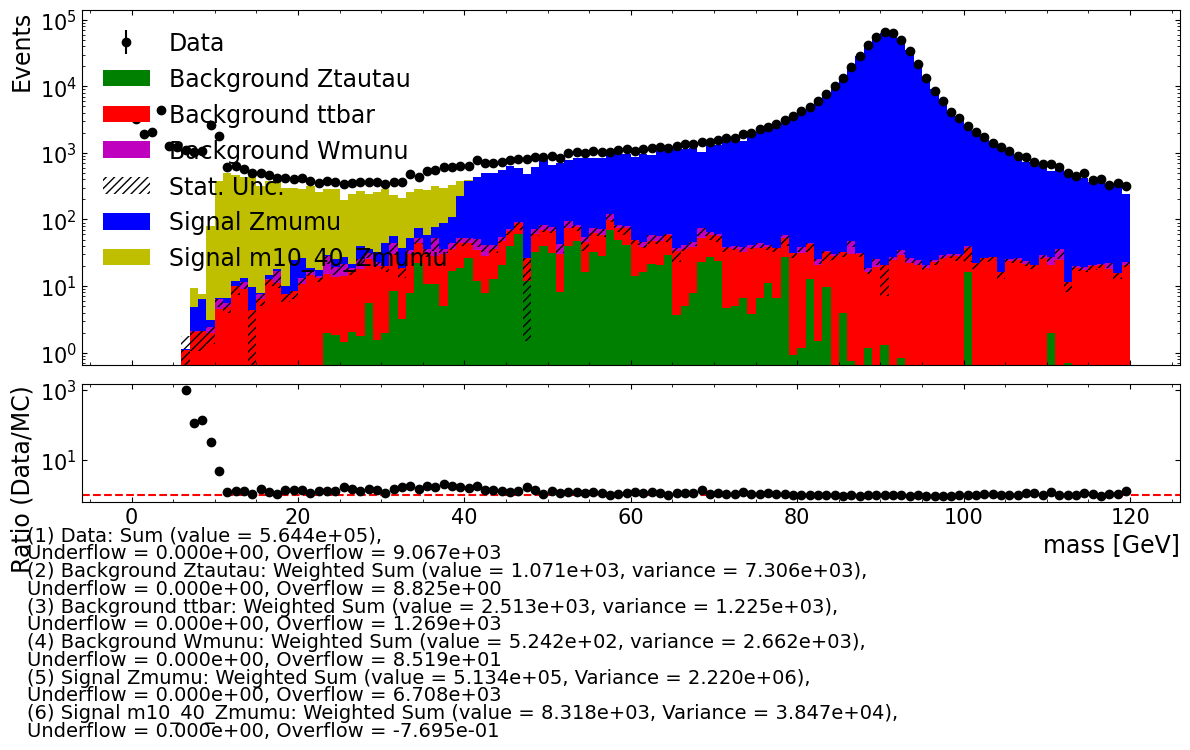

In [16]:
# Define what to plot: '2to4lep_0_01' as data, 'Zee_0_01' as signal
plot_dict = {
    'Data' : pt_data['2to4lep_0_02'],
    'Signal Zmumu' : pt_data['Zmumu_0_02'], 
    'Signal m10_40_Zmumu' : pt_data['m10_40_Zmumu_0_02'], 
    'Background Ztautau': pt_data['Ztautau_0_02'],
    'Background ttbar' : pt_data['ttbar_0_02'], 
    'Background Wmunu' : pt_data['Wmunu_0_02'],
}

# Define plot appearance
#color_list = ['k'] # Black (data)
color_list = ['k', 'b', 'y', 'g', 'r', 'm'] # Black (data), blue (signal), yellow (signal), green (Ztautau), red (ttbar), magenta (Wmunu')

# Variable to plot on the x-axis
plot_variable = 'mass'

xmin, xmax = 0, 120 # Define histogram bin range and x-axis limits 
num_bins = 120 # Number of histogram bins
x_label = 'mass [GeV]' # PTcone_cut-axis label 

# Plot the histogram
fig, hists = plot_stacked_hist(plot_dict, plot_variable, color_list,
                               num_bins, xmin, xmax, x_label, logy=True, show_text=True, residual_plot=True, save_fig=False)

In [17]:
plot_dict_mu_OS = {
  'Data' : pt_data_mu_OS['2to4lep_0_02'],
  'Signal Zmumu' : pt_data_mu_OS['Zmumu_0_02'],
  'Signal m10_40_Zmumu' : pt_data_mu_OS['m10_40_Zmumu_0_02'],
  'Background Ztautau' : pt_data_mu_OS['Ztautau_0_02'],
  'Background ttbar' : pt_data_mu_OS['ttbar_0_02'],
  'Background Wmunu' : pt_data_mu_OS['Wmunu_0_02'],
}
plot_dict_mu_SS = {
  'Data' : pt_data_mu_SS['2to4lep_0_02'],
  'Signal Zmumu' : pt_data_mu_SS['Zmumu_0_02'],
  'Signal m10_40_Zmumu' : pt_data_mu_SS['m10_40_Zmumu_0_02'],
  'Background Ztautau' : pt_data_mu_SS['Ztautau_0_02'],
  'Background ttbar' : pt_data_mu_SS['ttbar_0_02'],
  'Background Wmunu' : pt_data_mu_SS['Wmunu_0_02'],
}

plot_dict_ee_OS = {
  'Data' : pt_data_ee_OS['2to4lep_0_02'],
  'Signal Zee' : pt_data_ee_OS['Zee_0_02'],
  'Signal m10_40_Zee' : pt_data_ee_OS['m10_40_Zee_0_02'],
  'Background Ztautau' : pt_data_ee_OS['Ztautau_0_02'],
  'Background ttbar' : pt_data_ee_OS['ttbar_0_02'],
  'Background Wenu' : pt_data_ee_OS['Wenu_0_02'],
}

plot_dict_ee_SS = {
  'Data' : pt_data_ee_SS['2to4lep_0_02'],
  'Signal Zee' : pt_data_ee_SS['Zee_0_02'],
  'Signal m10_40_Zee' : pt_data_ee_SS['m10_40_Zee_0_02'],
  'Background Ztautau' : pt_data_ee_SS['Ztautau_0_02'],
  'Background ttbar' : pt_data_ee_SS['ttbar_0_02'],
  'Background Wenu' : pt_data_ee_SS['Wenu_0_02'],
}


The `plot_stacked_hist` function accepts several optional parameters that allow you to customise the appearance and behaviour of the plot:
- `y_label` : Label for the y-axis
- `ylim` : Tuple of two numbers for y-axis limits
- `logy` : Set to `True` to use a logarithmic y-axis
- `title` : Title of the plot
- `marker` : Marker style for the data points (default: `'o'`)
- `fig_size` : Tuple of two numbers for the figure size (default: `(12, 8)`)
- `show_text` : Set to `True` to display text annotations (histogram information) on the plot
- `show_back_unc` : Set to `False` to hide background uncertainty
- `save_fig` : Set to `True` to save the figure
- `fig_name` : String filename to save the plot as an image
- `residual_plot` : Set to `True` to add a residual plot (Data / MC) below the main plot
- `residual_plot_ylim` : Tuple of two numbers for residual plot y-axis limits
- `title_fontsize` : Font size for the plot title (default: 17)
- `label_fontsize` : Font size for the PTcone_cut and y axis labels (default: 17)
- `legend_fontsize` : Font size for the legend (default: 17)
- `tick_labelsize` : Font size for the axis tick labels  (default: 15)
- `text_fontsize` : Font size for text annotations (default: 14)

The function returns a `Figure` object and a **list** of `Hist` objects corresponding to each dataset. 

Elapsed time = 0.4s


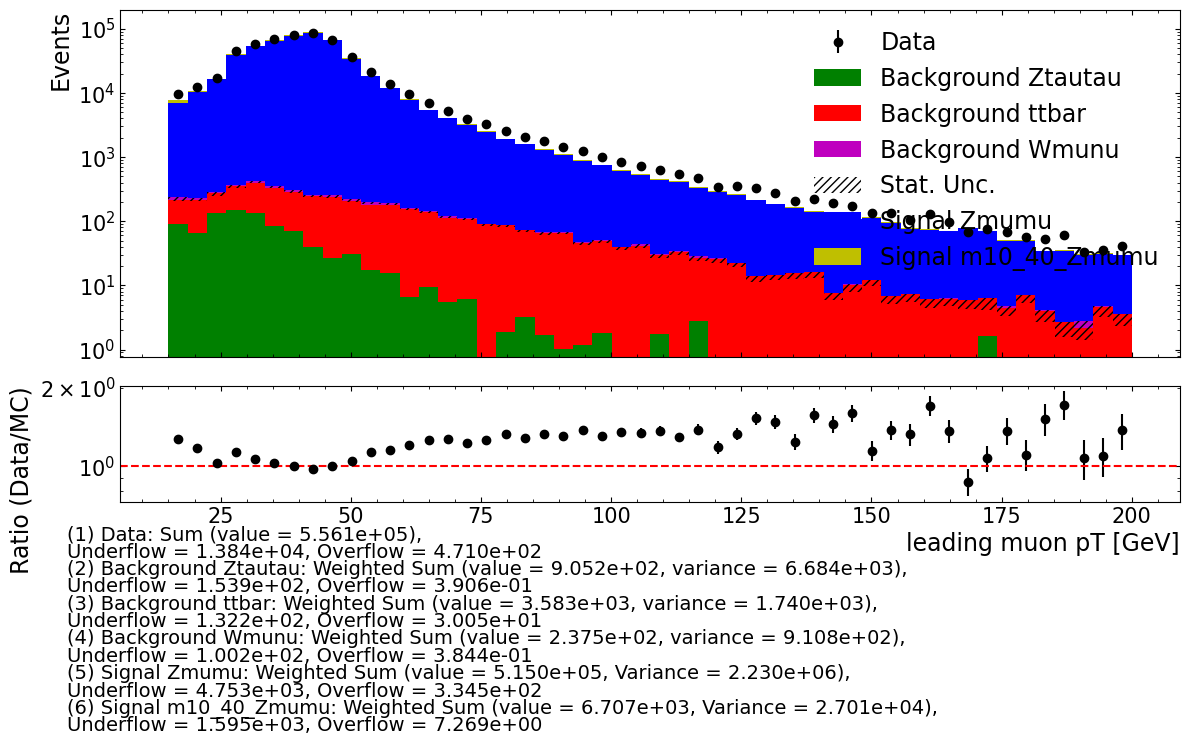

In [18]:
#muon os pt
plot_variable = 'lep_pt[0]'
xmin, xmax = 15, 200
num_bins = 50
x_label = 'leading muon pT [GeV]'

fig_mu_ospt, hists_mu_ospt= plot_stacked_hist(plot_dict_mu_OS, plot_variable, color_list,
                               num_bins, xmin, xmax, x_label,
                               logy=True, show_text=True, residual_plot=True, save_fig=False)

Elapsed time = 0.2s


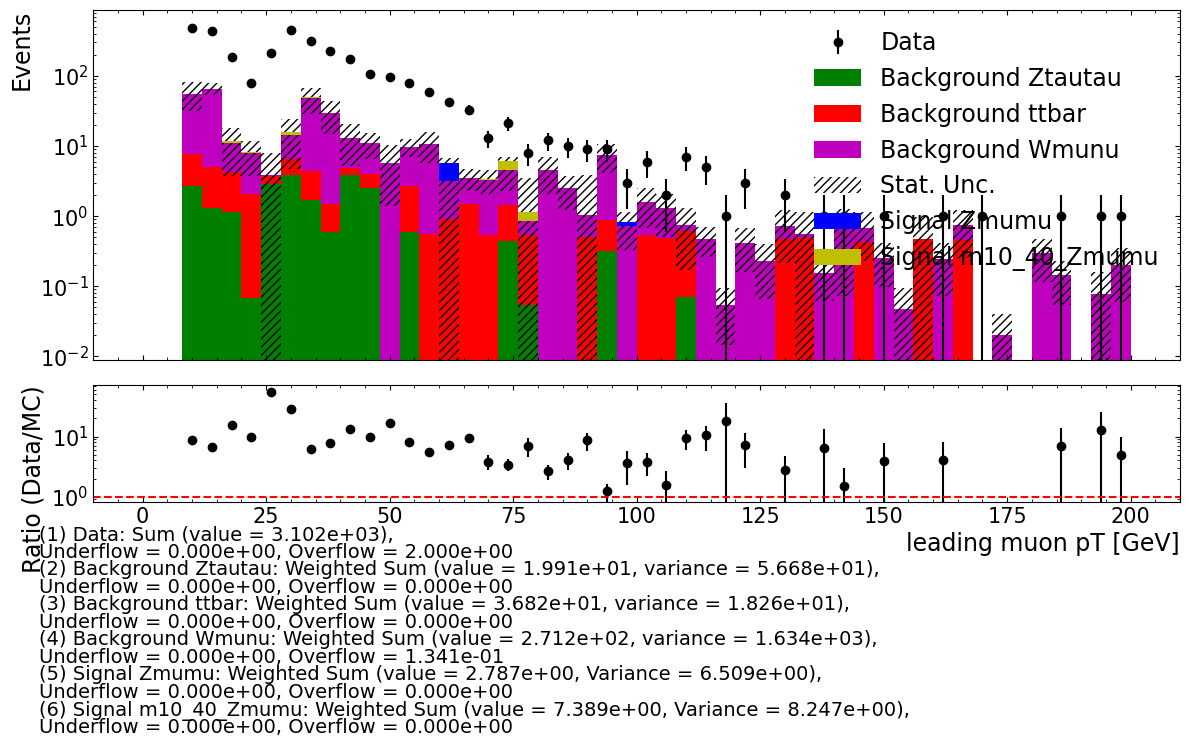

In [19]:
#muon SS pt
plot_variable = 'lep_pt[0]'
xmin, xmax = 0, 200
num_bins = 50
x_label = 'leading muon pT [GeV]'

fig_mu_sspt, hists_mu_sspt = plot_stacked_hist(plot_dict_mu_SS, plot_variable, color_list,
                               num_bins, xmin, xmax, x_label,
                               logy=True, show_text=True, residual_plot=True, save_fig=False)

In [20]:
#Isolation by absolute cut and relative cut functions

def apply_iso_cut(arr, ptcone_cut=None, etcone_cut=None):
    mask = (arr["lep_n"] >= 2)
    if ptcone_cut is not None:
        mask = mask & (arr["lep_ptvarcone30"][:, 0] < ptcone_cut) & (arr["lep_ptvarcone30"][:, 1] < ptcone_cut)
    if etcone_cut is not None:
        mask = mask & (arr["lep_topoetcone20"][:, 0] < etcone_cut) & (arr["lep_topoetcone20"][:, 1] < etcone_cut)
    return arr[mask]
def apply_rel_iso_cut(arr, pt_rel=None, et_rel=None):
    mask = (arr["lep_n"] >= 2)

    if pt_rel is not None:
        mask = mask & (arr["lep_ptvarcone30"][:,0]/arr["lep_pt"][:,0] < pt_rel) \
                    & (arr["lep_ptvarcone30"][:,1]/arr["lep_pt"][:,1] < pt_rel)

    if et_rel is not None:
        mask = mask & (arr["lep_topoetcone20"][:,0]/arr["lep_pt"][:,0] < et_rel) \
                    & (arr["lep_topoetcone20"][:,1]/arr["lep_pt"][:,1] < et_rel)

    return arr[mask]

In [21]:
"""
PT_rel = 0.06

plot_dict_cut_mu_OS_pt_rel = {}
for name, arr in plot_dict_mu_OS.items():
    plot_dict_cut_mu_OS_pt_rel[name] = apply_rel_iso_cut(arr, pt_rel=PT_rel)
"""

'\nPT_rel = 0.06\n\nplot_dict_cut_mu_OS_pt_rel = {}\nfor name, arr in plot_dict_mu_OS.items():\n    plot_dict_cut_mu_OS_pt_rel[name] = apply_rel_iso_cut(arr, pt_rel=PT_rel)\n'

In [22]:
"""
ET_rel = 0.06
plot_dict_cut_mu_OS_pt_et_rel = {}
for name, arr in plot_dict_cut_mu_OS_pt_rel.items():
    plot_dict_cut_mu_OS_pt_et_rel[name] = apply_rel_iso_cut(arr, et_rel=ET_rel)
"""

'\nET_rel = 0.06\nplot_dict_cut_mu_OS_pt_et_rel = {}\nfor name, arr in plot_dict_cut_mu_OS_pt_rel.items():\n    plot_dict_cut_mu_OS_pt_et_rel[name] = apply_rel_iso_cut(arr, et_rel=ET_rel)\n'

Elapsed time = 0.4s


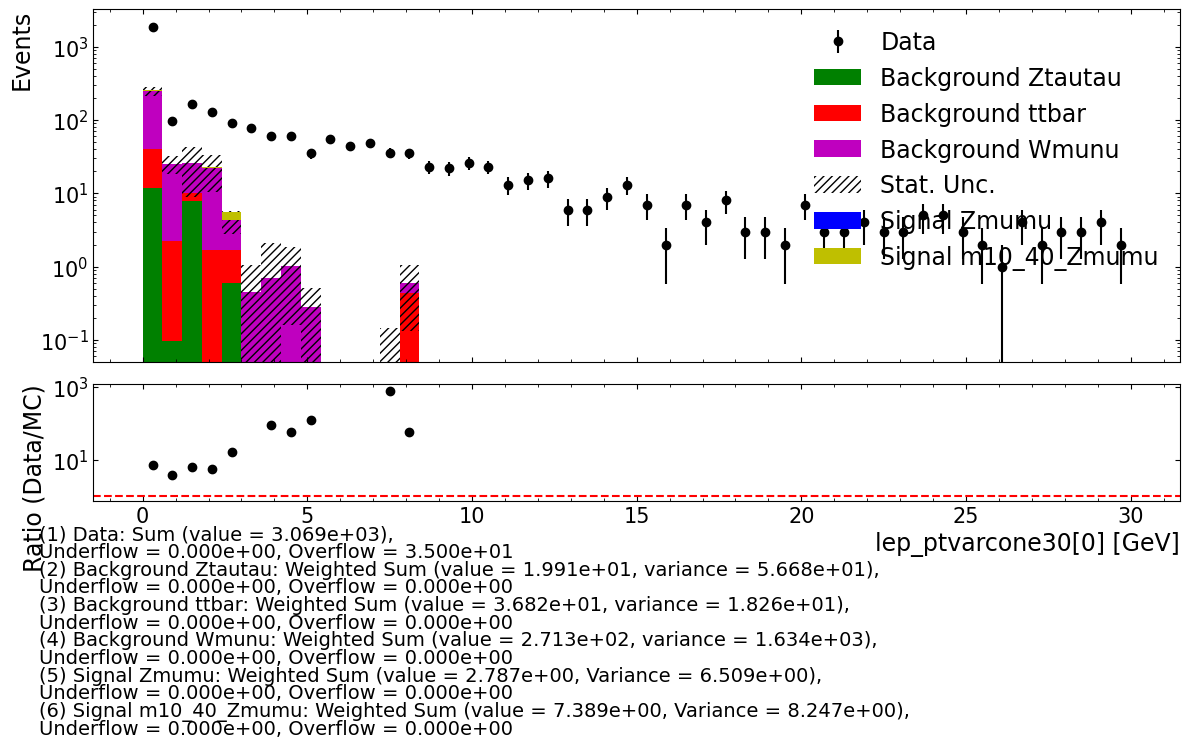

In [23]:
#muon SS ptcone
plot_variable = 'lep_ptvarcone30[0]'
xmin, xmax = 0, 30
num_bins = 50
x_label = 'lep_ptvarcone30[0] [GeV]'

fig_mu_sspt, hists_mu_sspt = plot_stacked_hist(plot_dict_mu_SS, plot_variable, color_list,
                               num_bins, xmin, xmax, x_label,
                               logy=True, show_text=True, residual_plot=True, save_fig=False)

Elapsed time = 0.2s


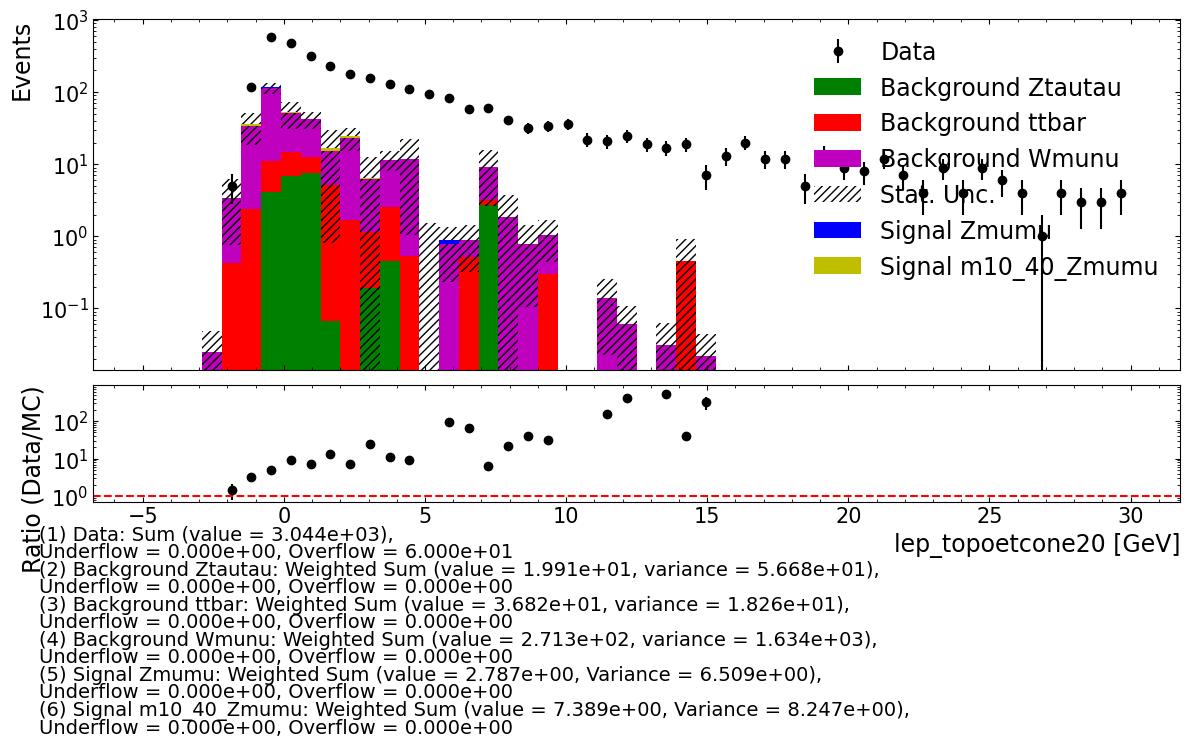

In [24]:
#muon SS etcone
plot_variable = 'lep_topoetcone20[0]'
xmin, xmax = -5, 30
num_bins = 50
x_label = 'lep_topoetcone20 [GeV]'

fig_mu_sspt, hists_mu_sspt = plot_stacked_hist(plot_dict_mu_SS, plot_variable, color_list,
                               num_bins, xmin, xmax, x_label,
                               logy=True, show_text=True, residual_plot=True, save_fig=False)

In [25]:
#Zmumu cuts
pt_cuts = [2,3,4,5,6]
et_cuts = [4,5,6,8,10]

def eff_both_two(arr, ptcut, etcut):
    mask = (
        (arr["lep_ptvarcone30"][:,0] < ptcut) & (arr["lep_ptvarcone30"][:,1] < ptcut) &
        (arr["lep_topoetcone20"][:,0] < etcut) & (arr["lep_topoetcone20"][:,1] < etcut)
    )
    return float(ak.sum(mask) / len(arr))

rows = []
for ptcut in pt_cuts:
    for etcut in et_cuts:
        eos = eff_both_two(plot_dict_mu_OS["Data"], ptcut, etcut)
        ess = eff_both_two(plot_dict_mu_SS["Data"], ptcut, etcut)
        rows.append({
            "ptcone_cut": ptcut,
            "etcone_cut": etcut,
            "OS kept": eos,
            "SS kept": ess,
            "SS rejected": 1-ess,
            "OS/SS": eos/ess if ess>0 else np.inf
        })

df_grid = pd.DataFrame(rows)

# best combos by separation, but keep OS reasonable
df_best = df_grid[df_grid["OS kept"] >= 0.90].sort_values("OS/SS", ascending=False)
display(df_best.head(20))

,ptcone_cut,etcone_cut,OS kept,SS kept,SS rejected,OS/SS
2,2,6,0.900009,0.314111,0.685889,2.865258
6,3,5,0.915027,0.343106,0.656894,2.666895
10,4,4,0.904704,0.343428,0.656572,2.634335
3,2,8,0.908421,0.350193,0.649807,2.594055
7,3,6,0.924943,0.368235,0.631765,2.511832
15,5,4,0.909026,0.370490,0.629510,2.453579
4,2,10,0.912155,0.376289,0.623711,2.424083
11,4,5,0.924640,0.385309,0.614691,2.399735
20,6,4,0.911326,0.397874,0.602126,2.290490
8,3,8,0.933738,0.410760,0.589240,2.273193


In [26]:
Zmumu_PTcone_cut = 2

plot_dict_cut_mu_OS_pt = {}
for name, arr in plot_dict_mu_OS.items():
    plot_dict_cut_mu_OS_pt[name] = apply_iso_cut(arr, ptcone_cut=Zmumu_PTcone_cut)

In [27]:
Zmumu_ETcone_cut = 6

plot_dict_cut_mu_OS_pt_et = {}
for name, arr in plot_dict_cut_mu_OS_pt.items():
    plot_dict_cut_mu_OS_pt_et[name] = apply_iso_cut(arr, etcone_cut=Zmumu_ETcone_cut)

Elapsed time = 0.9s


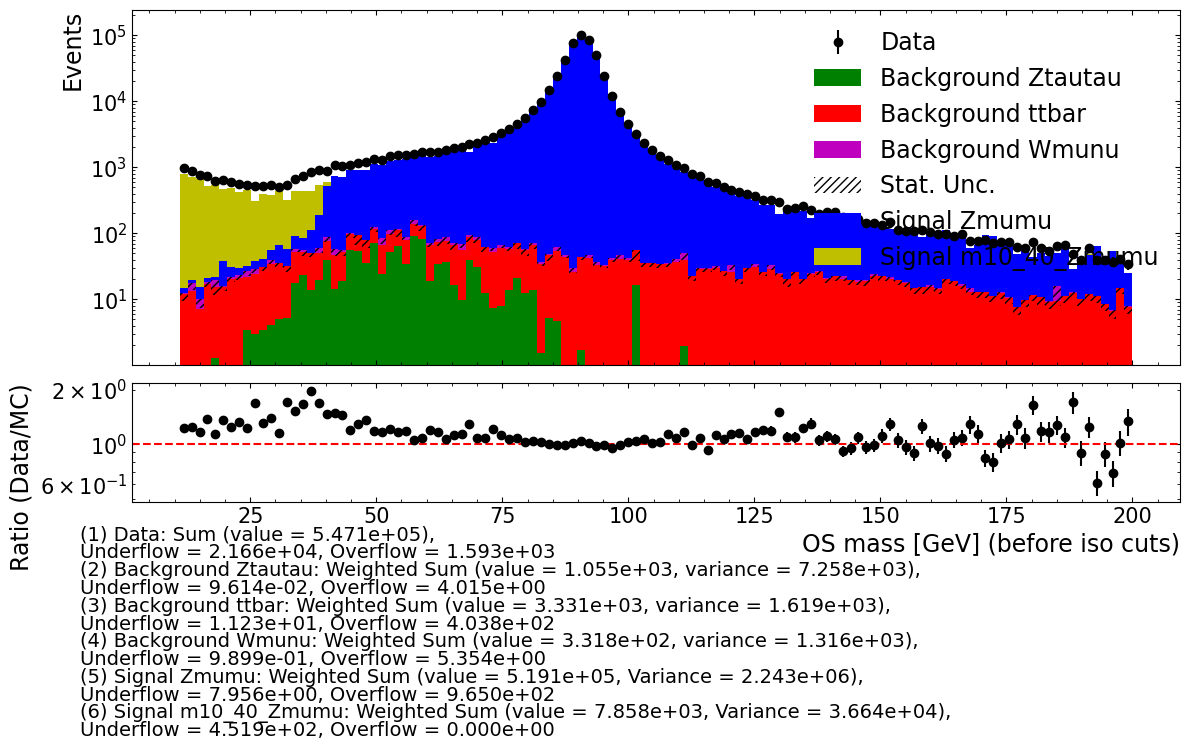

Elapsed time = 0.6s


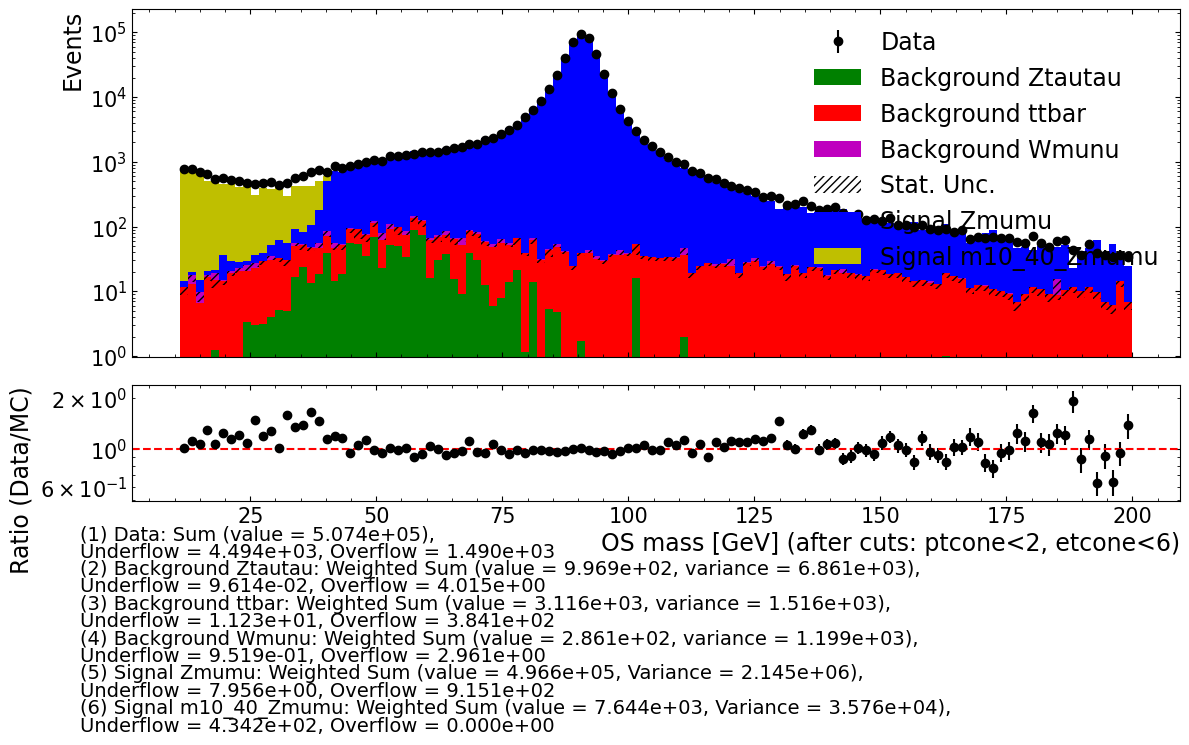

(<Figure size 1200x800 with 2 Axes>,
 [Hist(Regular(120, 11, 200, name='Data'), storage=Double()) # Sum: 507353.0 (513337.0 with flow),
  Hist(Regular(120, 11, 200, name='Background Ztautau'), storage=Weight()) # Sum: WeightedSum(value=996.897, variance=6860.85) (WeightedSum(value=1001.01, variance=6869.01) with flow),
  Hist(Regular(120, 11, 200, name='Background ttbar'), storage=Weight()) # Sum: WeightedSum(value=3115.73, variance=1515.77) (WeightedSum(value=3511.02, variance=1708.77) with flow),
  Hist(Regular(120, 11, 200, name='Background Wmunu'), storage=Weight()) # Sum: WeightedSum(value=286.111, variance=1199) (WeightedSum(value=290.024, variance=1202.95) with flow),
  Hist(Regular(120, 11, 200, name='Signal Zmumu'), storage=Weight()) # Sum: WeightedSum(value=496560, variance=2.14458e+06) (WeightedSum(value=497483, variance=2.14789e+06) with flow),
  Hist(Regular(120, 11, 200, name='Signal m10_40_Zmumu'), storage=Weight()) # Sum: WeightedSum(value=7644.2, variance=35761.1) (Wei

In [28]:
plot_dict_mu_OS_cut = {k: apply_iso_cut(v, Zmumu_PTcone_cut, Zmumu_ETcone_cut) for k, v in plot_dict_mu_OS.items()}
color_list = ['k', 'b', 'y', 'g', 'r', 'm']

plot_stacked_hist(plot_dict_mu_OS, 'mass', color_list,
                  num_bins=120, xmin=11, xmax=200,
                  x_label='OS mass [GeV] (before iso cuts)',
                  logy=True, show_text=True, residual_plot=True, save_fig=False) #without cuts

plot_stacked_hist(plot_dict_mu_OS_cut, 'mass', color_list,
                  num_bins=120, xmin=11, xmax=200,
                  x_label=f'OS mass [GeV] (after cuts: ptcone<{Zmumu_PTcone_cut}, etcone<{Zmumu_ETcone_cut})',
                  logy=True, show_text=True, residual_plot=True, save_fig=False) #with cuts

Elapsed time = 0.7s


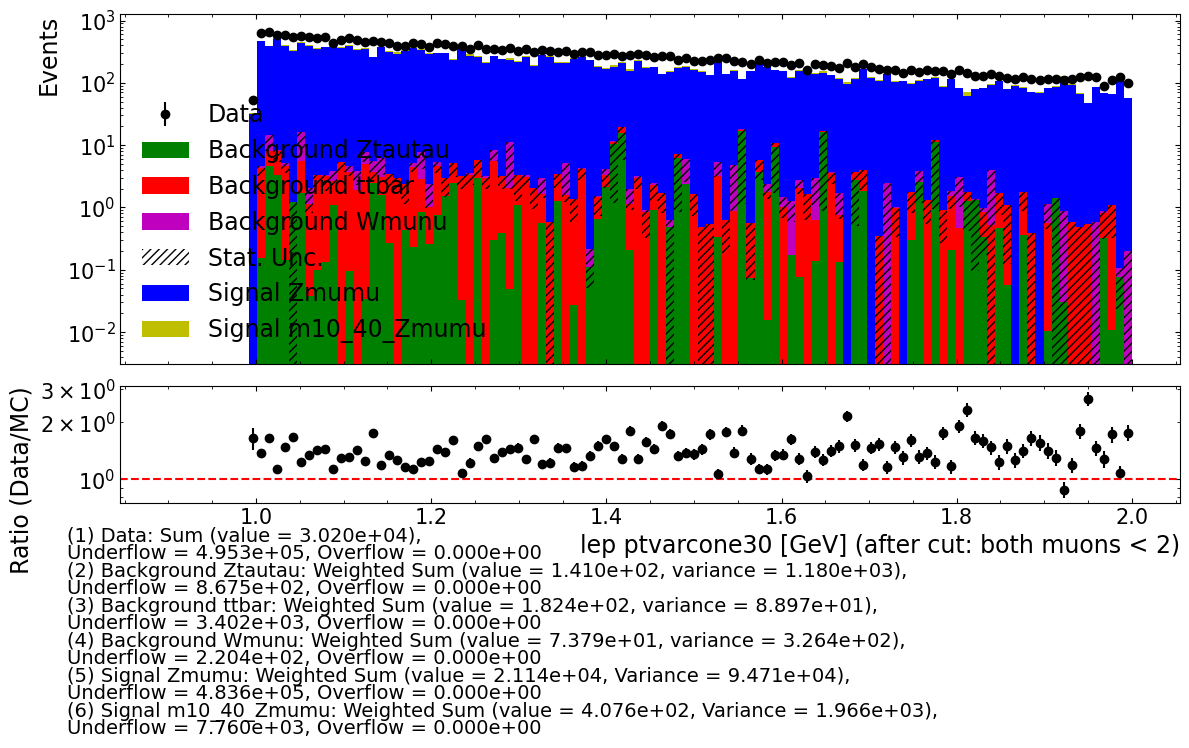

In [29]:
# muon os ptcone abs cut
plot_dict = {
    'Data' : pt_data['2to4lep_0_02'],
    'Signal Zmumu' : pt_data['Zmumu_0_02'], 
    'Signal m10_40_Zmumu' : pt_data['m10_40_Zmumu_0_02'], 
    'Background Ztautau': pt_data['Ztautau_0_02'],
    'Background ttbar' : pt_data['ttbar_0_02'], 
    'Background Wmunu' : pt_data['Wmunu_0_02'],
}

color_list = ['k', 'b', 'y', 'g', 'r', 'm'] # Black (data), blue (signal), yellow (signal), green (Ztautau), red (ttbar), magenta (Wmunu')

# Variable to plot on the PTcone_cut-axis
plot_variable = 'lep_ptvarcone30[0]'

xmin, xmax = 0.9, Zmumu_PTcone_cut # Define histogram bin range and PTcone_cut-axis limits 
num_bins = 120 # Number of histogram bins
x_label = f'lep ptvarcone30 [GeV] (after cut: both muons < {Zmumu_PTcone_cut})' # PTcone_cut-axis label 

# Plot the histogram
fig, hists = plot_stacked_hist(plot_dict_cut_mu_OS_pt, plot_variable, color_list,
                               num_bins, xmin, xmax, x_label, logy=True, show_text=True, residual_plot=True, save_fig=False)

Elapsed time = 0.9s


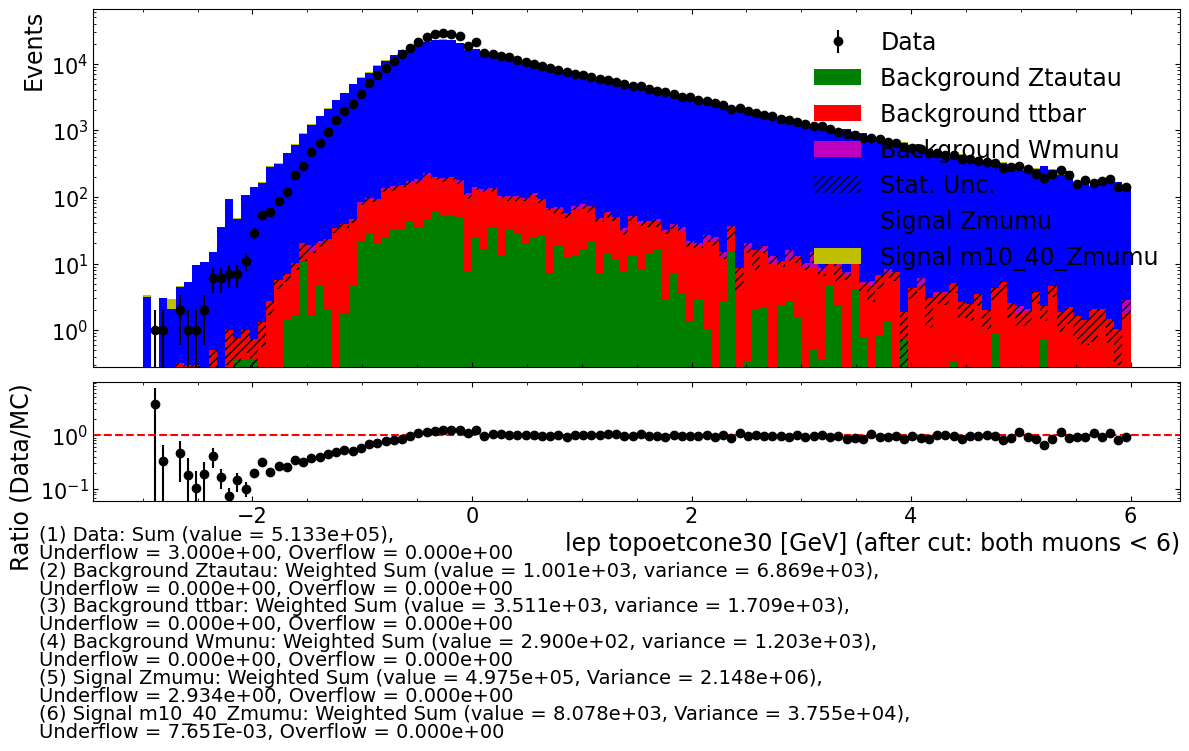

In [30]:
# muon os etcone abs cut
plot_dict = {
    'Data' : pt_data['2to4lep_0_02'],
    'Signal Zmumu' : pt_data['Zmumu_0_02'], 
    'Signal m10_40_Zmumu' : pt_data['m10_40_Zmumu_0_02'], 
    'Background Ztautau': pt_data['Ztautau_0_02'],
    'Background ttbar' : pt_data['ttbar_0_02'], 
    'Background Wmunu' : pt_data['Wmunu_0_02'],
}

color_list = ['k', 'b', 'y', 'g', 'r', 'm'] # Black (data), blue (signal), yellow (signal), green (Ztautau), red (ttbar), magenta (Wmunu')

# Variable to plot on the PTcone_cut-axis
plot_variable = 'lep_topoetcone20[0]'

xmin, xmax = -3, Zmumu_ETcone_cut # Define histogram bin range and x-axis limits 
num_bins = 120 # Number of histogram bins
x_label = f'lep topoetcone30 [GeV] (after cut: both muons < {Zmumu_ETcone_cut})' # x-axis label 

# Plot the histogram
fig, hists = plot_stacked_hist(plot_dict_cut_mu_OS_pt_et, plot_variable, color_list,
                               num_bins, xmin, xmax, x_label, logy=True, show_text=True, residual_plot=True, save_fig=False)

Elapsed time = 0.5s


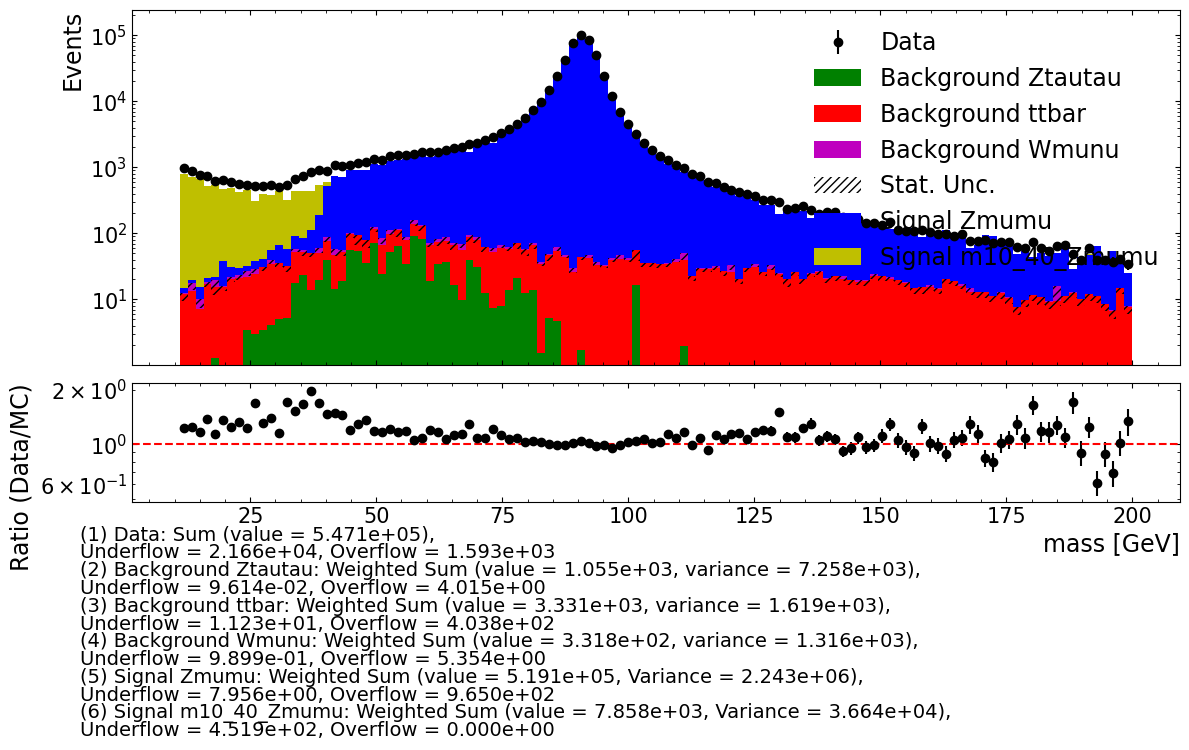

In [31]:
#muon OS mass
plot_variable = 'mass'
xmin, xmax = 11, 200
num_bins = 120
x_label = 'mass [GeV]'

fig_mu_osm, hists_mu_osm = plot_stacked_hist(plot_dict_mu_OS, plot_variable, color_list,
                               num_bins, xmin, xmax, x_label,
                               logy=True, show_text=True, residual_plot=True, save_fig=False)

In [32]:
PTCUTS = [2, 3, 4, 5, 6]     # GeV
ETCUTS = [2, 3, 4, 5, 6]     # GeV
MASS_LOW, MASS_HIGH = 66, 116 

In [33]:
def mc_yield_in_mass(arr, mass_low, mass_high, wvar="totalWeight"):
    m = arr["mass"]
    w = arr[wvar]
    mask = (m > mass_low) & (m < mass_high)
    return float(ak.sum(w[mask]))

def data_count_in_mass(arr, mass_low, mass_high):
    m = arr["mass"]
    mask = (m > mass_low) & (m < mass_high)
    return int(ak.sum(mask))

In [34]:
def Zmumu_row(plot_dict, ptcut, etcut, mass_low, mass_high):
    # apply cuts to each sample
    cut_dict = {k: apply_iso_cut(v, ptcone_cut=ptcut, etcone_cut=etcut) for k, v in plot_dict.items()}

    # Signal = Zmumu + low-mass DY sample (it will contribute only if mass window overlaps)
    S = mc_yield_in_mass(cut_dict["Signal Zmumu"], mass_low, mass_high) + mc_yield_in_mass(cut_dict["Signal m10_40_Zmumu"], mass_low, mass_high)

    # Backgrounds
    B = (mc_yield_in_mass(cut_dict["Background Ztautau"], mass_low, mass_high) +
         mc_yield_in_mass(cut_dict["Background ttbar"], mass_low, mass_high) +
         mc_yield_in_mass(cut_dict["Background Wmunu"], mass_low, mass_high))

    MC = S + B
    Data = data_count_in_mass(cut_dict["Data"], mass_low, mass_high)

    return {
        "ptcone_cut (GeV)": ptcut,
        "etcone_cut (GeV)": etcut,
        f"Mass window (GeV)": f"{mass_low}-{mass_high}",
        "S (MC weighted)": S,
        "B (MC weighted)": B,
        "S/B": (S / B) if B > 0 else np.nan,
        "MC total S+B": MC,
        "Data (count)": Data,
        "Data/MC": (Data / MC) if MC > 0 else np.nan,
        "S/sqrt(S+B)": (S / np.sqrt(MC)) if MC > 0 else np.nan,
    }


In [35]:
rows = []
for ptcut in PTCUTS:
    for etcut in ETCUTS:
        rows.append(Zmumu_row(plot_dict_mu_OS, ptcut, etcut, MASS_LOW, MASS_HIGH))

df = pd.DataFrame(rows)

# sort by best "significance-like" as an example
df_sorted = df.sort_values(by="S/sqrt(S+B)", ascending=False)

df_sorted.head(20).style.format({
    "S (MC weighted)": "{:,.2f}",
    "B (MC weighted)": "{:,.2f}",
    "S/B": "{:.4f}",
    "MC total S+B": "{:,.2f}",
    "Data/MC": "{:.4f}",
    "S/sqrt(S+B)": "{:.3f}",
})

,ptcone_cut (GeV),etcone_cut (GeV),Mass window (GeV),S (MC weighted),B (MC weighted),S/B,MC total S+B,Data (count),Data/MC,S/sqrt(S+B)
24,6,6,66-116,"485,812.39","1,548.35",313.7611,"487,360.74",490109,1.0056,695.894
19,5,6,66-116,"485,351.61","1,546.40",313.8584,"486,898.02",488946,1.0042,695.565
14,4,6,66-116,"483,934.11","1,537.65",314.7234,"485,471.76",486693,1.0025,694.551
9,3,6,66-116,"480,350.55","1,510.44",318.0193,"481,861.00",481916,1.0001,691.986
23,6,5,66-116,"479,893.40","1,529.93",313.6692,"481,423.33",484848,1.0071,691.642
18,5,5,66-116,"479,455.18","1,527.99",313.7823,"480,983.17",483747,1.0057,691.326
13,4,5,66-116,"478,116.43","1,519.69",314.6142,"479,636.12",481585,1.0041,690.363
8,3,5,66-116,"474,659.09","1,493.18",317.8854,"476,152.27",476904,1.0016,687.874
4,2,6,66-116,"471,612.19","1,450.70",325.0937,"473,062.89",469335,0.9921,685.686
22,6,4,66-116,"468,722.93","1,494.38",313.6571,"470,217.31",474404,1.0089,683.545


Elapsed time = 0.5s


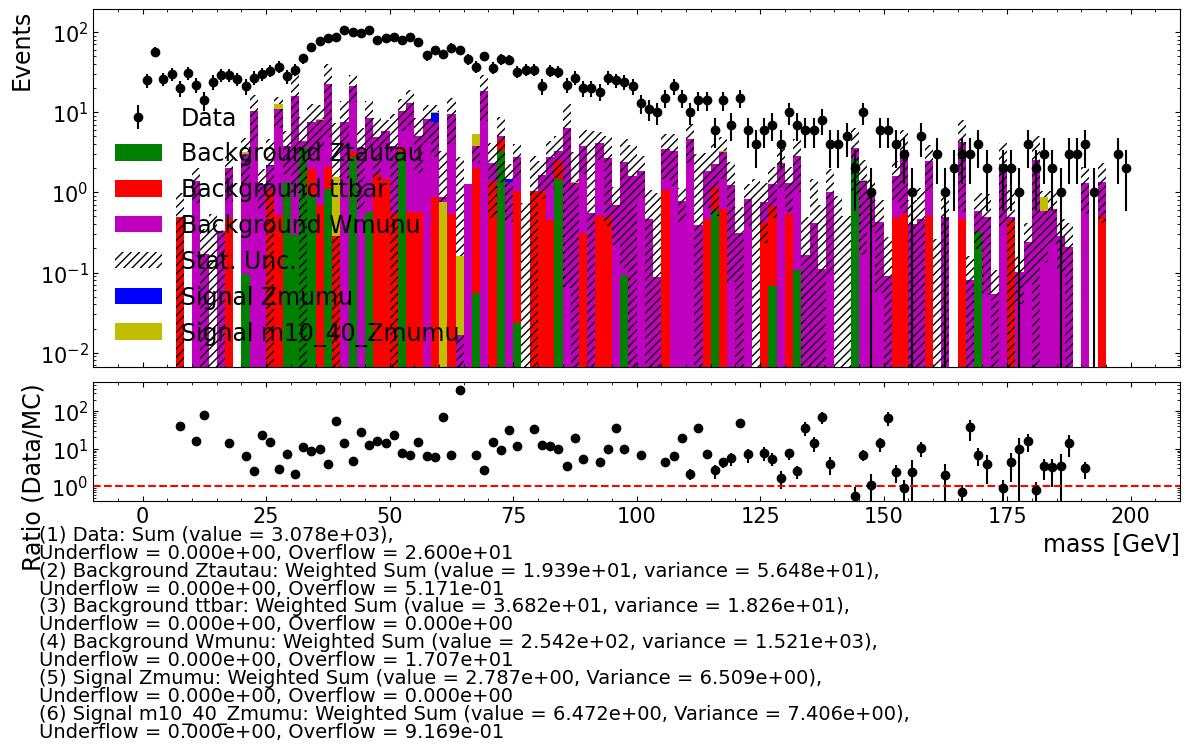

In [36]:
#muon SS mass
plot_variable = 'mass'
xmin, xmax = 0, 200
num_bins = 120
x_label = 'mass [GeV]'

fig_mu_ssm, hists_mu_ssm = plot_stacked_hist(plot_dict_mu_SS, plot_variable, color_list,
                               num_bins, xmin, xmax, x_label,
                               logy=True, show_text=True, residual_plot=True, save_fig=False)

In [37]:
'''
def count_after_cuts(arr, ptcut=None, etcut=None, mlow=None, mhigh=None):
    m = ak.ones_like(arr["mass"], dtype=bool)

    # require 2 leptons (safety)
    m = m & (arr["lep_n"] >= 2)

    if ptcut is not None:
        m = m & (arr["lep_ptvarcone30"][:,0] < ptcut) & (arr["lep_ptvarcone30"][:,1] < ptcut)
    if etcut is not None:
        m = m & (arr["lep_topoetcone20"][:,0] < etcut) & (arr["lep_topoetcone20"][:,1] < etcut)
    if (mlow is not None) and (mhigh is not None):
        m = m & (arr["mass"] > mlow) & (arr["mass"] < mhigh)

    return int(ak.sum(m))

def snr_from_os_ss(os_data, ss_data, ptcut, etcut, mwin=(66,116), k=1.0):
    mlow, mhigh = mwin
    N_os = count_after_cuts(os_data, ptcut, etcut, mlow, mhigh)
    N_ss = count_after_cuts(ss_data, ptcut, etcut, mlow, mhigh)

    B = k * N_ss
    S = N_os - B  # allow negative; we'll handle it below

    return {
        "ptcut": ptcut,
        "etcut": etcut,
        "N_OS": N_os,
        "N_SS": N_ss,
        "S = OS - k*SS": S,
        "B = k*SS": B,
        "S/B": (S/B) if B > 0 else np.nan,
    }
'''

'\ndef count_after_cuts(arr, ptcut=None, etcut=None, mlow=None, mhigh=None):\n    m = ak.ones_like(arr["mass"], dtype=bool)\n\n    # require 2 leptons (safety)\n    m = m & (arr["lep_n"] >= 2)\n\n    if ptcut is not None:\n        m = m & (arr["lep_ptvarcone30"][:,0] < ptcut) & (arr["lep_ptvarcone30"][:,1] < ptcut)\n    if etcut is not None:\n        m = m & (arr["lep_topoetcone20"][:,0] < etcut) & (arr["lep_topoetcone20"][:,1] < etcut)\n    if (mlow is not None) and (mhigh is not None):\n        m = m & (arr["mass"] > mlow) & (arr["mass"] < mhigh)\n\n    return int(ak.sum(m))\n\ndef snr_from_os_ss(os_data, ss_data, ptcut, etcut, mwin=(66,116), k=1.0):\n    mlow, mhigh = mwin\n    N_os = count_after_cuts(os_data, ptcut, etcut, mlow, mhigh)\n    N_ss = count_after_cuts(ss_data, ptcut, etcut, mlow, mhigh)\n\n    B = k * N_ss\n    S = N_os - B  # allow negative; we\'ll handle it below\n\n    return {\n        "ptcut": ptcut,\n        "etcut": etcut,\n        "N_OS": N_os,\n        "N_SS":

Elapsed time = 0.4s


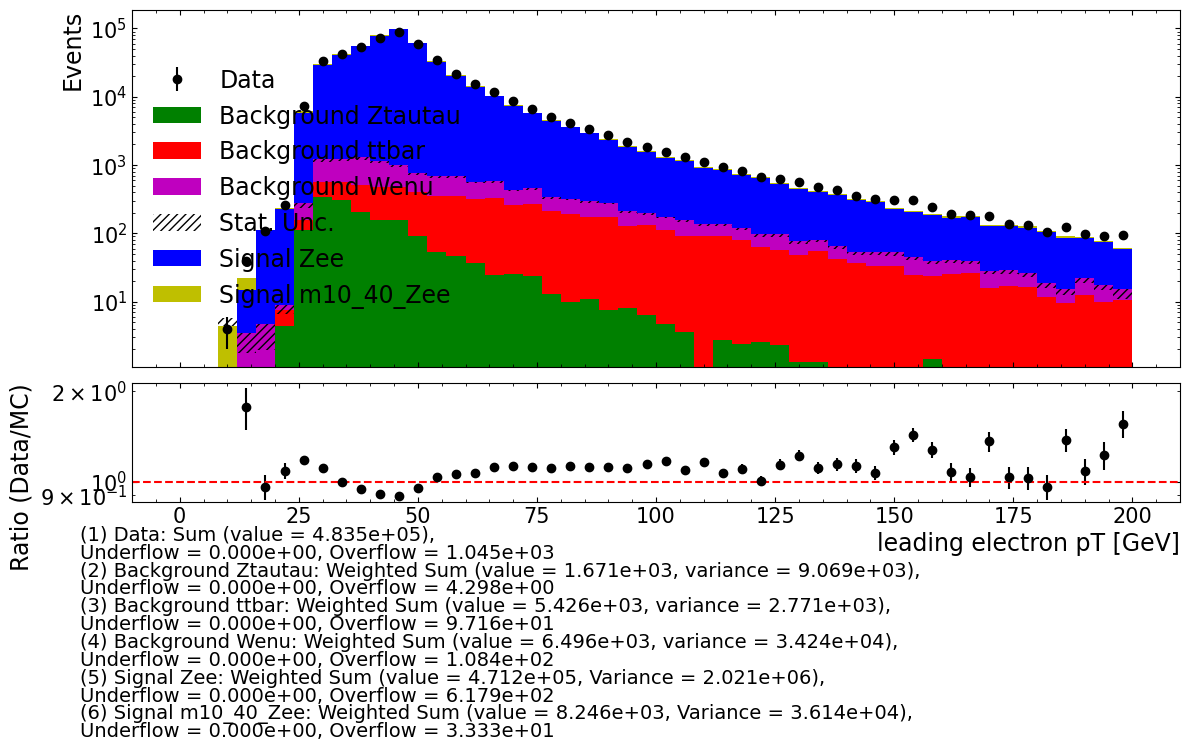

In [38]:
#electron_ospt
plot_variable = 'lep_pt[0]'
xmin, xmax = 0, 200
num_bins = 50
x_label = 'leading electron pT [GeV]'

fig_ee_ospt, hists_ee_ospt= plot_stacked_hist(plot_dict_ee_OS, plot_variable, color_list,
                               num_bins, xmin, xmax, x_label,
                               logy=True, show_text=True, residual_plot=True, save_fig=False)

In [39]:
def Zee_row(plot_dict, ptcut, etcut, mass_low, mass_high):
    # apply isolation cuts to each sample
    cut_dict = {k: apply_iso_cut(v, ptcone_cut=ptcut, etcone_cut=etcut)
                for k, v in plot_dict.items()}

    # Signal = Zee + low-mass DY Zee sample (adds only if mass window overlaps)
    S = (mc_yield_in_mass(cut_dict["Signal Zee"], mass_low, mass_high) +
         mc_yield_in_mass(cut_dict["Signal m10_40_Zee"], mass_low, mass_high))

    # Backgrounds
    B = (mc_yield_in_mass(cut_dict["Background Ztautau"], mass_low, mass_high) +
         mc_yield_in_mass(cut_dict["Background ttbar"],   mass_low, mass_high) +
         mc_yield_in_mass(cut_dict["Background Wenu"],    mass_low, mass_high))

    MC = S + B
    Data = data_count_in_mass(cut_dict["Data"], mass_low, mass_high)

    return {
        "ptcone_cut (GeV)": ptcut,
        "etcone_cut (GeV)": etcut,
        "Mass window (GeV)": f"{mass_low}-{mass_high}",
        "S (MC weighted)": S,
        "B (MC weighted)": B,
        "S/B": (S / B) if B > 0 else np.nan,
        "MC total S+B": MC,
        "Data (count)": Data,
        "Data/MC": (Data / MC) if MC > 0 else np.nan,
        "S/sqrt(S+B)": (S / np.sqrt(MC)) if MC > 0 else np.nan,
    }

In [40]:
#Zee
rows = []
for ptcut in pt_cuts:
    for etcut in et_cuts:
        eos = eff_both_two(plot_dict_ee_OS["Data"], ptcut, etcut)
        ess = eff_both_two(plot_dict_ee_SS["Data"], ptcut, etcut)
        rows.append({
            "ptcone_cut": ptcut,
            "etcone_cut": etcut,
            "OS kept": eos,
            "SS kept": ess,
            "SS rejected": 1 - ess,
            "OS/SS": eos / ess if ess > 0 else np.inf
        })

df_grid = pd.DataFrame(rows)

# best combos by separation, but keep OS reasonable
df_best = df_grid[df_grid["OS kept"] >= 0.90].sort_values("OS/SS", ascending=False)
display(df_best.head(20))

,ptcone_cut,etcone_cut,OS kept,SS kept,SS rejected,OS/SS
5,3,4,0.902287,0.521719,0.478281,1.729448
2,2,6,0.901280,0.523527,0.476473,1.721553
6,3,5,0.918894,0.544766,0.455234,1.686766
3,2,8,0.907610,0.538214,0.461786,1.686337
10,4,4,0.912592,0.541829,0.458171,1.684281
4,2,10,0.910376,0.546235,0.453765,1.666637
7,3,6,0.926689,0.559623,0.440377,1.655918
15,5,4,0.917769,0.558436,0.441564,1.643462
11,4,5,0.929728,0.567983,0.432017,1.636894
8,3,8,0.933368,0.576569,0.423431,1.618832


In [41]:
rows = []
for ptcut in PTCUTS:
    for etcut in ETCUTS:
        rows.append(Zee_row(plot_dict_ee_OS, ptcut, etcut, MASS_LOW, MASS_HIGH))

df = pd.DataFrame(rows)

# sort by best "significance-like" as an example
df_sorted = df.sort_values(by="S/B", ascending=False)

df_sorted.head(20).style.format({
    "S (MC weighted)": "{:,.2f}",
    "B (MC weighted)": "{:,.2f}",
    "S/B": "{:.4f}",
    "MC total S+B": "{:,.2f}",
    "Data/MC": "{:.4f}",
    "S/sqrt(S+B)": "{:.3f}",
})

,ptcone_cut (GeV),etcone_cut (GeV),Mass window (GeV),S (MC weighted),B (MC weighted),S/B,MC total S+B,Data (count),Data/MC,S/sqrt(S+B)
0,2,2,66-116,"342,280.58","1,456.34",235.0278,"343,736.92",332282,0.9667,583.807
1,2,3,66-116,"390,827.25","1,701.33",229.7185,"392,528.58",373154,0.9506,623.805
2,2,4,66-116,"411,261.72","1,829.48",224.7971,"413,091.20",389593,0.9431,639.875
5,3,2,66-116,"348,351.03","1,555.57",223.9374,"349,906.61",340459,0.9730,588.899
3,2,5,66-116,"420,247.01","1,881.81",223.3211,"422,128.82",396306,0.9388,646.818
4,2,6,66-116,"424,162.29","1,919.62",220.9618,"426,081.91",399363,0.9373,649.809
6,3,3,66-116,"398,086.20","1,822.85",218.3865,"399,909.05",382690,0.9569,629.501
10,4,2,66-116,"350,778.12","1,633.31",214.7657,"352,411.43",343598,0.9750,590.891
7,3,4,66-116,"419,031.54","1,972.73",212.4117,"421,004.28",399824,0.9497,645.808
8,3,5,66-116,"428,284.08","2,033.14",210.6511,"430,317.23",406803,0.9454,652.886


In [42]:
Zee_PTcone_cut = 3

plot_dict_cut_ee_OS_pt = {}
for name, arr in plot_dict_ee_OS.items():
    plot_dict_cut_ee_OS_pt[name] = apply_iso_cut(arr, ptcone_cut=Zee_PTcone_cut)

In [43]:
Zee_ETcone_cut = 4

plot_dict_cut_ee_OS_pt_et = {}
for name, arr in plot_dict_cut_ee_OS_pt.items():
    plot_dict_cut_ee_OS_pt_et[name] = apply_iso_cut(arr, etcone_cut=Zee_ETcone_cut)

Elapsed time = 0.4s


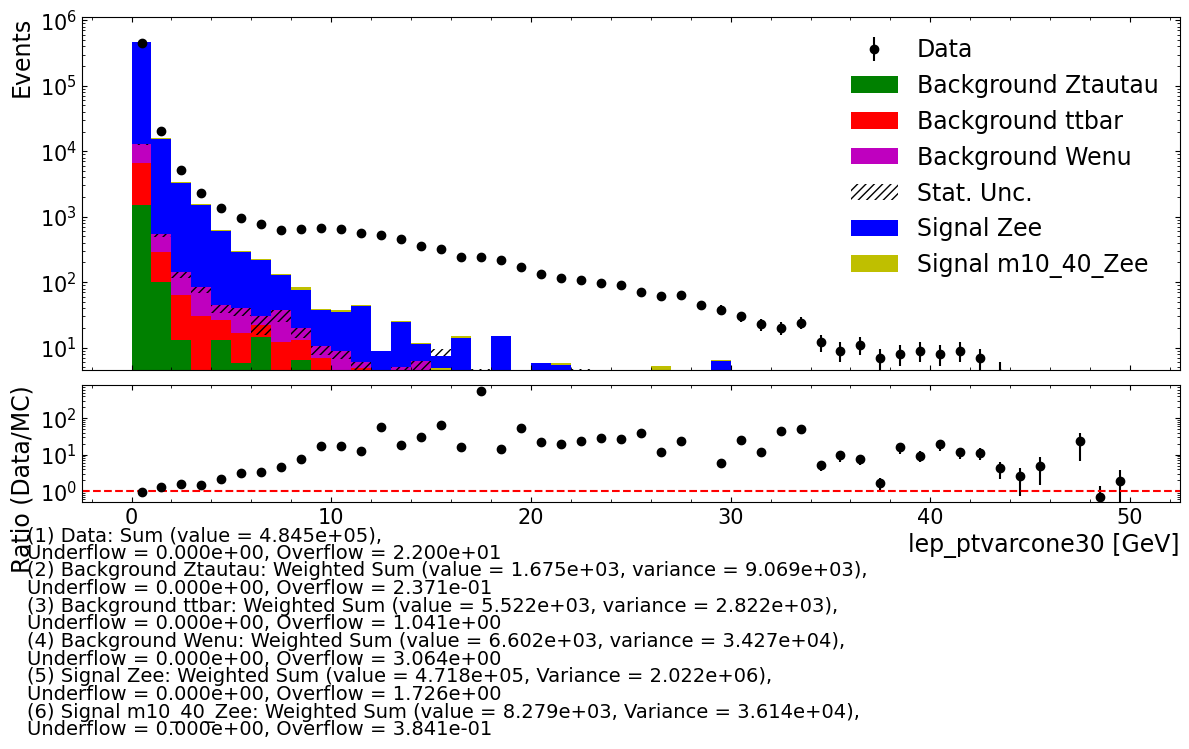

In [44]:
#electron_OS_ptcone
plot_variable = 'lep_ptvarcone30[0]'
xmin, xmax = 0, 50
num_bins = 50
x_label = 'lep_ptvarcone30 [GeV]'

fig_ee_ospt, hists_ee_ospt= plot_stacked_hist(plot_dict_ee_OS, plot_variable, color_list,
                               num_bins, xmin, xmax, x_label,
                               logy=True, show_text=True, residual_plot=True, save_fig=False)

Elapsed time = 0.5s


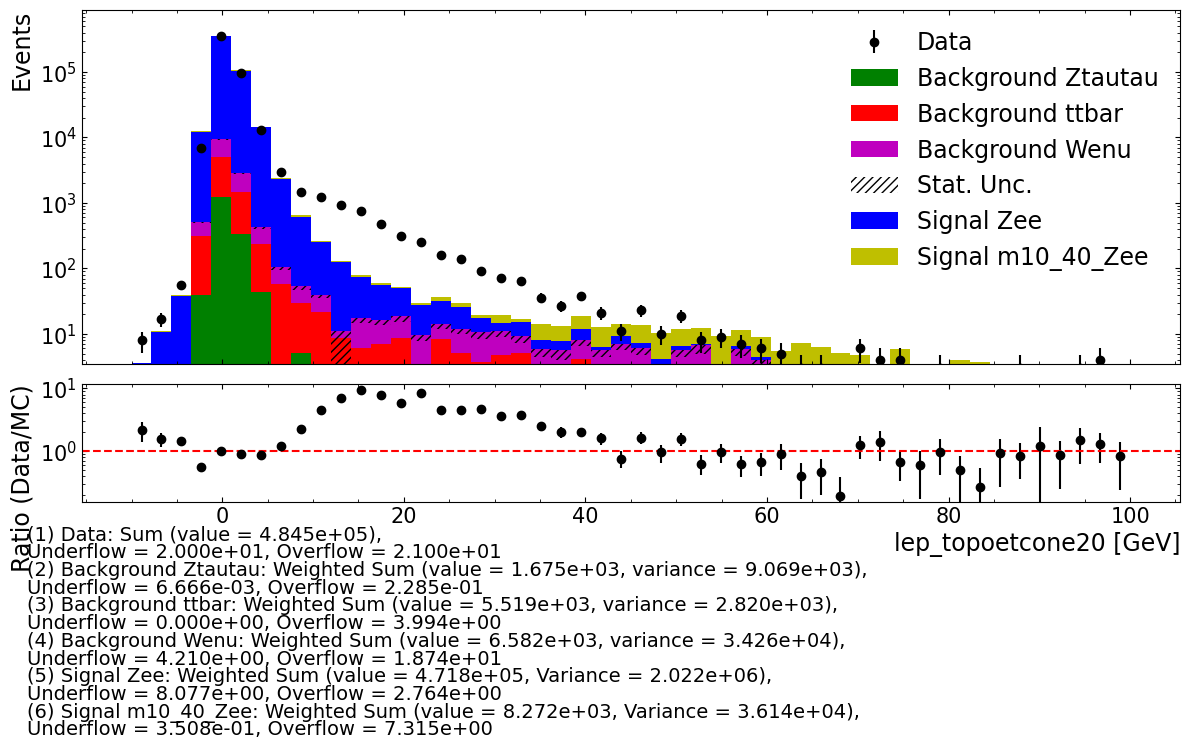

In [45]:
#electron_OS_etcone
plot_variable = 'lep_topoetcone20[0]'
xmin, xmax = -10, 100
num_bins = 50
x_label = 'lep_topoetcone20 [GeV]'

fig_ee_ospt, hists_ee_ospt= plot_stacked_hist(plot_dict_ee_OS, plot_variable, color_list,
                               num_bins, xmin, xmax, x_label,
                               logy=True, show_text=True, residual_plot=True, save_fig=False)

Elapsed time = 0.5s


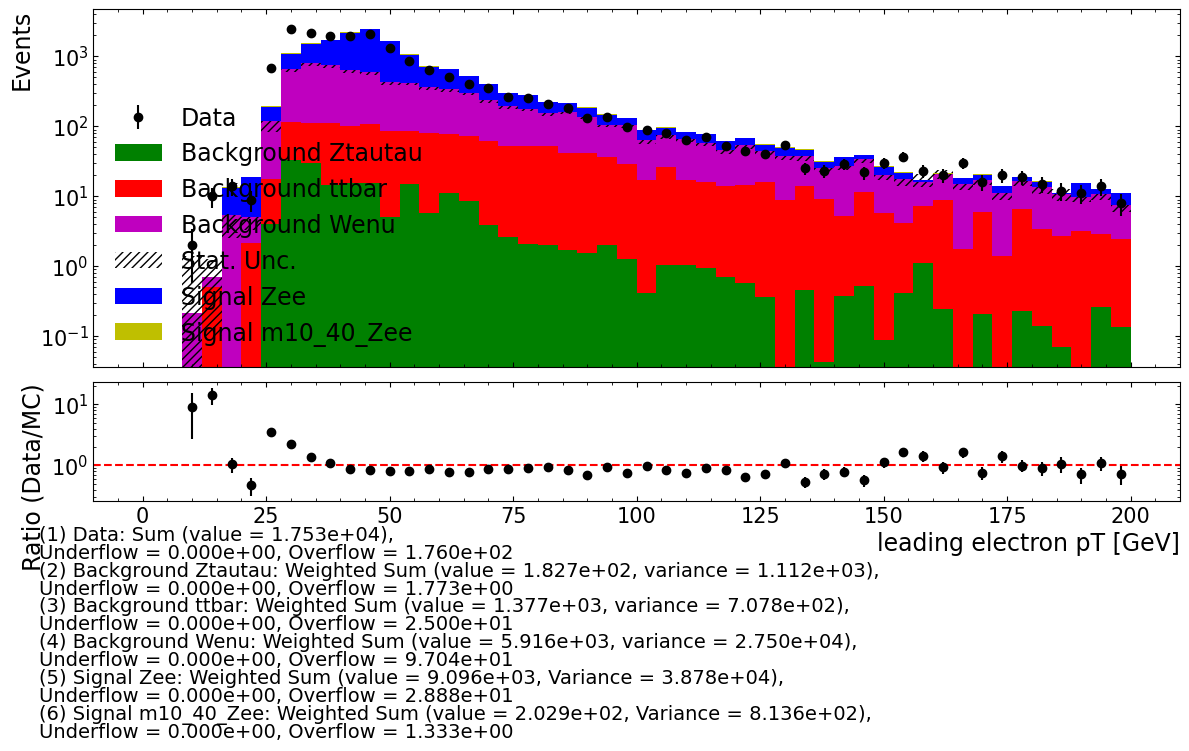

In [46]:
#electron_sspt
plot_variable = 'lep_pt[0]'
xmin, xmax = 0, 200
num_bins = 50
x_label = 'leading electron pT [GeV]'

fig_ee_sspt, hists_ee_sspt= plot_stacked_hist(plot_dict_ee_SS, plot_variable, color_list,
                               num_bins, xmin, xmax, x_label,
                               logy=True, show_text=True, residual_plot=True, save_fig=False)

Elapsed time = 0.3s


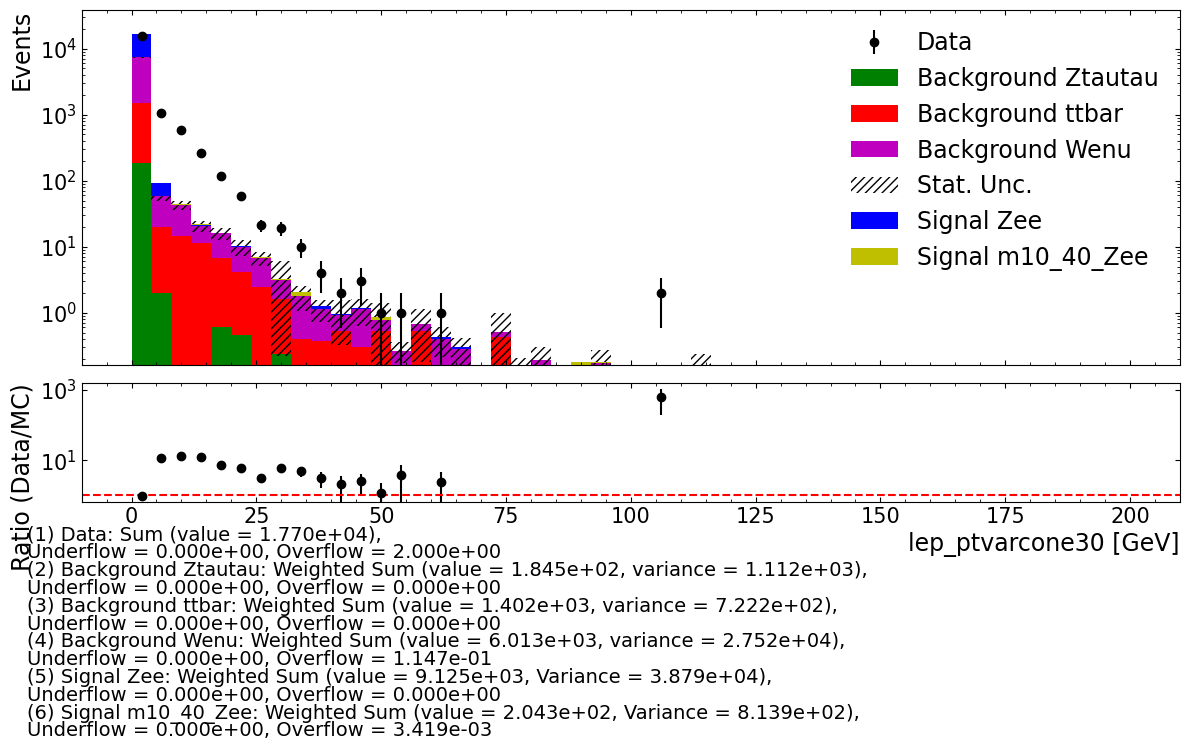

In [47]:
#electron_SS_ptcone
plot_variable = 'lep_ptvarcone30[0]'
xmin, xmax = 0, 200
num_bins = 50
x_label = 'lep_ptvarcone30 [GeV]'

fig_ee_sspt, hists_ee_sspt= plot_stacked_hist(plot_dict_ee_SS, plot_variable, color_list,
                               num_bins, xmin, xmax, x_label,
                               logy=True, show_text=True, residual_plot=True, save_fig=False)

Elapsed time = 0.3s


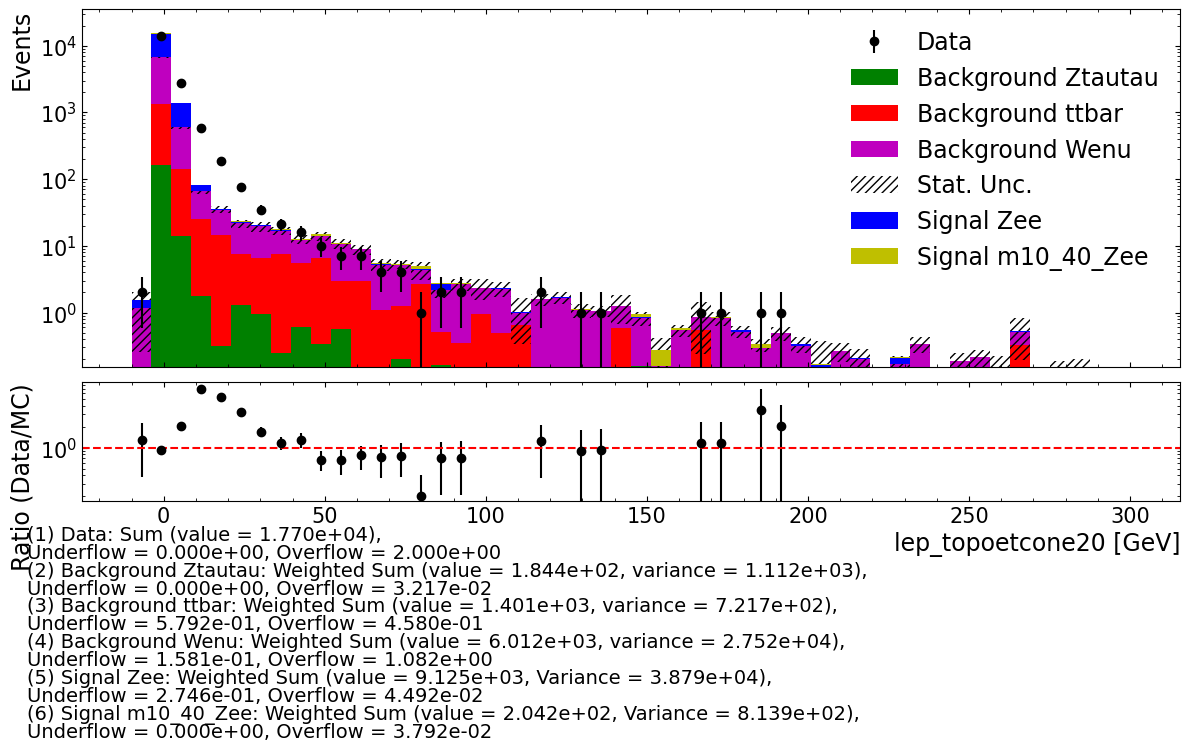

In [48]:
#electron_SS_etcone
plot_variable = 'lep_topoetcone20[0]'
xmin, xmax = -10, 300
num_bins = 50
x_label = 'lep_topoetcone20 [GeV]'

fig_ee_sspt, hists_ee_sspt= plot_stacked_hist(plot_dict_ee_SS, plot_variable, color_list,
                               num_bins, xmin, xmax, x_label,
                               logy=True, show_text=True, residual_plot=True, save_fig=False)

Elapsed time = 0.6s


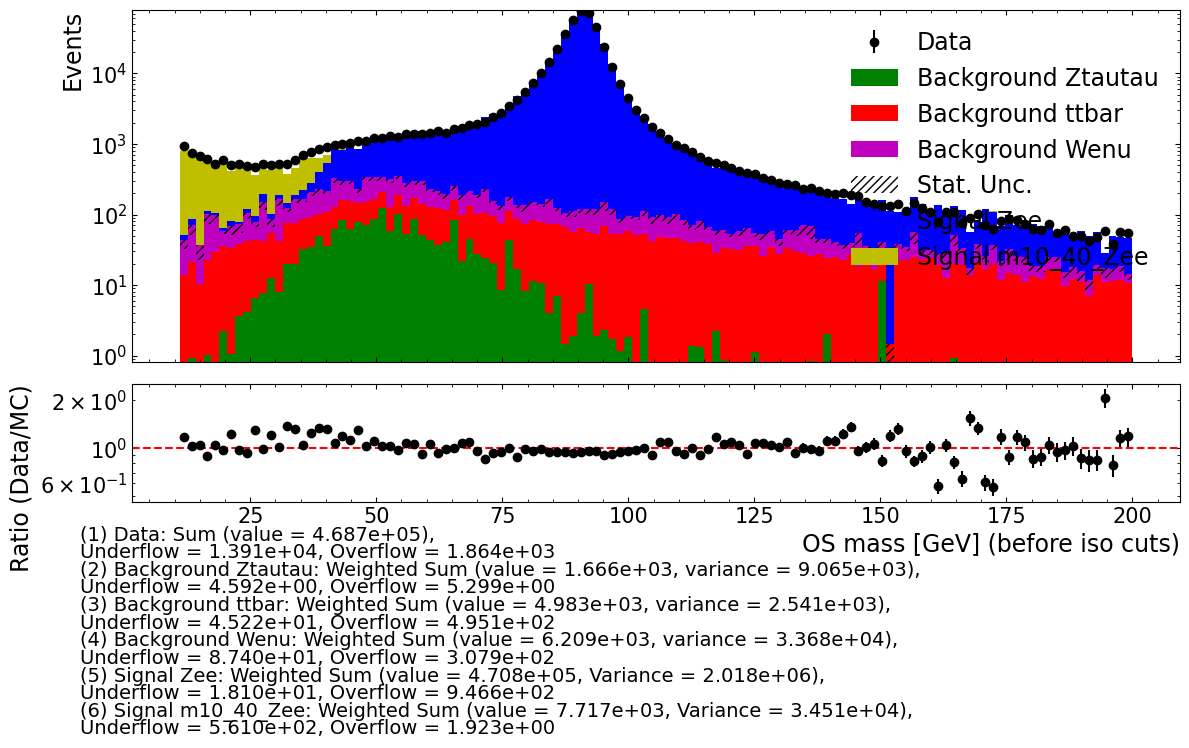

Elapsed time = 0.5s


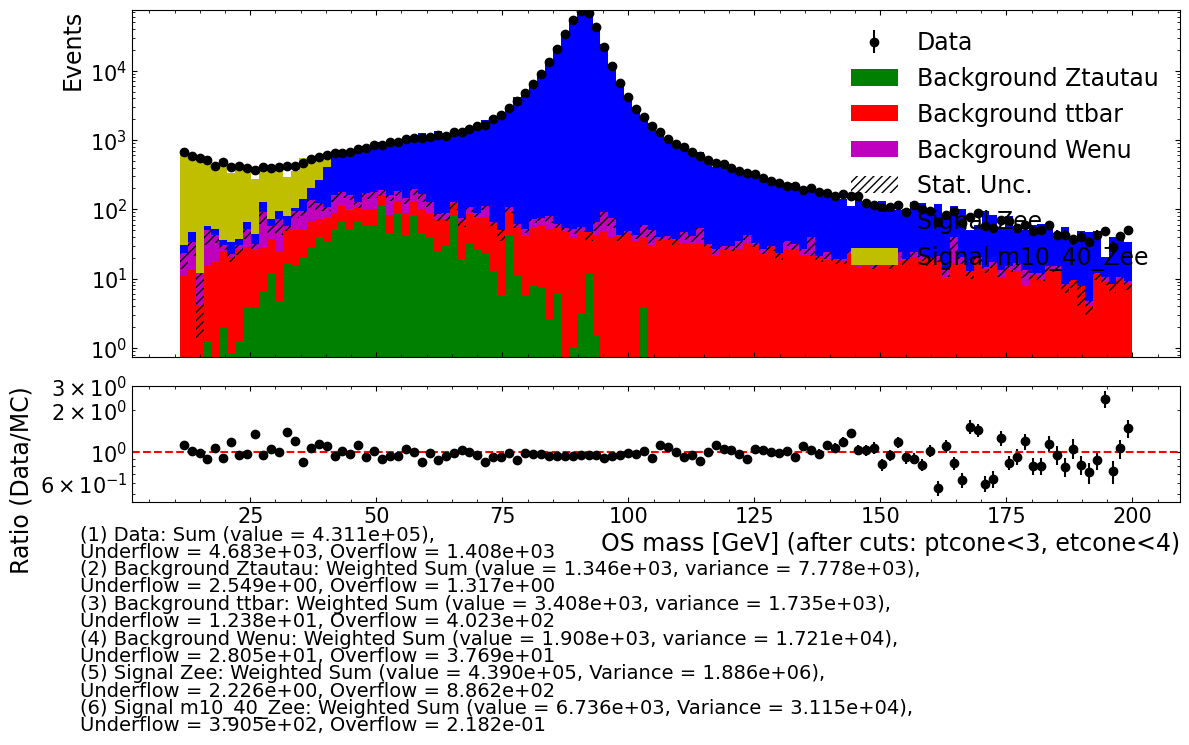

(<Figure size 1200x800 with 2 Axes>,
 [Hist(Regular(120, 11, 200, name='Data'), storage=Double()) # Sum: 431067.0 (437158.0 with flow),
  Hist(Regular(120, 11, 200, name='Background Ztautau'), storage=Weight()) # Sum: WeightedSum(value=1345.6, variance=7778.02) (WeightedSum(value=1349.47, variance=7780.72) with flow),
  Hist(Regular(120, 11, 200, name='Background ttbar'), storage=Weight()) # Sum: WeightedSum(value=3407.86, variance=1735.37) (WeightedSum(value=3822.51, variance=1951.43) with flow),
  Hist(Regular(120, 11, 200, name='Background Wenu'), storage=Weight()) # Sum: WeightedSum(value=1907.95, variance=17208.9) (WeightedSum(value=1973.69, variance=17335.4) with flow),
  Hist(Regular(120, 11, 200, name='Signal Zee'), storage=Weight()) # Sum: WeightedSum(value=439031, variance=1.88571e+06) (WeightedSum(value=439919, variance=1.88948e+06) with flow),
  Hist(Regular(120, 11, 200, name='Signal m10_40_Zee'), storage=Weight()) # Sum: WeightedSum(value=6735.7, variance=31148.9) (Weight

In [49]:
#electron OS mass
plot_variable = 'mass'
xmin, xmax = 15, 200
num_bins = 120
x_label = 'mass [GeV]'

plot_dict_ee_OS_cut = {k: apply_iso_cut(v, Zee_PTcone_cut, Zee_ETcone_cut) for k, v in plot_dict_ee_OS.items()}
color_list = ['k', 'b', 'y', 'g', 'r', 'm']

plot_stacked_hist(plot_dict_ee_OS, 'mass', color_list,
                  num_bins=120, xmin=11, xmax=200,
                  x_label='OS mass [GeV] (before iso cuts)',
                  logy=True, show_text=True, residual_plot=True, save_fig=False) #without cuts

plot_stacked_hist(plot_dict_ee_OS_cut, 'mass', color_list,
                  num_bins=120, xmin=11, xmax=200,
                  x_label=f'OS mass [GeV] (after cuts: ptcone<{Zee_PTcone_cut}, etcone<{Zee_ETcone_cut})',
                  logy=True, show_text=True, residual_plot=True, save_fig=False) #with cuts


Elapsed time = 0.4s


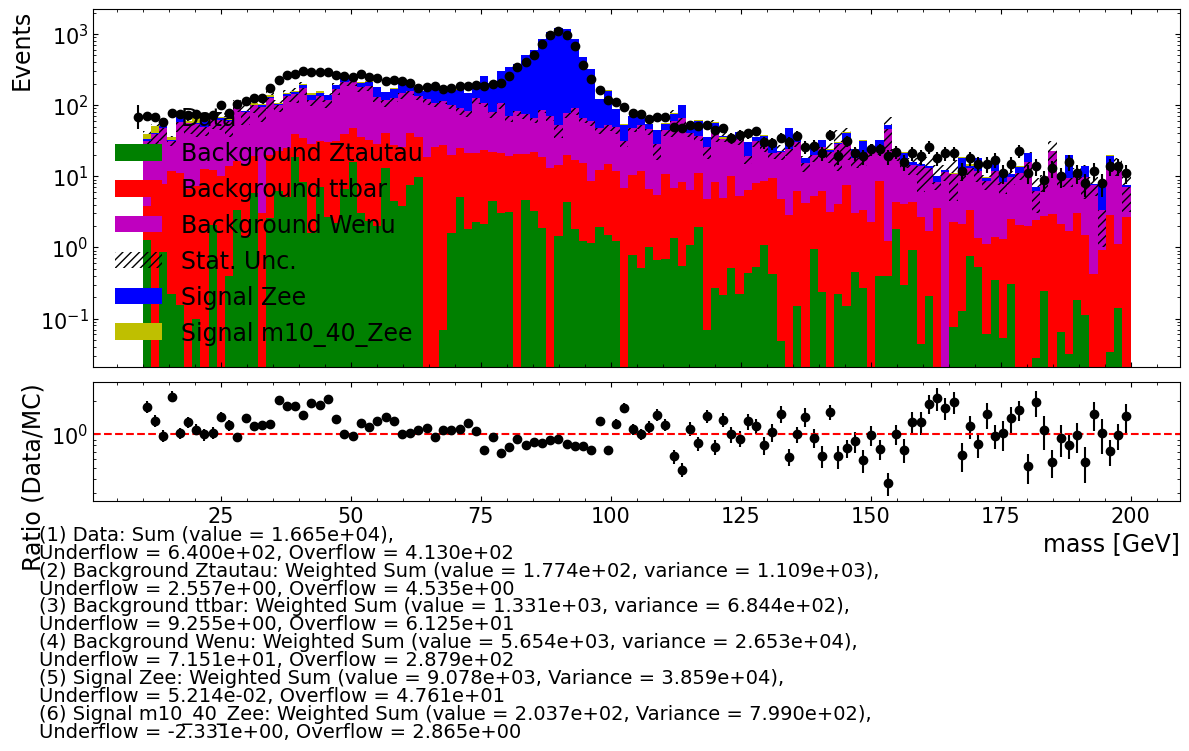

In [50]:
#electron SS mass
plot_variable = 'mass'
xmin, xmax = 10, 200
num_bins = 120
x_label = 'mass [GeV]'

fig_ee_ssm, hists_ee_ssm = plot_stacked_hist(plot_dict_ee_SS, plot_variable, color_list,
                               num_bins, xmin, xmax, x_label,
                               logy=True, show_text=True, residual_plot=True, save_fig=False)

In [51]:
#Zmumu cross section
'''
def Zmumu_sigma_fb(analysed_dict, lumi_fb, mass_low, mass_high):
    N_selected = data_count_in_mass(analysed_dict["Data"], mass_low, mass_high)

    N_background = (
        mc_yield_in_mass(analysed_dict["Background Ztautau"], mass_low, mass_high) +
        mc_yield_in_mass(analysed_dict["Background ttbar"], mass_low, mass_high) +
        mc_yield_in_mass(analysed_dict["Background Wmunu"], mass_low, mass_high)
    )

    eff = mc_yield_in_mass(analysed_dict["Signal Zmumu"], mass_low, mass_high) / produced_event_count("Zmumu", lumi_fb)

    sigma_fb = (N_selected - N_background) / (eff * lumi_fb)

    unc_stat = np.sqrt(N_selected + N_background) / (eff * lumi_fb)
    unc_luminosity = 0.017 * sigma_fb
    return sigma_fb, unc_stat, unc_luminosity
'''

'\ndef Zmumu_sigma_fb(analysed_dict, lumi_fb, mass_low, mass_high):\n    N_selected = data_count_in_mass(analysed_dict["Data"], mass_low, mass_high)\n\n    N_background = (\n        mc_yield_in_mass(analysed_dict["Background Ztautau"], mass_low, mass_high) +\n        mc_yield_in_mass(analysed_dict["Background ttbar"], mass_low, mass_high) +\n        mc_yield_in_mass(analysed_dict["Background Wmunu"], mass_low, mass_high)\n    )\n\n    eff = mc_yield_in_mass(analysed_dict["Signal Zmumu"], mass_low, mass_high) / produced_event_count("Zmumu", lumi_fb)\n\n    sigma_fb = (N_selected - N_background) / (eff * lumi_fb)\n\n    unc_stat = np.sqrt(N_selected + N_background) / (eff * lumi_fb)\n    unc_luminosity = 0.017 * sigma_fb\n    return sigma_fb, unc_stat, unc_luminosity\n'

In [52]:
def Zmumu_sigma(
    analysed_dict,         # your baseline "final" dict (already cut)
    base_uncut_dict,       # dict BEFORE iso cuts, used to make variations (e.g. plot_dict_mu_OS)
    lumi_fb,
    mass_low,
    mass_high,
    baseline_ptcone,       # e.g. 3
    baseline_etcone,       # e.g. 6
    ptcone_variations=(None, -1, +1),  # vary around baseline (None means keep baseline)
    etcone_variations=(None, -2, +2),  # vary around baseline
):
    """
    Returns:
      sigma0_fb, unc_stat_fb, unc_lumi_fb, unc_syst_fb
    Systematic = max |sigma(var) - sigma0| over the cut variations.
    """

    # --- baseline pieces ---
    N_selected = data_count_in_mass(analysed_dict["Data"], mass_low, mass_high)

    N_background = (
        mc_yield_in_mass(analysed_dict["Background Ztautau"], mass_low, mass_high) +
        mc_yield_in_mass(analysed_dict["Background ttbar"], mass_low, mass_high) +
        mc_yield_in_mass(analysed_dict["Background Wmunu"], mass_low, mass_high)
    )

    eff = (
        mc_yield_in_mass(analysed_dict["Signal Zmumu"], mass_low, mass_high)
        / produced_event_count("Zmumu", lumi_fb)
    )

    sigma0 = (N_selected - N_background) / (eff * lumi_fb)

    unc_stat = np.sqrt(N_selected + N_background) / (eff * lumi_fb)
    unc_lumi = 0.017 * sigma0

    # --- systematic via cut variations (catch-all) ---
    shifts = []

    # build varied dicts by reapplying iso cuts to the uncut dict
    for dpt in ptcone_variations:
        for det in etcone_variations:
            ptc = baseline_ptcone if dpt is None else baseline_ptcone + dpt
            etc = baseline_etcone if det is None else baseline_etcone + det

            # guard against nonsense (negative cuts)
            if (ptc is not None and ptc <= 0) or (etc is not None and etc <= 0):
                continue

            var_dict = {k: apply_iso_cut(v, ptcone_cut=ptc, etcone_cut=etc)
                        for k, v in base_uncut_dict.items()}

            # compute sigma for this variation (reusing same formula)
            N_sel_v = data_count_in_mass(var_dict["Data"], mass_low, mass_high)
            N_bkg_v = (
                mc_yield_in_mass(var_dict["Background Ztautau"], mass_low, mass_high) +
                mc_yield_in_mass(var_dict["Background ttbar"],   mass_low, mass_high) +
                mc_yield_in_mass(var_dict["Background Wmunu"],   mass_low, mass_high)
            )
            eff_v = (
                mc_yield_in_mass(var_dict["Signal Zmumu"], mass_low, mass_high)
                / produced_event_count("Zmumu", lumi_fb)
            )
            sigma_v = (N_sel_v - N_bkg_v) / (eff_v * lumi_fb)

            shifts.append(abs(sigma_v - sigma0))

    unc_syst = max(shifts) if shifts else 0.0

    return sigma0, unc_stat, unc_lumi, unc_syst

In [53]:
sigma0, unc_stat, unc_lumi, unc_syst = Zmumu_sigma(
    analysed_dict=plot_dict_cut_mu_OS_pt_et,   # your baseline final dict
    base_uncut_dict=plot_dict_mu_OS,           # before iso cuts
    lumi_fb=36.6,
    mass_low=MASS_LOW,
    mass_high=MASS_HIGH,
    baseline_ptcone=Zmumu_PTcone_cut,
    baseline_etcone=Zmumu_ETcone_cut
)

print(sigma0, unc_stat, unc_lumi, unc_syst)

The total number of produced events (sum of weights) for Monte Carlo data set Zmumu and luminosity 36.6 inverse femtobarns is 81299580
The total number of produced events (sum of weights) for Monte Carlo data set Zmumu and luminosity 36.6 inverse femtobarns is 81299580
The total number of produced events (sum of weights) for Monte Carlo data set Zmumu and luminosity 36.6 inverse femtobarns is 81299580
The total number of produced events (sum of weights) for Monte Carlo data set Zmumu and luminosity 36.6 inverse femtobarns is 81299580
The total number of produced events (sum of weights) for Monte Carlo data set Zmumu and luminosity 36.6 inverse femtobarns is 81299580
The total number of produced events (sum of weights) for Monte Carlo data set Zmumu and luminosity 36.6 inverse femtobarns is 81299580
The total number of produced events (sum of weights) for Monte Carlo data set Zmumu and luminosity 36.6 inverse femtobarns is 81299580
The total number of produced events (sum of weights) fo

In [54]:
def Zee_sigma(
    analysed_dict,         # baseline final dict (already cut)
    base_uncut_dict,       # dict BEFORE iso cuts (e.g. plot_dict_e_OS)
    lumi_fb,
    mass_low,
    mass_high,
    baseline_ptcone,       # your baseline ptcone cut value
    baseline_etcone,       # your baseline etcone cut value
    ptcone_variations=(None, -1, +1),
    etcone_variations=(None, -2, +2),
):
    """
    Returns:
      sigma0_fb, unc_stat_fb, unc_lumi_fb, unc_syst_fb
    Systematic = max |sigma(var) - sigma0| over the cut variations.
    """

    # ---------- baseline ----------
    N_selected = data_count_in_mass(analysed_dict["Data"], mass_low, mass_high)

    N_background = (
        mc_yield_in_mass(analysed_dict["Background Ztautau"], mass_low, mass_high) +
        mc_yield_in_mass(analysed_dict["Background ttbar"],   mass_low, mass_high) +
        mc_yield_in_mass(analysed_dict["Background Wenu"],    mass_low, mass_high)
    )

    eff = (
        mc_yield_in_mass(analysed_dict["Signal Zee"], mass_low, mass_high)
        / produced_event_count("Zee", lumi_fb)
    )

    sigma0 = (N_selected - N_background) / (eff * lumi_fb)

    unc_stat = np.sqrt(N_selected + N_background) / (eff * lumi_fb)
    unc_lumi = 0.017 * sigma0

    # ---------- systematic via cut variations ----------
    shifts = []

    for dpt in ptcone_variations:
        for det in etcone_variations:
            ptc = baseline_ptcone if dpt is None else baseline_ptcone + dpt
            etc = baseline_etcone if det is None else baseline_etcone + det

            # skip nonsense cuts
            if (ptc is not None and ptc <= 0) or (etc is not None and etc <= 0):
                continue

            # rebuild a varied analysed dict by reapplying iso cuts
            var_dict = {k: apply_iso_cut(v, ptcone_cut=ptc, etcone_cut=etc)
                        for k, v in base_uncut_dict.items()}

            N_sel_v = data_count_in_mass(var_dict["Data"], mass_low, mass_high)
            N_bkg_v = (
                mc_yield_in_mass(var_dict["Background Ztautau"], mass_low, mass_high) +
                mc_yield_in_mass(var_dict["Background ttbar"],   mass_low, mass_high) +
                mc_yield_in_mass(var_dict["Background Wenu"],    mass_low, mass_high)
            )
            eff_v = (
                mc_yield_in_mass(var_dict["Signal Zee"], mass_low, mass_high)
                / produced_event_count("Zee", lumi_fb)
            )
            sigma_v = (N_sel_v - N_bkg_v) / (eff_v * lumi_fb)

            shifts.append(abs(sigma_v - sigma0))

    unc_syst = max(shifts) if shifts else 0.0

    return sigma0, unc_stat, unc_lumi, unc_syst

In [55]:
sigma0, unc_stat, unc_lumi, unc_syst = Zee_sigma(
    analysed_dict=plot_dict_cut_ee_OS_pt_et,  # your baseline final Zee dict
    base_uncut_dict=plot_dict_ee_OS,          # before iso cuts
    lumi_fb=36.6,
    mass_low=66,
    mass_high=116,
    baseline_ptcone=Zee_PTcone_cut,
    baseline_etcone=Zee_ETcone_cut
)

print(sigma0, unc_stat, unc_lumi, unc_syst)

The total number of produced events (sum of weights) for Monte Carlo data set Zee and luminosity 36.6 inverse femtobarns is 81299580
The total number of produced events (sum of weights) for Monte Carlo data set Zee and luminosity 36.6 inverse femtobarns is 81299580
The total number of produced events (sum of weights) for Monte Carlo data set Zee and luminosity 36.6 inverse femtobarns is 81299580
The total number of produced events (sum of weights) for Monte Carlo data set Zee and luminosity 36.6 inverse femtobarns is 81299580
The total number of produced events (sum of weights) for Monte Carlo data set Zee and luminosity 36.6 inverse femtobarns is 81299580
The total number of produced events (sum of weights) for Monte Carlo data set Zee and luminosity 36.6 inverse femtobarns is 81299580
The total number of produced events (sum of weights) for Monte Carlo data set Zee and luminosity 36.6 inverse femtobarns is 81299580
The total number of produced events (sum of weights) for Monte Carlo 

## Hist
`Hist` objects can be used to inspect the histogram contents, including the bin values, variances (for MC datasets), and underflow/overflow bins.  
The second value returned by `plot_stacked_hist` is a list of `Hist` objects. They are in the order 'Data', 'Background', 'Signal'.

Here are some useful methods:
- `.sum()` - total sum of all bin contents
- `.view()` - bin values (Data)
- `.view().value` - bin values (MC)
- `.view().variance` - bin variances (MC)
- `.view(flow=True)[0]` - underflow bin value
- `.view(flow=True)[-1]` - overflow bin value
- `.axes[0].centers` - bin centres
  
For example, try uncommenting the lines below to explore the contents of a `Hist` object:

In [56]:
# In our example, the first Hist object (index 0) is Data, and the second (index 1) is MC
hists                 # View the full histogram object
#hists[2]                 # View the full histogram object
# hists[0].sum()         # Total sum of all bin contents
# hists[0].view()        # Access the bin values (excluding flow bins)

[Hist(Regular(120, -3, 6, name='Data'), storage=Double()) # Sum: 513334.0 (513337.0 with flow),
 Hist(Regular(120, -3, 6, name='Background Ztautau'), storage=Weight()) # Sum: WeightedSum(value=1001.01, variance=6869.01),
 Hist(Regular(120, -3, 6, name='Background ttbar'), storage=Weight()) # Sum: WeightedSum(value=3511.02, variance=1708.77),
 Hist(Regular(120, -3, 6, name='Background Wmunu'), storage=Weight()) # Sum: WeightedSum(value=290.024, variance=1202.95),
 Hist(Regular(120, -3, 6, name='Signal Zmumu'), storage=Weight()) # Sum: WeightedSum(value=497480, variance=2.14789e+06) (WeightedSum(value=497483, variance=2.14789e+06) with flow),
 Hist(Regular(120, -3, 6, name='Signal m10_40_Zmumu'), storage=Weight()) # Sum: WeightedSum(value=8078.41, variance=37547.3) (WeightedSum(value=8078.42, variance=37547.3) with flow)]

For more information about `Hist`, see https://hist.readthedocs.io/en/latest/.

For more information about `matplotlib.pyplot`, see https://matplotlib.org/stable/api/pyplot_summary.html.

The function `savefig` saves a copy of the figure you have just produced.
    Note an alternative is to set the input argument `save_fig` to `True` in the function `plot_stacked_hist`.

In [57]:
fig.savefig(plot_variable+'.png')

## Additional Plotting Functions
If you want to plot additional variables to identify where the selection cut could be tightened, the `plot_histograms` function is for you. This function returns:
- A **list** of `Figure` objects (one per variable plotted)
- A corresponding **list of lists** of `Hist` objects

There are some arguments worth pointing out:
- `xmin_xmax_list` : a tuple of two numbers applied to all plots, or a list of tuples (one per variable)
- `num_bins_list` : an int applied to all plots, or a list of int (one per variable)

The same applies to these optional arguments: `y_label_list`, `ylim_list`, `title_list`, and `residual_ylim_list`. These can be specified as a single value applied to all plots or as a list matching the number of variables.

Elapsed time = 0.4s


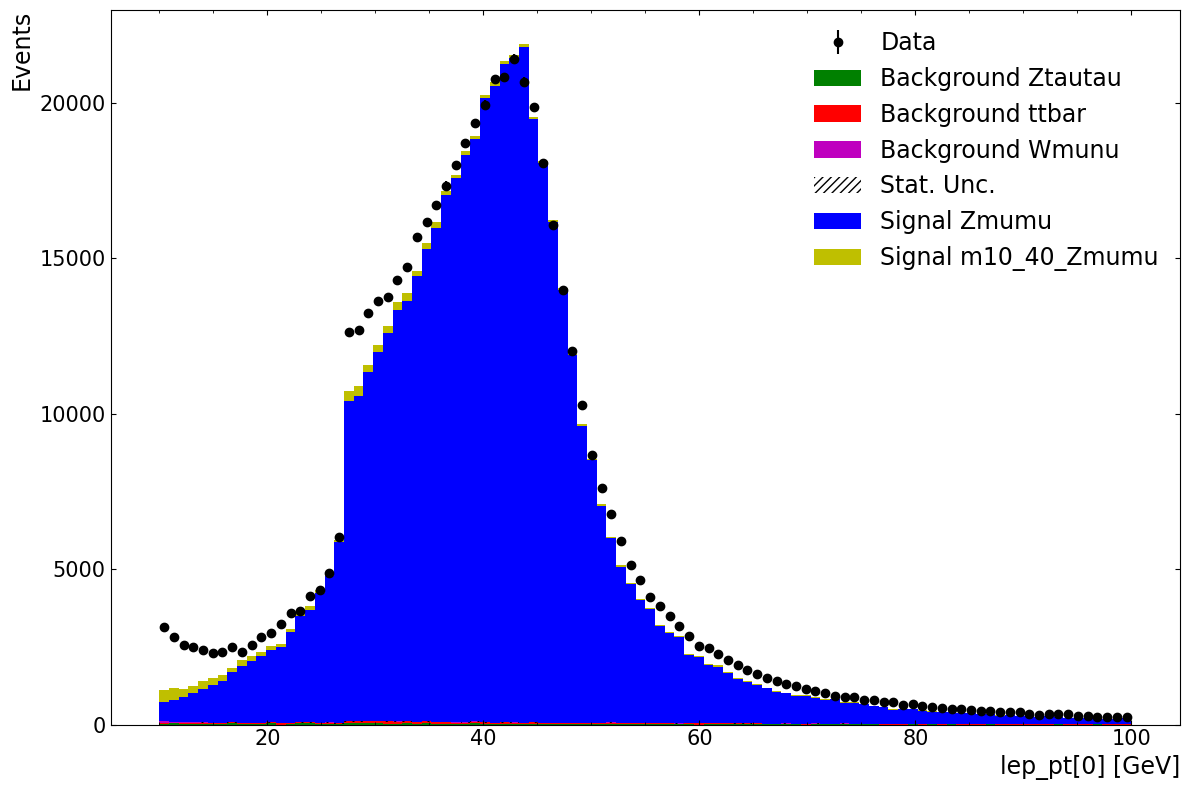

Elapsed time = 1.8s


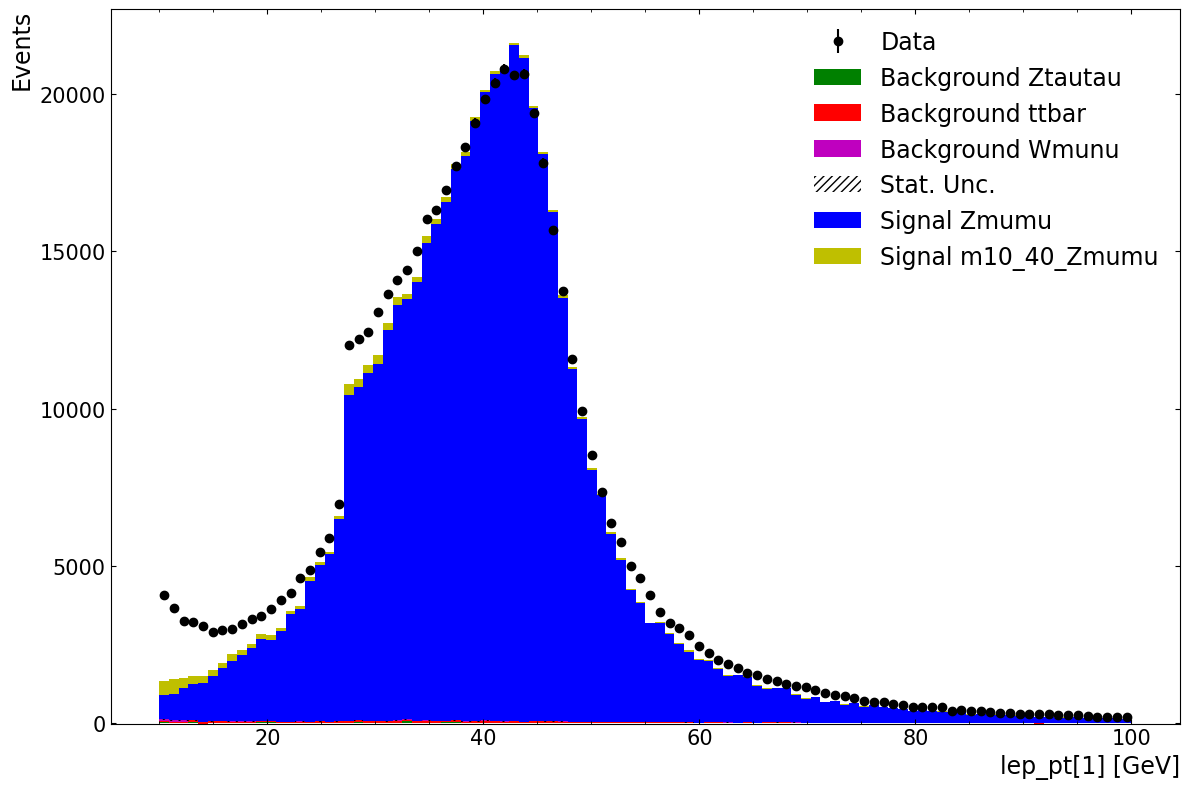

Elapsed time = 3.2s


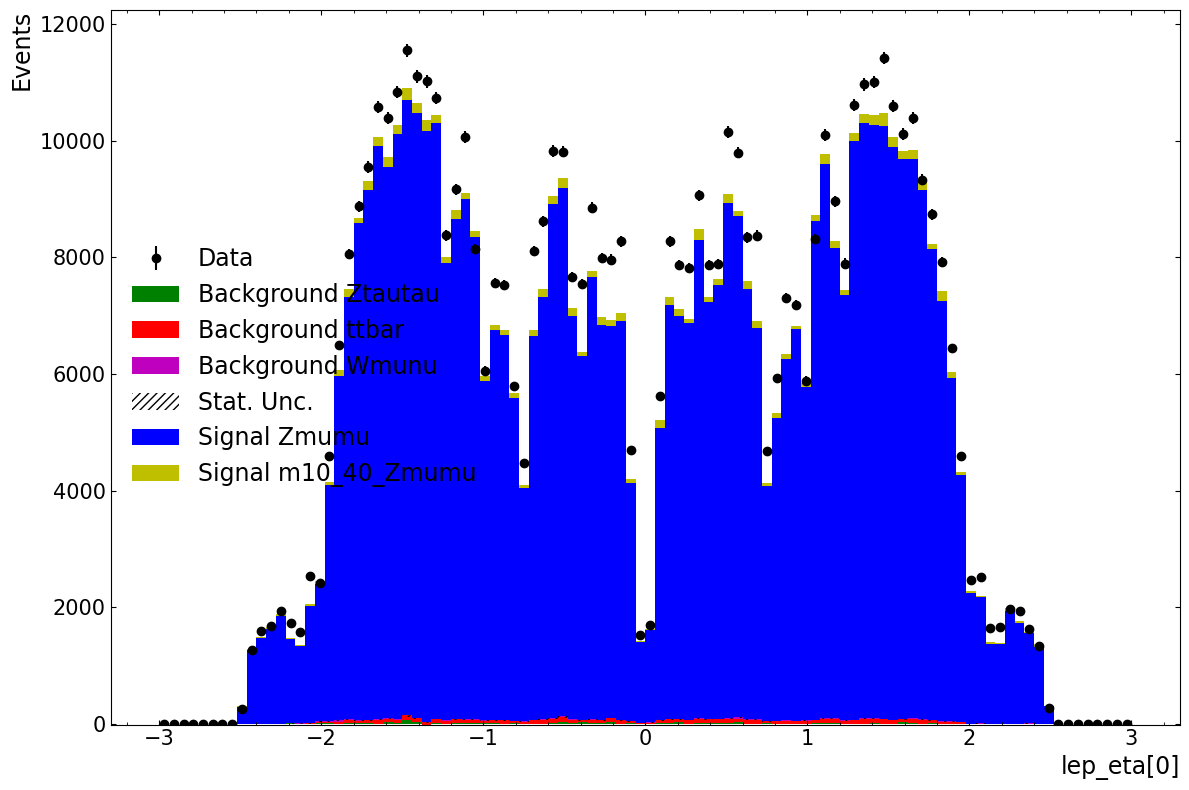

Elapsed time = 4.2s


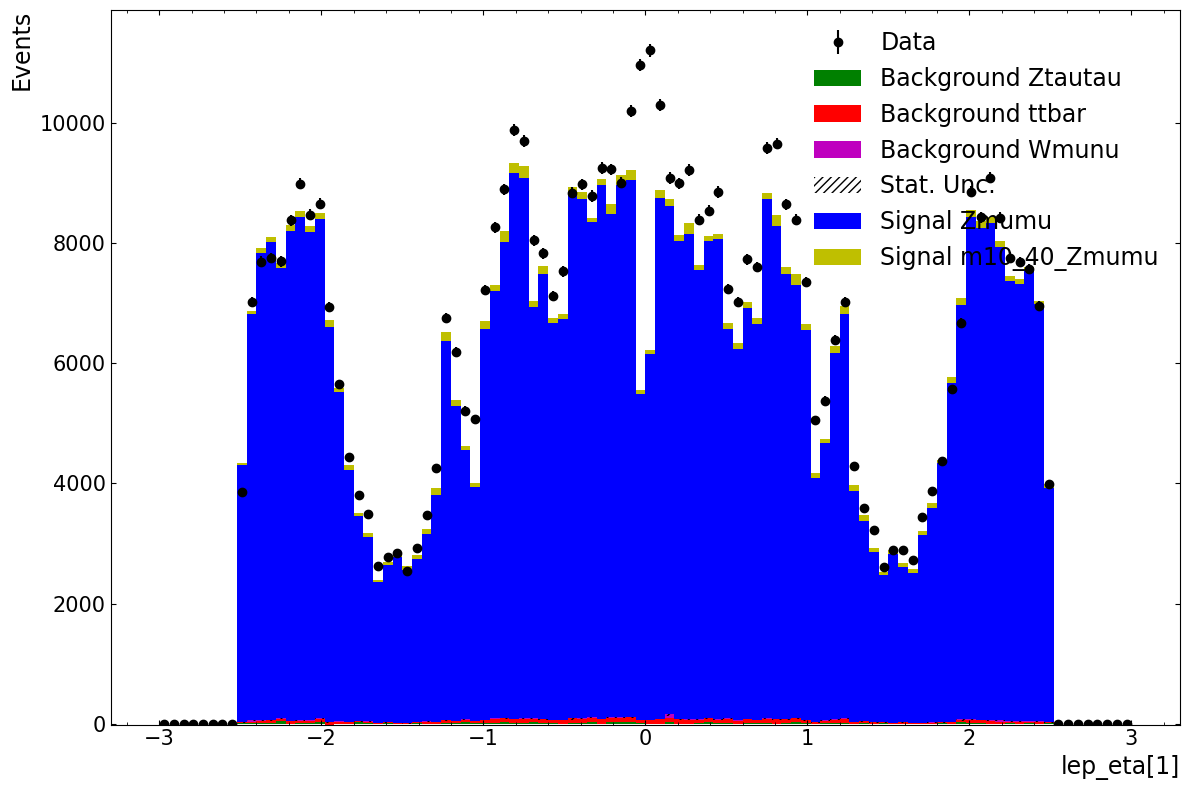

([<Figure size 1200x800 with 1 Axes>,
  <Figure size 1200x800 with 1 Axes>,
  <Figure size 1200x800 with 1 Axes>,
  <Figure size 1200x800 with 1 Axes>],
 [[Hist(Regular(100, 10, 100, name='Data'), storage=Double()) # Sum: 566543.0 (573453.0 with flow),
   Hist(Regular(100, 10, 100, name='Background Ztautau'), storage=Weight()) # Sum: WeightedSum(value=1069.6, variance=7312.92) (WeightedSum(value=1079.41, variance=7323.01) with flow),
   Hist(Regular(100, 10, 100, name='Background ttbar'), storage=Weight()) # Sum: WeightedSum(value=3379.59, variance=1645.39) (WeightedSum(value=3782.38, variance=1839.87) with flow),
   Hist(Regular(100, 10, 100, name='Background Wmunu'), storage=Weight()) # Sum: WeightedSum(value=595.072, variance=2944.39) (WeightedSum(value=609.436, variance=2955.24) with flow),
   Hist(Regular(100, 10, 100, name='Signal Zmumu'), storage=Weight()) # Sum: WeightedSum(value=515514, variance=2.2432e+06) (WeightedSum(value=520096, variance=2.2464e+06) with flow),
   Hist(Re

In [58]:
# Plot many variables at once 
plot_dict = {
    'Data' : pt_data['2to4lep_0_02'],
    'Signal Zmumu' : pt_data['Zmumu_0_02'], 
    'Signal m10_40_Zmumu' : pt_data['m10_40_Zmumu_0_02'], 
    'Background Ztautau': pt_data['Ztautau_0_02'],
    'Background ttbar' : pt_data['ttbar_0_02'], 
    'Background Wmunu' : pt_data['Wmunu_0_02'],
}

# Define plot appearance
#color_list = ['k'] # Black (data)
color_list = ['k', 'b', 'y', 'g', 'r', 'm'] # Black (data), blue (signal), yellow (signal), green (Ztautau), red (ttbar), magenta (Wmunu')


plot_variables = ['lep_pt[0]', 'lep_pt[1]', 'lep_eta[0]', 'lep_eta[1]']
xmin_xmax_list = [(10, 100), (10, 100), (-3, 3), (-3, 3)] # Bin range for each variable
num_bins_list = 100
x_label_list = ['lep_pt[0] [GeV]', 'lep_pt[1] [GeV]', 'lep_eta[0]', 'lep_eta[1]']

plot_histograms(
    plot_dict,
    plot_variables,
    color_list,
    xmin_xmax_list, # If you provide a tuple of 2 numbers, that will be applied to all plots
    num_bins_list,
    x_label_list,
    # Optional arguments start from here
    # y_label_list=None, # Str or list of str for y-axis label
    # ylim_list=None, # Tuple of 2 numbers or list of tuples for y axis limit
    logy=False, # Whether to set the y axis as log scale
    # title_list=None, # Str or list of str for title
    # marker='o', # Marker type
    # title_fontsize=17, # Fontsize for title
    # label_fontsize=17, # Fontsize for x and y axes
    # legend_fontsize=17, # Fontsize for legend
    # tick_labelsize=15, # Fontsize for x and y axes ticks
    # text_fontsize=14, # Fontsize for text that shows histogram info
    # fig_size=(12, 8), # Figure size
    # show_text=False, # Whether to show the text that displays histogram info
    # show_back_unc=True, # Whether to show the background uncertainty
    save_fig=False, # Whether to save figure
    # fig_name=None, # Filename of the image. If not provided, save figure using the plot_variable and the keys of data_dict
    residual_plot=False # Whether to show residual plot under the main plot
    # residual_ylim_list=None # Tuple of 2 numbers or list of tuples for residual plot y-axis limit
)         

The `plot_errorbars` function is designed for situations where you want to:
- Plot the same variable for different particles in the same event on a single figure, or
- Compare histograms under different selection cuts.

The first argument to `plot_errorbars` must be a dictionary. Each value in this dictionary should also be a dictionary containing the following keys:
- `'color'`: Color to be used for plotting
- `'array'`: The data array to be histogrammed
- `'weight'`: Weights associated with each data point

This function returns:
- A `Figure` object (for saving), and
- A list of `Hist` objects representing the histograms for each key

Below are some examples demonstrating how to use the `plot_errorbars` function.

Elapsed time = 0.1s


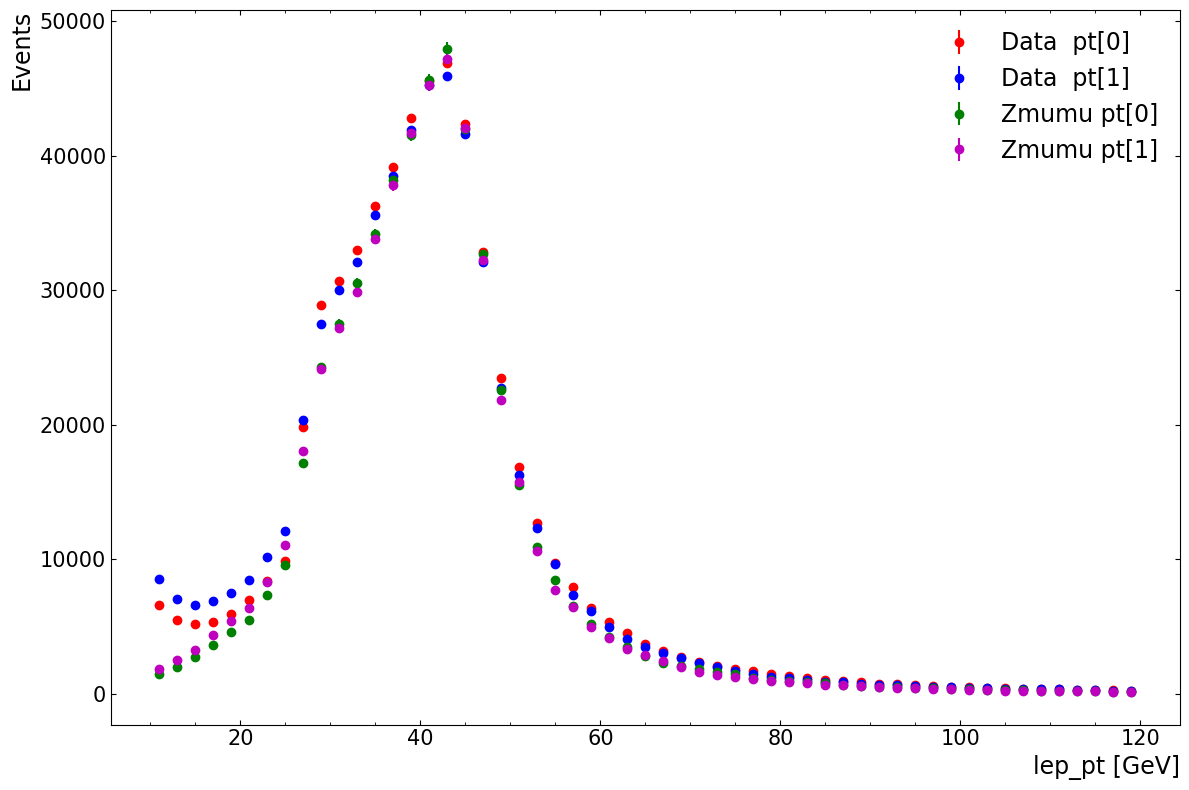

(<Figure size 1200x800 with 1 Axes>,
 [Hist(Regular(55, 10, 120, name='Data  pt[0]'), storage=Double()) # Sum: 569914.0 (573453.0 with flow),
  Hist(Regular(55, 10, 120, name='Data  pt[1]'), storage=Double()) # Sum: 570131.0 (573453.0 with flow),
  Hist(Regular(55, 10, 120, name='Zmumu pt[0]'), storage=Weight()) # Sum: WeightedSum(value=517771, variance=2.24469e+06) (WeightedSum(value=520096, variance=2.2464e+06) with flow),
  Hist(Regular(55, 10, 120, name='Zmumu pt[1]'), storage=Weight()) # Sum: WeightedSum(value=517991, variance=2.24475e+06) (WeightedSum(value=520096, variance=2.2464e+06) with flow)])

In [59]:
# Compare pt of the two leptons
data_dict = {
    'Data  pt[0]' : {'color' : 'r',
                          'array' : pt_data['2to4lep_0_02']['lep_pt'][:, 0],
                          'weight' : None},
    'Data  pt[1]' : {'color' : 'b',
                          'array' : pt_data['2to4lep_0_02']['lep_pt'][:, 1],
                          'weight' : None},
    'Zmumu pt[0]' : {'color' : 'g',
                         'array' : pt_data['Zmumu_0_02']['lep_pt'][:, 0],
                         'weight' : pt_data['Zmumu_0_02']['totalWeight']},
    'Zmumu pt[1]' : {'color' : 'm',
                         'array' : pt_data['Zmumu_0_02']['lep_pt'][:, 1],
                         'weight' : pt_data['Zmumu_0_02']['totalWeight']},
}
xmin, xmax = 10, 120
num_bins = 55
x_label = 'lep_pt [GeV]'

plot_errorbars(data_dict,
               xmin,
               xmax,
               num_bins,
               x_label,
               # Optional arguments
               # y_label='Events',
               # logy=False,
               # title='',
               # marker='o',
               # title_fontsize=17,
               # label_fontsize=17,
               # legend_fontsize=17,
               # tick_labelsize=15,
               # text_fontsize=14,
               # show_text=False,
               # fig_size=(12, 8)
)

In [60]:
# Create a second copy of the data in memory, having applied a different set of event selection cuts (from those applied above in function "pt_cut()"

def pt20_cut(data):
    # Cut on lepton number, type and pt
    data = data[data['lep_n'] == 2] 
    data = data[data['lep_type'][:, 0] + data['lep_type'][:, 1] == 26]
    data = data[(data['lep_pt'][:, 0] > 20) & (data['lep_pt'][:, 1] > 20)]

    # Require that a single muon trigger fired 
    data = data[(data['trigM'])] 

    four_momentum = vector.zip({
        'pt': data['lep_pt'],
        'eta' : data['lep_eta'],
        'phi' : data['lep_phi'],
        'E' : data['lep_e']
    })
    # Add the 4-momentum of the two leptons in each event and get the 
    # invariant mass using .M
    data['mass'] = (four_momentum[:, 0] + four_momentum[:, 1]).M
    
    return data

pt20_data = analysis_parquet(read_variables, string_code_list, fraction=fraction, cut_function=pt20_cut)
pt20_data

Input string_code_list found. Data samples will be accessed by the string code(s).


Elapsed time = 9.3s


{'2to4lep_0_02': <Array [{lep_n: 2, lep_pt: [...], ...}, ...] type='508455 * {lep_n: int32, ...'>,
 'Zmumu_0_02': <Array [{lep_n: 2, lep_pt: [...], ...}, ...] type='765189 * {lep_n: int32, ...'>,
 'm10_40_Zmumu_0_02': <Array [{lep_n: 2, lep_pt: [...], ...}, ...] type='14655 * {lep_n: int32, l...'>,
 'Ztautau_0_02': <Array [{lep_n: 2, lep_pt: [...], ...}, ...] type='1665 * {lep_n: int32, le...'>,
 'ttbar_0_02': <Array [{lep_n: 2, lep_pt: [...], ...}, ...] type='6697 * {lep_n: int32, le...'>,
 'Wmunu_0_02': <Array [{lep_n: 2, lep_pt: [...], ...}, ...] type='497 * {lep_n: int32, lep...'>}

Elapsed time = 0.1s


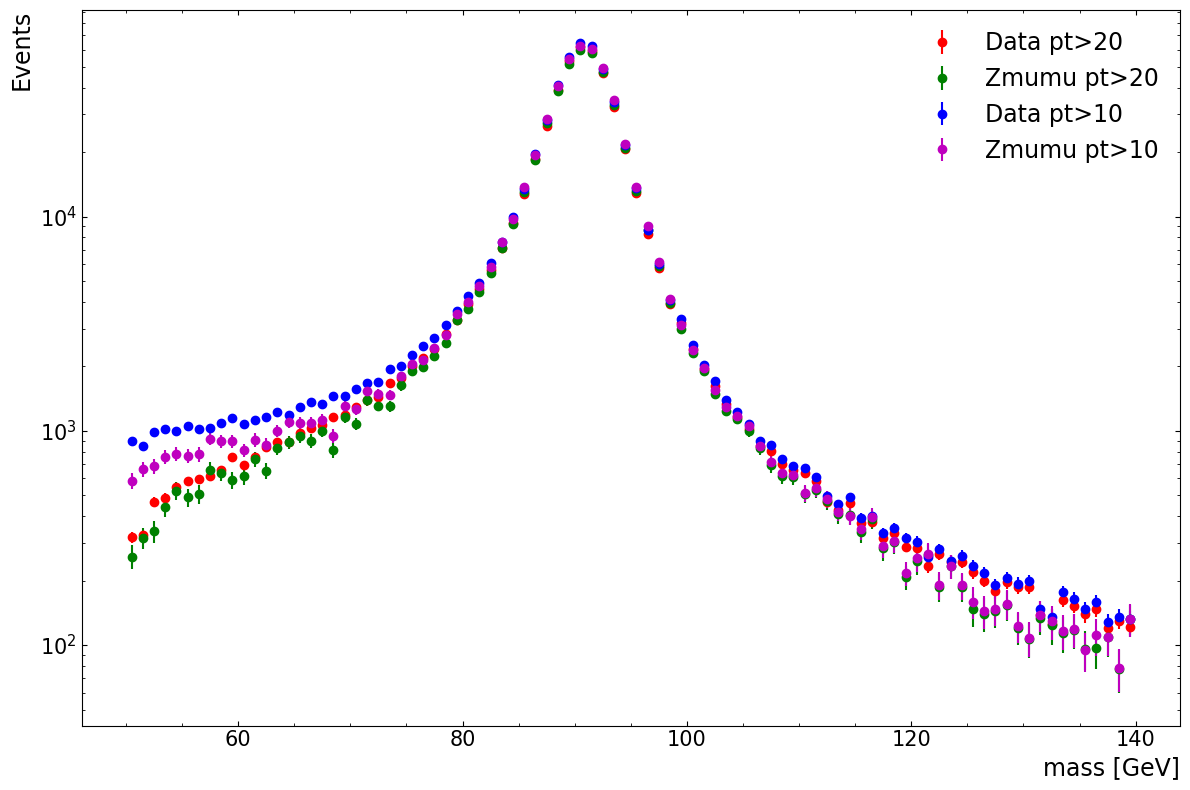

(<Figure size 1200x800 with 1 Axes>,
 [Hist(Regular(90, 50, 140, name='Data pt>20'), storage=Double()) # Sum: 491050.0 (508455.0 with flow),
  Hist(Regular(90, 50, 140, name='Zmumu pt>20'), storage=Weight()) # Sum: WeightedSum(value=483393, variance=2.11795e+06) (WeightedSum(value=488357, variance=2.13595e+06) with flow),
  Hist(Regular(90, 50, 140, name='Data pt>10'), storage=Double()) # Sum: 525590.0 (573453.0 with flow),
  Hist(Regular(90, 50, 140, name='Zmumu pt>10'), storage=Weight()) # Sum: WeightedSum(value=510983, variance=2.20994e+06) (WeightedSum(value=520096, variance=2.2464e+06) with flow)])

In [61]:
# Compare histograms under different cuts
data_dict = {
    'Data pt>20' : {'color' : 'r',
                    'array' : pt20_data['2to4lep_0_02']['mass'],
                    'weight' : None},
    'Zmumu pt>20' : {'color' : 'g',
                   'array' : pt20_data['Zmumu_0_02']['mass'],
                   'weight' : pt20_data['Zmumu_0_02']['totalWeight']},
    'Data pt>10' : {'color' : 'b',
                    'array' : pt_data['2to4lep_0_02']['mass'],
                    'weight' : None},
    'Zmumu pt>10' : {'color' : 'm',
                   'array' : pt_data['Zmumu_0_02']['mass'],
                   'weight' : pt_data['Zmumu_0_02']['totalWeight']},
}

xmin, xmax = 50, 140 # Define histogram bin range and x-axis limits 
num_bins = 90 # Number of histogram bins
x_label = 'mass [GeV]'

plot_errorbars(data_dict, xmin, xmax, num_bins, x_label, logy=True)

## 2D Histogram
If you want to plot a 2D histogram, you can use the `histogram_2d` function as shown in the code cell below.

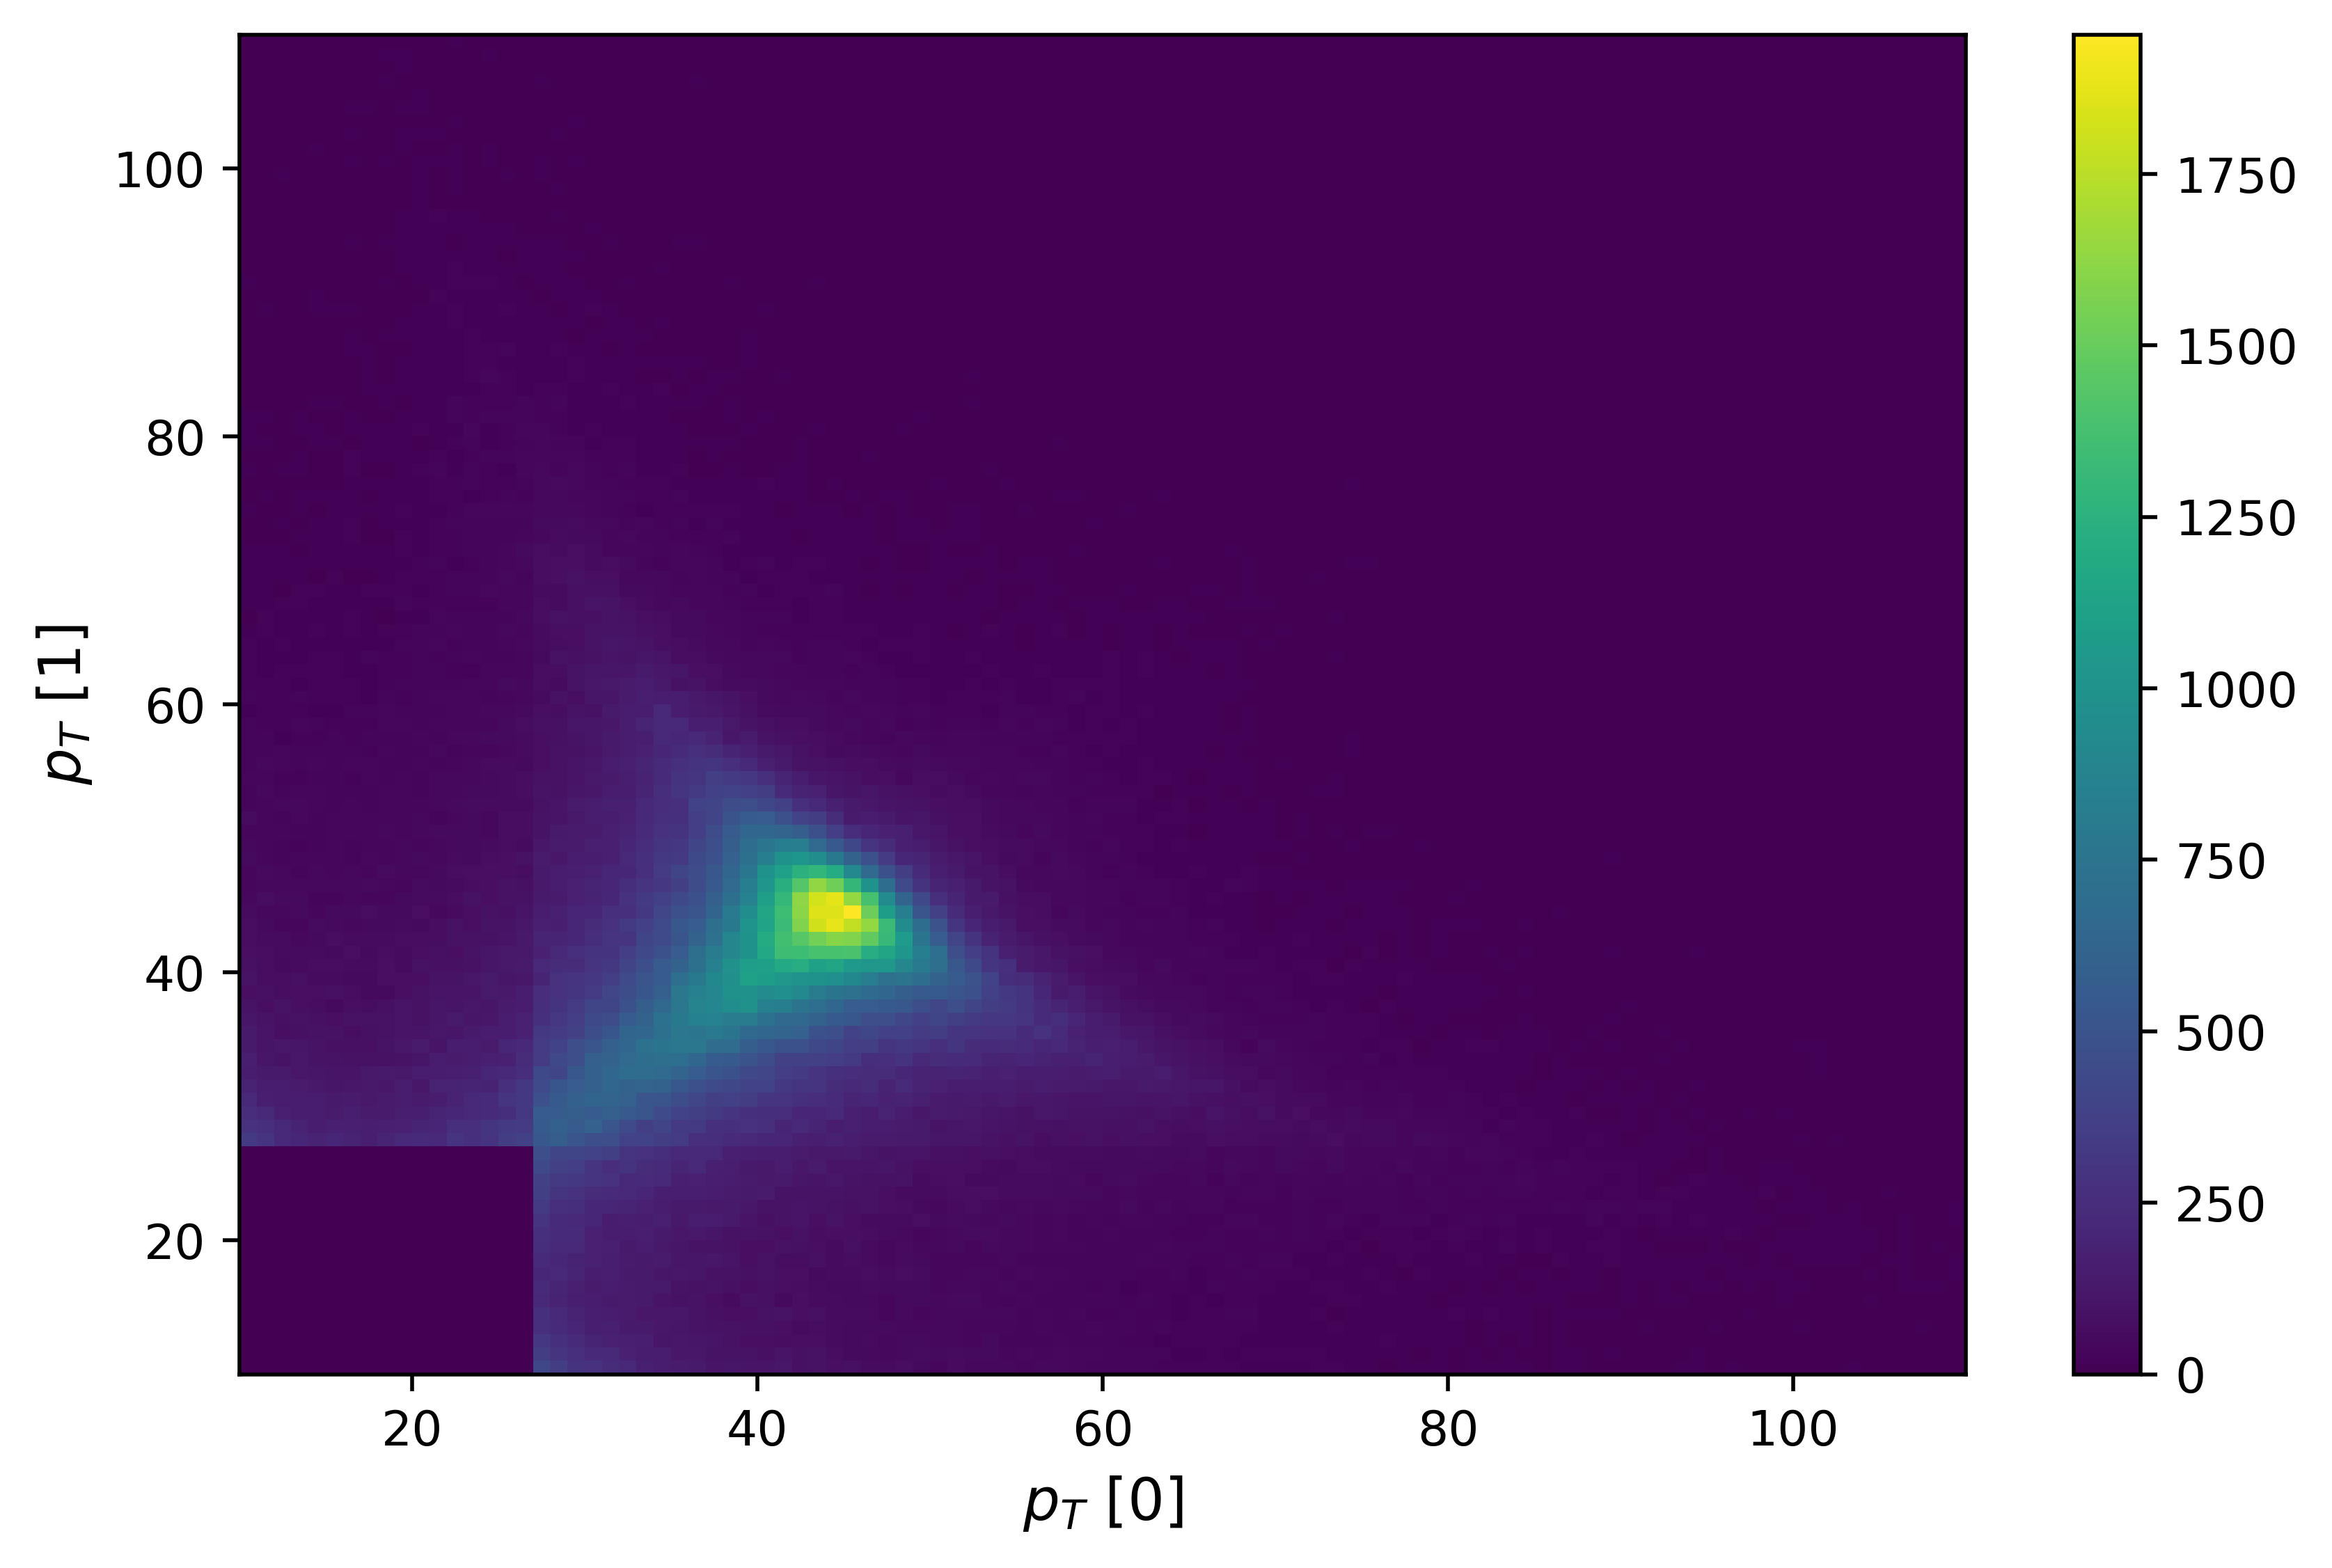

In [62]:

data_pt0 = pt_data['2to4lep_0_02']['lep_pt'][:, 0]
data_pt1 = pt_data['2to4lep_0_02']['lep_pt'][:, 1]
data_2d = (data_pt0, data_pt1) # Plot lep_pt[0] on x-axis, lep_pt[1] on y-axis
num_bins_2d = (100, 100) # Number of bins along x and y-axis 
min_max_2d = ((10, 110), (10, 110)) # The bin range in x and y
label_2d = ('$p_T$ [0]', '$p_T$ [1]') # The labels for x and y-axis


# Plot the 2D histogram
fig, h = histogram_2d(data_2d, num_bins_2d,
                      min_max_2d, label_2d,
                      # Optional arguments
                      # label_fontsize=12, tick_labelsize=10,
                      # title_fontsize=13, title='',
                      # colorbar_label='Events'
                    )
# Uncomment to save the image
#fig.savefig('test.png', dpi=500)

## Write the Data to Disk
When working with larger datasets, e.g. using a higher `fraction` in `analysis_parquet`, it is often more efficient to write the data to disk rather than keeping it all in memory. 

To do this, set the optional argument `write_parquet=True`. This will instruct the `analysis_parquet` function to save the output as Parquet files. If you write data to disk, it is recommended to set `return_output=False` to avoid loading large amounts of data into memory.  

In addition, you can customise the output location using the `output_directory` argument. If not provided, the files will be saved in an `output` folder with a unique name created from the current date and time.  

**Note**: The provided output directory must be unique and cannot be reused. Attempting to write to an existing directory will raise a `FileExistsError` to prevent accidental overwriting of data.   

For example, the following makes a tighter preselection of di-lepton events.


In [63]:

# Write your own di-lepton preselection to parquet files

string_code_list = ['2to4lep', 'Zmumu', 'm10_40_Zmumu','Zee', 'm10_40_Zee', 'Ztautau', 'ttbar', 'Wmunu', 'Wenu', 'Wtaunu'] # List of dataset codes to load
#string_code_list = ['2to4lep', 'Zee', 'm10_40_Zee', 'Ztautau', 'ttbar', 'Wenu', 'Wtaunu'] # List of dataset codes to load

# Specify the variables to be read in.
# These variables will also be written out, in addition to any defined in the function 'preselection_cut' below
read_variables = ['lep_n', 'lep_pt', 'lep_eta', 'lep_phi', 'lep_e', 'lep_ptvarcone30', 'lep_topoetcone20', 'lep_type', 'lep_charge', 'trigE', 'trigM', 'lep_isTrigMatched',
                   'lep_isLooseID', 'lep_isMediumID', 'lep_isLooseIso', 'lep_isTightIso']

# Alternatively, you may wish to use the pre-defined function `validate_read_variables` to find the names of all available variables
#read_variables = get_valid_variables('2to4lep') # Save all available variables

# Keep a new name so you do not overwrite your old mu-only parquet by accident
base_output_dir = '../../output-parquet/dilepton_ALLFLAVOUR_BASE_MediumID_v2'


def make_preselection_cut(sign="OS"):
    want_os = (sign.upper() == "OS")
    want_ss = (sign.upper() == "SS")

    def preselection_cut(data):
        # exactly 2 leptons
        data = data[data['lep_n'] == 2]

        # keep events that fired either electron or muon trigger
        # (important: do NOT force mu trigger here, otherwise μe / ee cannot be studied later)
        data = data[(data['trigM']) | (data['trigE'])]

        # both leptons pass Medium ID
        data = data[(data['lep_isMediumID'][:, 0]) & (data['lep_isMediumID'][:, 1])]

        # pT > 15 GeV for both leptons
        LoosePt = 15
        data = data[(data['lep_pt'][:, 0] > LoosePt) & (data['lep_pt'][:, 1] > LoosePt)]

        # soft_pt
        data['soft_pt'] = (
            ((data['lep_pt'][:, 0] > data['lep_pt'][:, 1]) * data['lep_pt'][:, 1]) +
            ((data['lep_pt'][:, 0] < data['lep_pt'][:, 1]) * data['lep_pt'][:, 0])
        )

        # invariant mass
        four_momentum = vector.zip({
            'pt':  data['lep_pt'],
            'eta': data['lep_eta'],
            'phi': data['lep_phi'],
            'E':   data['lep_e']
        })
        data['mass'] = (four_momentum[:, 0] + four_momentum[:, 1]).M

        # mass window
        data = data[(data['mass'] > 15) & (data['mass'] < 1000)]

        # OS / SS split only
        data['charge_product'] = data['lep_charge'][:, 0] * data['lep_charge'][:, 1]
        if want_os:
            data = data[data['charge_product'] < 0]
        elif want_ss:
            data = data[data['charge_product'] > 0]

        return data

    return preselection_cut


In [64]:
# Cell of creating parquet file
'''for sign in ["OS", "SS"]:
    outdir = f"{base_output_dir}_{sign}"
    analysis_parquet(
        read_variables,
        string_code_list,
        fraction=1,
        cut_function=make_preselection_cut(sign),
        write_parquet=True,
        output_directory=outdir,
        return_output=False
    )
    print(f"[OK] Wrote {sign} parquet to: {outdir}")'''

'for sign in ["OS", "SS"]:\n    outdir = f"{base_output_dir}_{sign}"\n    analysis_parquet(\n        read_variables,\n        string_code_list,\n        fraction=1,\n        cut_function=make_preselection_cut(sign),\n        write_parquet=True,\n        output_directory=outdir,\n        return_output=False\n    )\n    print(f"[OK] Wrote {sign} parquet to: {outdir}")'

In [65]:
"""# ============================================
# Write Bremstrallung
# ============================================
for sign in ["OS", "SS"]:
    outdir = f"{base_output_dir_mc_brem}_{sign}"
    analysis_parquet(
        read_variables,
        string_code_list,
        fraction=1,
        cut_function=make_preselection_cut_mc_brem(sign),
        write_parquet=True,
        output_directory=outdir,
        return_output=False
    )
    print(f"[OK] Wrote FULL {sign} parquet to: {outdir}")"""

'# ============================================\n# Write Bremstrallung\n# ============================================\nfor sign in ["OS", "SS"]:\n    outdir = f"{base_output_dir_mc_brem}_{sign}"\n    analysis_parquet(\n        read_variables,\n        string_code_list,\n        fraction=1,\n        cut_function=make_preselection_cut_mc_brem(sign),\n        write_parquet=True,\n        output_directory=outdir,\n        return_output=False\n    )\n    print(f"[OK] Wrote FULL {sign} parquet to: {outdir}")'

In [66]:
OS_DIR = "../../output-parquet/dilepton_ALLFLAVOUR_BASE_MediumID_v2_OS"
SS_DIR = "../../output-parquet/dilepton_ALLFLAVOUR_BASE_MediumID_v2_SS"

# Keep old scan variables, but also retain flavour/trigger information
# so we can split into μμ / ee / μe after loading
scan_vars = [
    "lep_n", "lep_pt", "lep_ptvarcone30", "lep_topoetcone20",
    "lep_type", "lep_charge",
    "trigE", "trigM",
    "mass", "charge_product", "totalWeight"
]

# Read the all-flavour parquet back
plot_dict_all_OS = analysis_parquet(read_variables=scan_vars, read_directory=OS_DIR, return_output=True)
plot_dict_all_SS = analysis_parquet(read_variables=scan_vars, read_directory=SS_DIR, return_output=True)

print("ALL-FLAVOUR OS keys:", list(plot_dict_all_OS.keys())[:5], "...")
print("ALL-FLAVOUR SS keys:", list(plot_dict_all_SS.keys())[:5], "...")


Input read_directory found. Data will be read from ../../output-parquet/dilepton_ALLFLAVOUR_BASE_MediumID_v2_OS.
Elapsed time = 82.7s
Input read_directory found. Data will be read from ../../output-parquet/dilepton_ALLFLAVOUR_BASE_MediumID_v2_SS.
Elapsed time = 14.8s
ALL-FLAVOUR OS keys: ['2to4lep_1 x1', 'm10_40_Zee_1 x1', 'm10_40_Zmumu_1 x1', 'ttbar_1 x1', 'Wenu_1 x1'] ...
ALL-FLAVOUR SS keys: ['2to4lep_1 x1', 'm10_40_Zee_1 x1', 'm10_40_Zmumu_1 x1', 'ttbar_1 x1', 'Wenu_1 x1'] ...


In [67]:
# Split channels AFTER reading back, while keeping old μμ variable names alive

def channel_mask(arr, channel):
    flavour_sum = arr["lep_type"][:, 0] + arr["lep_type"][:, 1]

    if channel == "mumu":
        return (flavour_sum == 26) & (arr["trigM"])
    elif channel == "ee":
        return (flavour_sum == 22) & (arr["trigE"])
    elif channel == "mue":
        return (flavour_sum == 24) & ((arr["trigM"]) | (arr["trigE"]))
    else:
        raise ValueError("channel must be 'mumu', 'ee', or 'mue'")

def select_channel_dict(d, channel):
    out = {}
    for k, arr in d.items():
        mask = channel_mask(arr, channel)
        out[k] = arr[mask]
    return out

# raw channel dicts
plot_dict_mu_OS  = select_channel_dict(plot_dict_all_OS, "mumu")
plot_dict_mu_SS  = select_channel_dict(plot_dict_all_SS, "mumu")

plot_dict_ee_OS  = select_channel_dict(plot_dict_all_OS, "ee")
plot_dict_ee_SS  = select_channel_dict(plot_dict_all_SS, "ee")

plot_dict_mue_OS = select_channel_dict(plot_dict_all_OS, "mue")
plot_dict_mue_SS = select_channel_dict(plot_dict_all_SS, "mue")

print("μμ OS keys:", list(plot_dict_mu_OS.keys()))
print("μμ SS keys:", list(plot_dict_mu_SS.keys()))
print("μe OS keys:", list(plot_dict_mue_OS.keys()))
print("μe SS keys:", list(plot_dict_mue_SS.keys()))

μμ OS keys: ['2to4lep_1 x1', 'm10_40_Zee_1 x1', 'm10_40_Zmumu_1 x1', 'ttbar_1 x1', 'Wenu_1 x1', 'Wmunu_1 x1', 'Wtaunu_1 x1', 'Zee_1 x1', 'Zmumu_1 x1', 'Ztautau_1 x1']
μμ SS keys: ['2to4lep_1 x1', 'm10_40_Zee_1 x1', 'm10_40_Zmumu_1 x1', 'ttbar_1 x1', 'Wenu_1 x1', 'Wmunu_1 x1', 'Wtaunu_1 x1', 'Zee_1 x1', 'Zmumu_1 x1', 'Ztautau_1 x1']
μe OS keys: ['2to4lep_1 x1', 'm10_40_Zee_1 x1', 'm10_40_Zmumu_1 x1', 'ttbar_1 x1', 'Wenu_1 x1', 'Wmunu_1 x1', 'Wtaunu_1 x1', 'Zee_1 x1', 'Zmumu_1 x1', 'Ztautau_1 x1']
μe SS keys: ['2to4lep_1 x1', 'm10_40_Zee_1 x1', 'm10_40_Zmumu_1 x1', 'ttbar_1 x1', 'Wenu_1 x1', 'Wmunu_1 x1', 'Wtaunu_1 x1', 'Zee_1 x1', 'Zmumu_1 x1', 'Ztautau_1 x1']


Define the data frame below, with code of getting background values commented below

In [68]:
def pick_key(d, prefix):
    matches = [k for k in d.keys() if str(k).startswith(prefix)]
    if not matches:
        raise KeyError(f"No key starting with '{prefix}'. Available keys: {list(d.keys())}")
    return matches[0]

def build_plot_dict_mu(raw_dict):
    out = {
        "Data": raw_dict[pick_key(raw_dict, "2to4lep")],
        "Signal Zmumu": raw_dict[pick_key(raw_dict, "Zmumu")],
        "Background Ztautau": raw_dict[pick_key(raw_dict, "Ztautau")],
        "Background ttbar": raw_dict[pick_key(raw_dict, "ttbar")],
    }

    wmunu_matches = [k for k in raw_dict.keys() if str(k).startswith("Wmunu")]
    m40zmumu_matches = [k for k in raw_dict.keys() if str(k).startswith("m10_40_Zmumu_1")]

    if wmunu_matches:
        out["Background Wmunu"] = raw_dict[wmunu_matches[0]]
    if m40zmumu_matches:
        out["Signal m10_40_Zmumu"] = raw_dict[m40zmumu_matches[0]]

    return out


def build_plot_dict_ee(raw_dict):
    out = {
        "Data": raw_dict[pick_key(raw_dict, "2to4lep")],
        "Signal Zee": raw_dict[pick_key(raw_dict, "Zee")],
        "Background Ztautau": raw_dict[pick_key(raw_dict, "Ztautau")],
        "Background ttbar": raw_dict[pick_key(raw_dict, "ttbar")],
    }

    wenu_matches = [k for k in raw_dict.keys() if str(k).startswith("Wenu")]
    wtaunu_matches = [k for k in raw_dict.keys() if str(k).startswith("Wtaunu")]
    m40zee_matches = [k for k in raw_dict.keys() if str(k).startswith("m10_40_Zee")]

    if wenu_matches:
        out["Background Wenu"] = raw_dict[wenu_matches[0]]
    if wtaunu_matches:
        out["Background Wtaunu"] = raw_dict[wtaunu_matches[0]]
    if m40zee_matches:
        out["Signal m10_40_Zee"] = raw_dict[m40zee_matches[0]]

    return out

def build_plot_dict_mue(raw_dict):
    out = {
        "Data": raw_dict[pick_key(raw_dict, "2to4lep")],
        "Background Ztautau": raw_dict[pick_key(raw_dict, "Ztautau")],
        "Background ttbar": raw_dict[pick_key(raw_dict, "ttbar")],
        "Background Wmunu": raw_dict[pick_key(raw_dict, "Wmunu")],
        "Background Wtaunu": raw_dict[pick_key(raw_dict, "Wtaunu")],
    }

    # only add Wenu / Zee if they really exist
    wenu_matches = [k for k in raw_dict.keys() if str(k).startswith("Wenu")]
    zee_matches  = [k for k in raw_dict.keys() if str(k).startswith("Zee")]
    m40zee_matches = [k for k in raw_dict.keys() if str(k).startswith("m10_40_Zee")]

    if wenu_matches:
        out["Background Wenu"] = raw_dict[wenu_matches[0]]
    if zee_matches:
        out["Background Zee"] = raw_dict[zee_matches[0]]
    if m40zee_matches:
        out["Background m10_40_Zee"] = raw_dict[m40zee_matches[0]]

    return out

def get_background_counts(plot_dict):
    return {
        name: len(arr)
        for name, arr in plot_dict.items()
        if name.startswith("Background")
    }

def get_total_background_count(plot_dict):
    return sum(
        len(arr)
        for name, arr in plot_dict.items()
        if name.startswith("Background")
    )

plot_dict_mu_OS_mapped = build_plot_dict_mu(plot_dict_mu_OS)
plot_dict_mu_SS_mapped = build_plot_dict_mu(plot_dict_mu_SS)

#mu_bkg_counts = get_background_counts(plot_dict_mu_OS_mapped)
#mu_total_bkg = get_total_background_count(plot_dict_mu_OS_mapped)

plot_dict_ee_OS_mapped = build_plot_dict_ee(pt_data_ee_OS)
plot_dict_ee_SS_mapped = build_plot_dict_ee(pt_data_ee_SS)

#ee_bkg_counts = get_background_counts(plot_dict_ee_OS_mapped)
#ee_total_bkg = get_total_background_count(plot_dict_ee_OS_mapped)

plot_dict_mue_OS_mapped = build_plot_dict_mue(plot_dict_mue_OS)
plot_dict_mue_SS_mapped = build_plot_dict_mue(plot_dict_mue_SS)

#mue_bkg_counts = get_background_counts(plot_dict_mue_OS_mapped)
#mue_total_bkg = get_total_background_count(plot_dict_mue_OS_mapped)

print("Mapped μμ OS keys:", list(plot_dict_mu_OS_mapped.keys()))
print("Mapped μμ SS keys:", list(plot_dict_mu_SS_mapped.keys()))
print("Mapped μe OS keys:", list(plot_dict_mue_OS_mapped.keys()))
print("Mapped μe SS keys:", list(plot_dict_mue_SS_mapped.keys()))

Mapped μμ OS keys: ['Data', 'Signal Zmumu', 'Background Ztautau', 'Background ttbar', 'Background Wmunu', 'Signal m10_40_Zmumu']
Mapped μμ SS keys: ['Data', 'Signal Zmumu', 'Background Ztautau', 'Background ttbar', 'Background Wmunu', 'Signal m10_40_Zmumu']
Mapped μe OS keys: ['Data', 'Background Ztautau', 'Background ttbar', 'Background Wmunu', 'Background Wtaunu', 'Background Wenu', 'Background Zee', 'Background m10_40_Zee']
Mapped μe SS keys: ['Data', 'Background Ztautau', 'Background ttbar', 'Background Wmunu', 'Background Wtaunu', 'Background Wenu', 'Background Zee', 'Background m10_40_Zee']


In [69]:
MLOW, MHIGH = 66, 116
# For Monte Carlo use weighted
def weighted_yield_in_mass(arr, ptcut=None, etcut=None, mlow=MLOW, mhigh=MHIGH):
    m = (arr["mass"] > mlow) & (arr["mass"] < mhigh)
    if ptcut is not None:
        m = m & (arr["lep_ptvarcone30"][:,0] < ptcut) & (arr["lep_ptvarcone30"][:,1] < ptcut)
    if etcut is not None:
        m = m & (arr["lep_topoetcone20"][:,0] < etcut) & (arr["lep_topoetcone20"][:,1] < etcut)
    return float(ak.sum(arr["totalWeight"][m]))

# For data use data count
def data_count_in_mass(arr, ptcut=None, etcut=None, mlow=MLOW, mhigh=MHIGH):
    m = (arr["mass"] > mlow) & (arr["mass"] < mhigh)
    if ptcut is not None:
        m = m & (arr["lep_ptvarcone30"][:,0] < ptcut) & (arr["lep_ptvarcone30"][:,1] < ptcut)
    if etcut is not None:
        m = m & (arr["lep_topoetcone20"][:,0] < etcut) & (arr["lep_topoetcone20"][:,1] < etcut)
    return int(ak.sum(m))

In [70]:
# Set iso cuts
Zmumu_PTcone_cut =9
Zmumu_ETcone_cut =6
Zee_PTcone_cut =8
Zee_ETcone_cut =6

Files saved by `analysis_parquet` can be reloaded using the same function by specifying the following optional arguments:
- `read_directory` : Path to the directory where the data is saved.
- `subdirectory_names` : A list of subdirectories (folder names) to read from. If not provided, all subdirectories in `read_directory` will be read.
  
Note that `string_code_list` is also an optional argument with a default of `None`. Either `string_code_list` _**or**_ `read_directory` must be provided to the `analysis_parquet` function.  

**_Tip_**: Before loading large datasets, it is recommended to restart the kernel to free up memory. Avoid reading too many variables at once to reduce memory usage.

In [71]:
def apply_iso_cut(arr, ptcone_cut=None, etcone_cut=None):
    mask = ak.ones_like(arr["mass"], dtype=bool)  # 或者用 charge_product 也行

    if ptcone_cut is not None:
        mask = mask & (arr["lep_ptvarcone30"][:, 0] < ptcone_cut) & (arr["lep_ptvarcone30"][:, 1] < ptcone_cut)

    if etcone_cut is not None:
        mask = mask & (arr["lep_topoetcone20"][:, 0] < etcone_cut) & (arr["lep_topoetcone20"][:, 1] < etcone_cut)

    return arr[mask]

In [72]:
# iso cuts on Zmumu

plot_dict_mu_OS_cut = {
    k: apply_iso_cut(v, Zmumu_PTcone_cut, Zmumu_ETcone_cut)
    for k, v in plot_dict_mu_OS_mapped.items()
}

plot_dict_mu_SS_cut = {
    k: apply_iso_cut(v, Zmumu_PTcone_cut, Zmumu_ETcone_cut)
    for k, v in plot_dict_mu_SS_mapped.items()
}

In [73]:
# iso cuts on Zee
plot_dict_ee_OS_cut = {
    k: apply_iso_cut(v, Zee_PTcone_cut, Zee_ETcone_cut)
    for k, v in plot_dict_ee_OS_mapped.items()
}

plot_dict_ee_SS_cut = {
    k: apply_iso_cut(v, Zee_PTcone_cut, Zee_ETcone_cut)
    for k, v in plot_dict_ee_SS_mapped.items()
}

In [74]:
# iso cuts on Zmue using Zmumu when investigating wrong flavour for Zmumu

plot_dict_mue_OS_cut = {
    k: apply_iso_cut(v, Zmumu_PTcone_cut, Zmumu_ETcone_cut)
    for k, v in plot_dict_mue_OS_mapped.items()
}

plot_dict_mue_SS_cut = {
    k: apply_iso_cut(v, Zmumu_PTcone_cut, Zmumu_ETcone_cut)
    for k, v in plot_dict_mue_SS_mapped.items()
}

In [75]:
# iso cuts on Zmue using Zee cuts when investigating wrong flavour for Zee
# We don't consider Zee as in Zee same sign figure, MC didn't describe well
# But we keep the code for completeness
plot_dict_mue_OS_cut_for_ee = {
    k: apply_iso_cut(v, Zee_PTcone_cut, Zee_ETcone_cut)
    for k, v in plot_dict_mue_OS_mapped.items()
}
plot_dict_mue_SS_cut_for_ee = {
    k: apply_iso_cut(v, Zee_PTcone_cut, Zee_ETcone_cut)
    for k, v in plot_dict_mue_SS_mapped.items()
}

In [76]:
for name, arr in plot_dict_mu_OS_cut.items():
    print("μμ OS cut:", name, len(arr))

for name, arr in plot_dict_mue_OS_cut.items():
    print("μe OS cut:", name, len(arr))

mu_total_bkg = get_total_background_count(plot_dict_mu_OS_cut)
mue_total_bkg = get_total_background_count(plot_dict_mue_OS_cut)

print("Zmumu total background under cut is:", mu_total_bkg)
print("Zmue total background under cut is:", mue_total_bkg)

μμ OS cut: Data 25721743
μμ OS cut: Signal Zmumu 43979368
μμ OS cut: Background Ztautau 84918
μμ OS cut: Background ttbar 363169
μμ OS cut: Background Wmunu 7357
μμ OS cut: Signal m10_40_Zmumu 1326780
μe OS cut: Data 552389
μe OS cut: Background Ztautau 210412
μe OS cut: Background ttbar 707131
μe OS cut: Background Wmunu 36396
μe OS cut: Background Wtaunu 1827
μe OS cut: Background Wenu 7754
μe OS cut: Background Zee 744
μe OS cut: Background m10_40_Zee 68
Zmumu total background under cut is: 455444
Zmue total background under cut is: 964332


In [77]:
print(len(plot_dict_mu_OS_cut))
print(plot_dict_mu_OS_cut.keys())

print(len(plot_dict_mu_SS_cut))
print(plot_dict_mu_SS_cut.keys())

6
dict_keys(['Data', 'Signal Zmumu', 'Background Ztautau', 'Background ttbar', 'Background Wmunu', 'Signal m10_40_Zmumu'])
6
dict_keys(['Data', 'Signal Zmumu', 'Background Ztautau', 'Background ttbar', 'Background Wmunu', 'Signal m10_40_Zmumu'])


Elapsed time = 2.0s


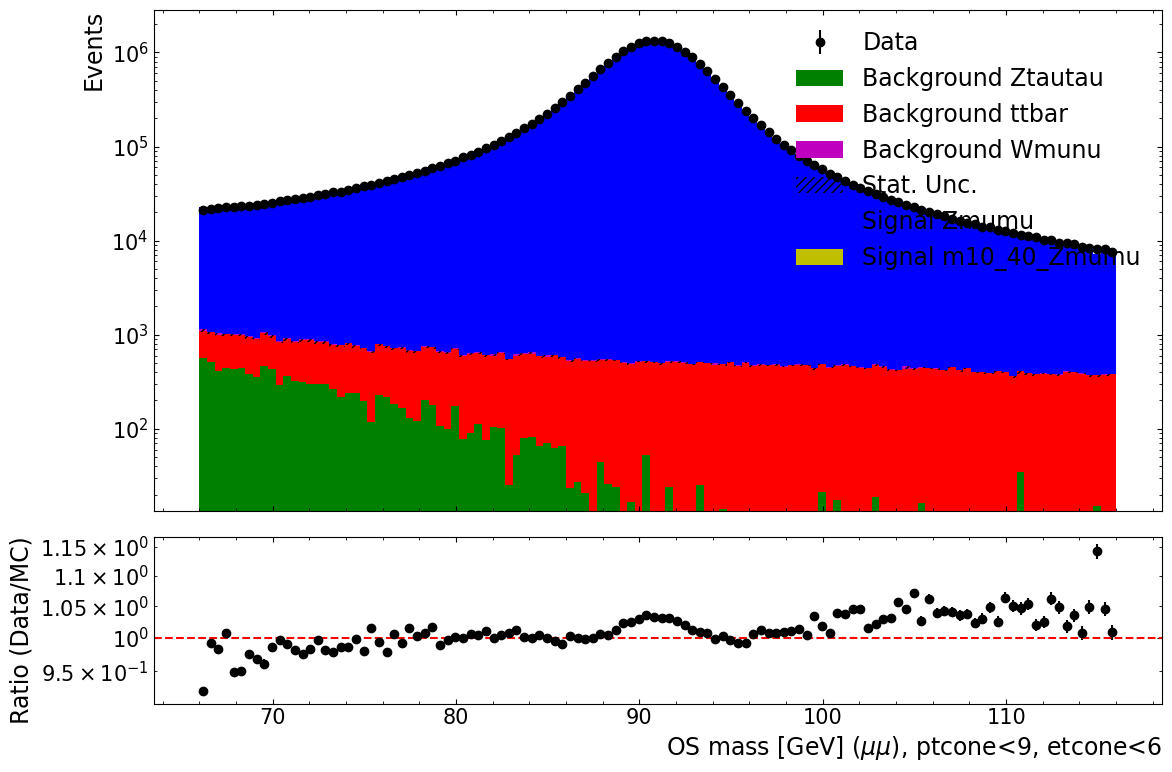

Elapsed time = 0.4s


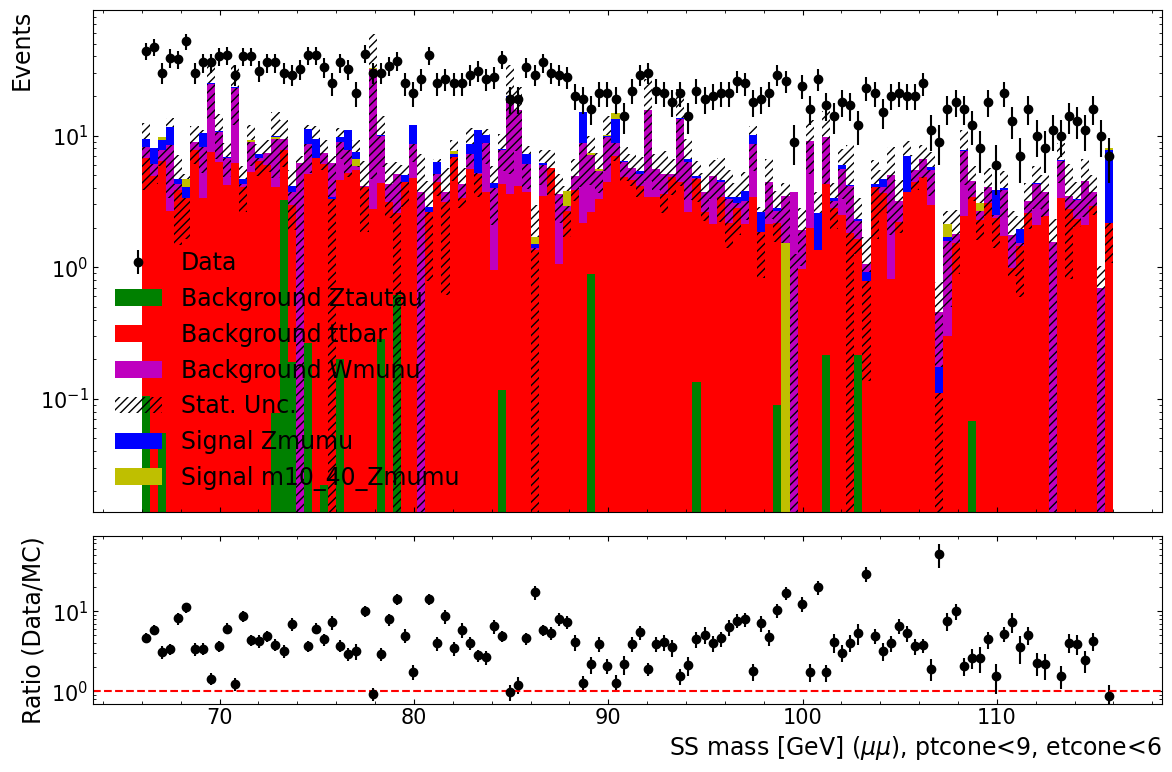

In [146]:
# Zmumu OS SS figure
color_list = ['k','b','g','r','m','y']
def fix_stacked_fig_style(fig, fontsize=18, legend_fontsize=16, width=8, height=6):
    fig.set_size_inches(width, height)

    for ax in fig.axes:
        ax.xaxis.label.set_size(fontsize)
        ax.yaxis.label.set_size(fontsize)
        ax.tick_params(axis="both", labelsize=fontsize-2)

        leg = ax.get_legend()
        if leg is not None:
            for text in leg.get_texts():
                text.set_fontsize(legend_fontsize)

        for text in ax.texts:
            text.set_fontsize(fontsize-2)

    fig.tight_layout()
    return fig

fig_mu_os_cut, hists_mu_os_cut = plot_stacked_hist(
    plot_dict_mu_OS_cut,
    'mass',
    color_list,
    num_bins=120,
    xmin=66,
    xmax=116,
    x_label=rf'OS mass [GeV] ($\mu\mu$), ptcone<{Zmumu_PTcone_cut}, etcone<{Zmumu_ETcone_cut}',
    logy=True,
    show_text=False,
    residual_plot=True,
    save_fig=False
)

fig_mu_ss_cut, hists_mu_ss_cut = plot_stacked_hist(
    plot_dict_mu_SS_cut,
    'mass',
    color_list,
    num_bins=120,
    xmin=66,
    xmax=116,
    x_label=rf'SS mass [GeV] ($\mu\mu$), ptcone<{Zmumu_PTcone_cut}, etcone<{Zmumu_ETcone_cut}',
    logy=True,
    show_text=False,
    residual_plot=True,
    save_fig=False
)


The Z-ee same sign figure shows some features:
At the peak, Monte carlo is larger than the data. Also for larger mass, MC and data generally fit. So it is not a good choice to use the wrong sign at this situation. 

Elapsed time = 0.5s


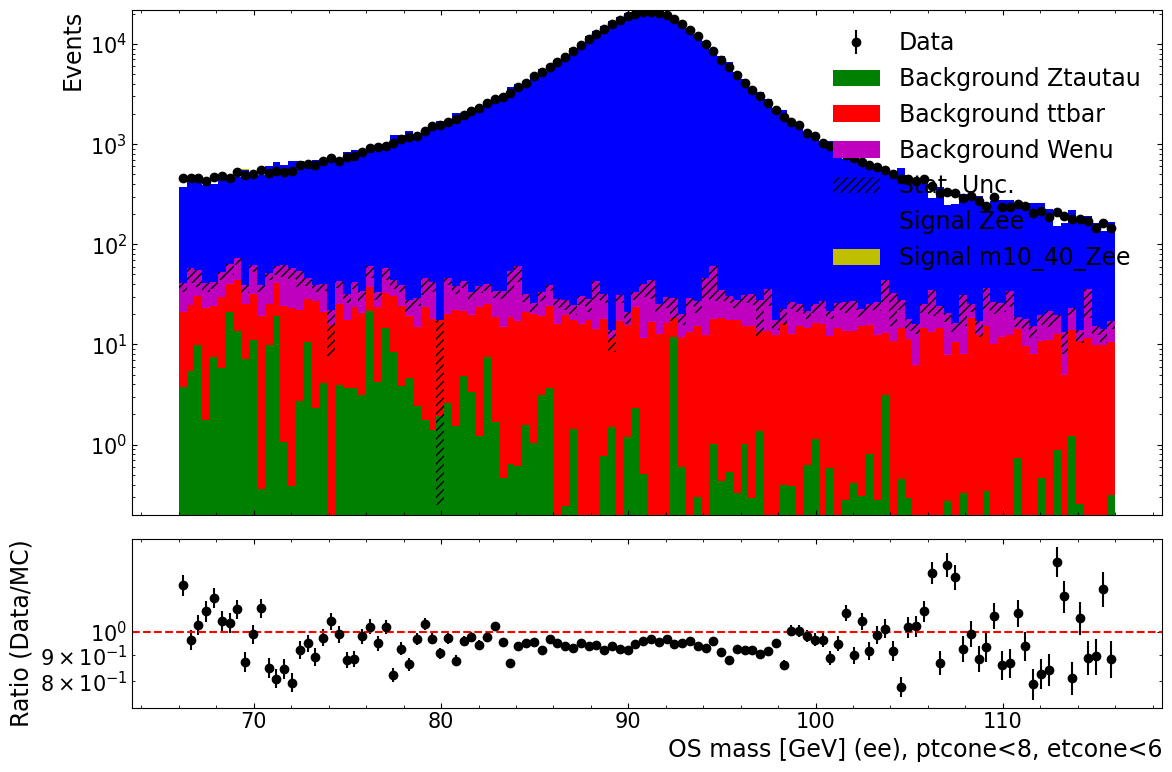

Elapsed time = 0.4s


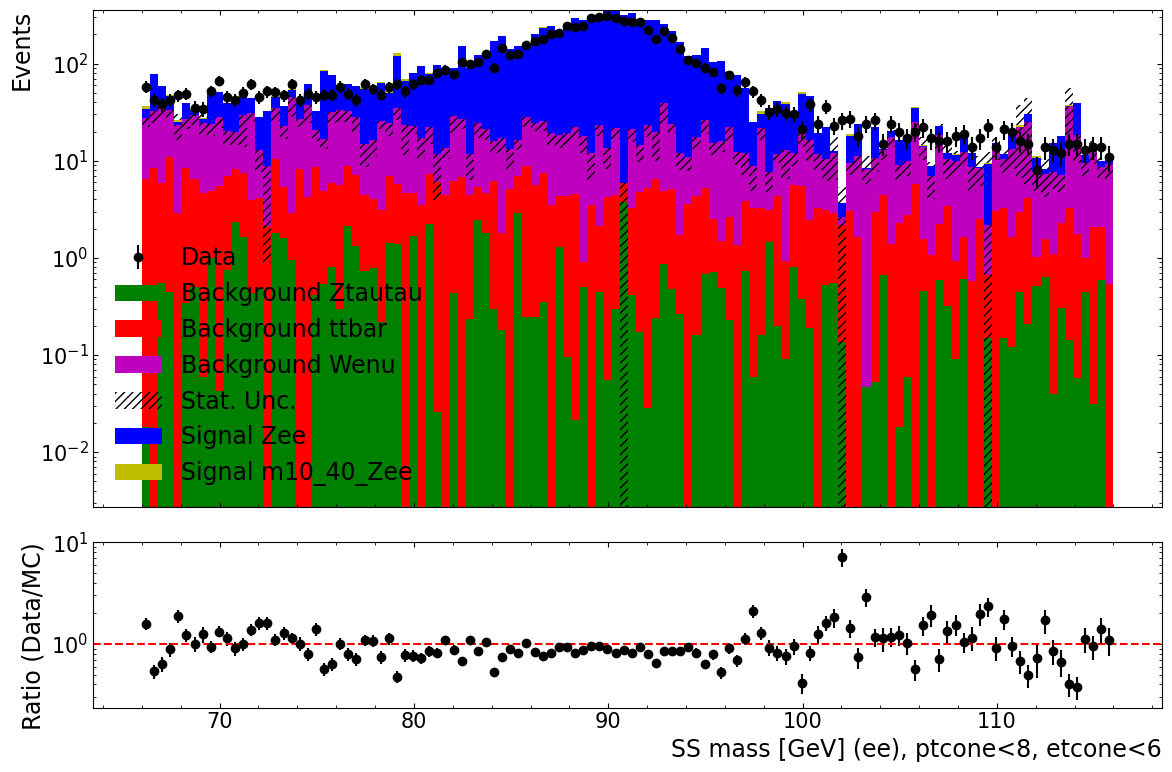

In [163]:
color_list = ['k','b','g','r','m','y']
fig_ee_os_cut, hists_ee_os_cut = plot_stacked_hist(
    plot_dict_ee_OS_mapped,
    'mass',
    color_list,
    num_bins=120,
    xmin=66,
    xmax=116,
    x_label=rf'OS mass [GeV] (ee), ptcone<{Zee_PTcone_cut}, etcone<{Zee_ETcone_cut}',
    logy=True,
    show_text=False,
    residual_plot=True,
    save_fig=False
)
fig_ee_ss_cut, hists_ee_ss_cut = plot_stacked_hist(
    plot_dict_ee_SS_mapped,
    'mass',
    color_list,
    num_bins=120,
    xmin=66,
    xmax=116,
    x_label=rf'SS mass [GeV] (ee), ptcone<{Zee_PTcone_cut}, etcone<{Zee_ETcone_cut}',
    logy=True,
    show_text=False,
    residual_plot=True,
    save_fig=False
)
fig_mu_os_cut = fix_stacked_fig_style(fig_mu_os_cut, fontsize=25, legend_fontsize=30, width=9, height=7)
fig_ee_os_cut = fix_stacked_fig_style(fig_ee_os_cut, fontsize=25, legend_fontsize=30, width=9, height=7)
fig_mu_ss_cut = fix_stacked_fig_style(fig_mu_ss_cut, fontsize=25, legend_fontsize=30, width=9, height=7)
fig_ee_ss_cut = fix_stacked_fig_style(fig_ee_ss_cut, fontsize=25, legend_fontsize=30, width=9, height=7)

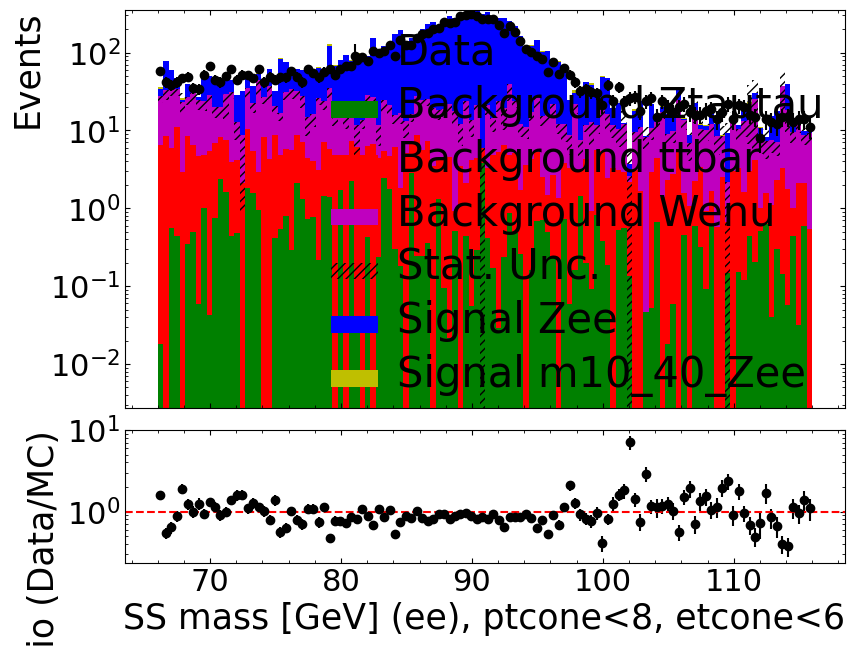

In [168]:
fig_ee_ss_cut

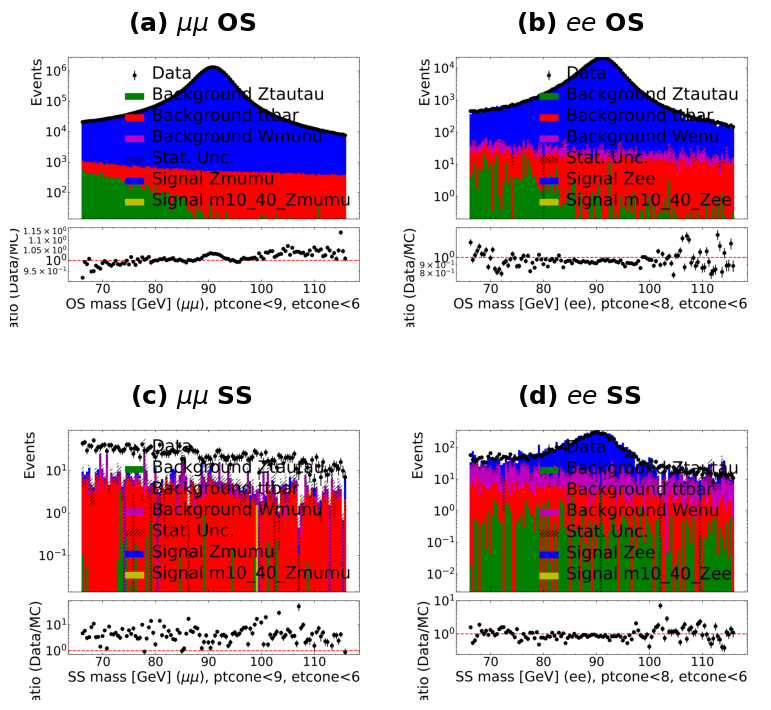

In [164]:
import io
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def fix_stacked_fig_style(fig, fontsize=18, legend_fontsize=15, width=9, height=7):
    fig.set_size_inches(width, height)

    for ax in fig.axes:
        ax.xaxis.label.set_size(fontsize)
        ax.yaxis.label.set_size(fontsize)
        ax.tick_params(axis="both", labelsize=fontsize-3)

        leg = ax.get_legend()
        if leg is not None:
            for text in leg.get_texts():
                text.set_fontsize(legend_fontsize)

        for text in ax.texts:
            text.set_fontsize(fontsize-3)

    # 手动留空间，避免 ratio label 被切
    fig.subplots_adjust(left=0.16, right=0.96, top=0.95, bottom=0.16, hspace=0.08)
    return fig
color_list = ['k','b','g','r','m','y']

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})
def fig_to_img(fig, dpi=350):
    import io
    import matplotlib.image as mpimg

    buf = io.BytesIO()
    fig.savefig(
        buf,
        format="png",
        dpi=dpi,
        bbox_inches=None,   # 关键：不要 tight 裁剪
        pad_inches=0.3
    )
    buf.seek(0)
    img = mpimg.imread(buf)
    plt.close(fig)
    return img



# =========================
# Convert figures to images
# =========================

imgs = [
    fig_to_img(fig_mu_os_cut),
    fig_to_img(fig_ee_os_cut),
    fig_to_img(fig_mu_ss_cut),
    fig_to_img(fig_ee_ss_cut),
]

titles = [
    r"(a) $\mu\mu$ OS",
    r"(b) $ee$ OS",
    r"(c) $\mu\mu$ SS",
    r"(d) $ee$ SS",
]

    
# =========================
# Combine into one 2x2 figure
# =========================

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, img, title in zip(axes.flat, imgs, titles):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title, fontsize=18, fontweight="bold", pad=10)

plt.tight_layout()

plt.show()

In [80]:
LUMI_FB = 36.6
PRODUCED_ZMUMU = produced_event_count("Zmumu", LUMI_FB)
print("Cached produced Zmumu =", PRODUCED_ZMUMU)

The total number of produced events (sum of weights) for Monte Carlo data set Zmumu and luminosity 36.6 inverse femtobarns is 81299580
Cached produced Zmumu = 81299580.00000001


In [81]:
# =========================
# Global nominal settings
# =========================

MASS_LOW_NOM = 66
MASS_HIGH_NOM = 116

MU_SIGNAL_KEY = "Signal Zmumu"


# =========================
# Helpers
# =========================
def clone_plot_dict(plot_dict):
    return {k: v for k, v in plot_dict.items()}


def background_keys(plot_dict):
    return [k for k in plot_dict.keys() if k.startswith("Background")]


def total_background_yield_in_mass(plot_dict, ptcut=None, etcut=None, mlow=MASS_LOW_NOM, mhigh=MASS_HIGH_NOM):
    total = 0.0
    for k, arr in plot_dict.items():
        if k.startswith("Background"):
            total += weighted_yield_in_mass(arr, ptcut=ptcut, etcut=etcut, mlow=mlow, mhigh=mhigh)
    return total


def per_background_yield_in_mass(plot_dict, ptcut=None, etcut=None, mlow=MASS_LOW_NOM, mhigh=MASS_HIGH_NOM):
    out = {}
    for k, arr in plot_dict.items():
        if k.startswith("Background"):
            out[k] = weighted_yield_in_mass(arr, ptcut=ptcut, etcut=etcut, mlow=mlow, mhigh=mhigh)
    return out


def signal_yield_in_mass(plot_dict, signal_key=MU_SIGNAL_KEY,
                         ptcut=None, etcut=None, mlow=MASS_LOW_NOM, mhigh=MASS_HIGH_NOM):
    return weighted_yield_in_mass(
        plot_dict[signal_key],
        ptcut=ptcut, etcut=etcut,
        mlow=mlow, mhigh=mhigh
    )


def efficiency_in_mass_fast(plot_dict, signal_key=MU_SIGNAL_KEY,
                            produced_signal=PRODUCED_ZMUMU,
                            ptcut=None, etcut=None,
                            mlow=MASS_LOW_NOM, mhigh=MASS_HIGH_NOM):
    sig = signal_yield_in_mass(
        plot_dict,
        signal_key=signal_key,
        ptcut=ptcut, etcut=etcut,
        mlow=mlow, mhigh=mhigh
    )
    return sig / produced_signal


def apply_iso_to_plot_dict(plot_dict, ptcut=None, etcut=None):
    return {
        k: apply_iso_cut(v, ptcone_cut=ptcut, etcone_cut=etcut)
        for k, v in plot_dict.items()
    }

In [82]:
#data cut after applying mass window, iso cuts, or both
def event_flow_counts(plot_dict, ptcut=None, etcut=None, mlow=MASS_LOW_NOM, mhigh=MASS_HIGH_NOM):
    out = {}

    for name, arr in plot_dict.items():
        mask_mass = (arr["mass"] > mlow) & (arr["mass"] < mhigh)

        if ptcut is not None:
            mask_iso = (
                (arr["lep_ptvarcone30"][:, 0] < ptcut) &
                (arr["lep_ptvarcone30"][:, 1] < ptcut)
            )
        else:
            mask_iso = ak.ones_like(arr["mass"], dtype=bool)

        if etcut is not None:
            mask_iso = mask_iso & (
                (arr["lep_topoetcone20"][:, 0] < etcut) &
                (arr["lep_topoetcone20"][:, 1] < etcut)
            )

        mask_both = mask_mass & mask_iso

        if name == "Data":
            out[name] = {
                "n_total": len(arr),
                "n_after_mass": int(ak.sum(mask_mass)),
                "n_after_iso": int(ak.sum(mask_iso)),
                "n_after_mass_and_iso": int(ak.sum(mask_both)),
            }
        else:
            out[name] = {
                "w_total": float(ak.sum(arr["totalWeight"])),
                "w_after_mass": float(ak.sum(arr["totalWeight"][mask_mass])),
                "w_after_iso": float(ak.sum(arr["totalWeight"][mask_iso])),
                "w_after_mass_and_iso": float(ak.sum(arr["totalWeight"][mask_both])),
            }

    return out


def cutflow_table(plot_dict, ptcut=None, etcut=None, mlow=MASS_LOW_NOM, mhigh=MASS_HIGH_NOM):
    flow = event_flow_counts(plot_dict, ptcut=ptcut, etcut=etcut, mlow=mlow, mhigh=mhigh)
    rows = []
    for sample, vals in flow.items():
        row = {"sample": sample}
        row.update(vals)
        rows.append(row)
    return pd.DataFrame(rows)

# example code: cutflow_table(plot_dict_mu_OS_mapped, ptcut=9, etcut=6, mlow=66, mhigh=116)

In [83]:
#template correction sample for wrong flavour and wrong sign
def make_weighted_template_from_data(data_arr, target_yield,
                                     mlow=MASS_LOW_NOM, mhigh=MASS_HIGH_NOM,
                                     restrict_to_window=True):
    """
    Use Data shape as template, assign constant per-event weight
    so the selected sample has total weighted yield = target_yield.
    """

    if restrict_to_window:
        mask = (data_arr["mass"] > mlow) & (data_arr["mass"] < mhigh)
        template = data_arr[mask]
    else:
        template = data_arr

    n = len(template)
    if n == 0:
        raise ValueError("Template has zero events.")

    per_event_weight = target_yield / n
    weights = ak.ones_like(template["mass"]) * per_event_weight

    if "totalWeight" in template.fields:
        template = ak.with_field(template, weights, "totalWeight")
    else:
        template = ak.with_field(template, weights, "totalWeight")

    return template


def add_sample_to_existing(existing_arr, extra_arr):
    return ak.concatenate([existing_arr, extra_arr], axis=0)

In [84]:
def compute_df_delta(plot_dict_mue, ptcut=None, etcut=None, mlow=MASS_LOW_NOM, mhigh=MASS_HIGH_NOM):
    """
    wrong flavour (different flavour) correction:
    delta_df = 0.5 * (N_data^eμ - N_MC^eμ)
    """
    n_data = data_count_in_mass(
        plot_dict_mue["Data"],
        ptcut=ptcut, etcut=etcut,
        mlow=mlow, mhigh=mhigh
    )

    n_mc = 0.0
    for k, arr in plot_dict_mue.items():
        if k != "Data":
            n_mc += weighted_yield_in_mass(
                arr,
                ptcut=ptcut, etcut=etcut,
                mlow=mlow, mhigh=mhigh
            )

    delta_df = 0.5 * (n_data - n_mc)

    return {
        "mue_data": n_data,
        "mue_mc": n_mc,
        "delta_df": delta_df,
    }


def compute_ss_delta(plot_dict_os, plot_dict_ss, ptcut=None, etcut=None, mlow=MASS_LOW_NOM, mhigh=MASS_HIGH_NOM):
    """
    wrong sign correction:
    delta_ss = N_data^SS - N_MC^SS
    corrected OS data count = N_data^OS - delta_ss
    """
    os_data = data_count_in_mass(
        plot_dict_os["Data"],
        ptcut=ptcut, etcut=etcut,
        mlow=mlow, mhigh=mhigh
    )

    ss_data = data_count_in_mass(
        plot_dict_ss["Data"],
        ptcut=ptcut, etcut=etcut,
        mlow=mlow, mhigh=mhigh
    )

    ss_mc = 0.0
    for k, arr in plot_dict_ss.items():
        if k.startswith("Background"):
            ss_mc += weighted_yield_in_mass(
                arr,
                ptcut=ptcut, etcut=etcut,
                mlow=mlow, mhigh=mhigh
            )

    delta_ss = ss_data - ss_mc
    corrected_os_data = os_data - delta_ss

    return {
        "os_data": os_data,
        "ss_data": ss_data,
        "ss_mc": ss_mc,
        "delta_ss": delta_ss,
        "corrected_os_data": corrected_os_data,
    }

In [85]:
def sigma_from_components(n_selected, n_background, eff, lumi_fb=LUMI_FB):
    sigma = (n_selected - n_background) / (eff * lumi_fb)
    unc_stat = np.sqrt(max(n_selected + n_background, 0.0)) / (eff * lumi_fb)
    unc_lumi = 0.017 * sigma

    return {
        "sigma_fb": sigma,
        "unc_stat_fb": unc_stat,
        "unc_lumi_fb": unc_lumi,
    }

In [86]:
def run_zmumu_pipeline_light(
    plot_dict_mu_os_base,
    plot_dict_mu_ss_base,
    plot_dict_mue_os_base,
    lumi_fb=LUMI_FB,
    ptcut=None,
    etcut=None,
    mlow=MASS_LOW_NOM,
    mhigh=MASS_HIGH_NOM,
    apply_df=False,
    apply_ss=False,
    order=("iso", "df", "ss"),
):
    """
    Lightweight pipeline:
    - no ak.concatenate
    - no fake weighted Data arrays
    - corrections are applied numerically to yields/counts
    """

    # Start from original dicts
    mu_os = plot_dict_mu_os_base
    mu_ss = plot_dict_mu_ss_base
    mue_os = plot_dict_mue_os_base

    # Apply isolation first only if requested in order
    # We use a flag to know whether later calculations should use ptcut/etcut
    iso_already_applied = False

    df_info = None
    ss_info = None

    # Running components
    n_selected = None
    n_background = None
    sig_yield = None

    # Helper: current cuts to use inside yield functions
    def current_cuts():
        if iso_already_applied:
            return None, None
        else:
            return ptcut, etcut

    for step in order:
        if step == "iso":
            mu_os = apply_iso_to_plot_dict(mu_os, ptcut=ptcut, etcut=etcut)
            mu_ss = apply_iso_to_plot_dict(mu_ss, ptcut=ptcut, etcut=etcut)
            mue_os = apply_iso_to_plot_dict(mue_os, ptcut=ptcut, etcut=etcut)
            iso_already_applied = True

        elif step == "df" and apply_df:
            cpt, cet = current_cuts()
            df_info = compute_df_delta(
                mue_os,
                ptcut=cpt, etcut=cet,
                mlow=mlow, mhigh=mhigh
            )

        elif step == "ss" and apply_ss:
            cpt, cet = current_cuts()
            ss_info = compute_ss_delta(
                mu_os, mu_ss,
                ptcut=cpt, etcut=cet,
                mlow=mlow, mhigh=mhigh
            )

    # Final cuts at evaluation stage
    cpt, cet = current_cuts()

    # Nominal selected data count
    n_selected_raw = data_count_in_mass(
        mu_os["Data"],
        ptcut=cpt, etcut=cet,
        mlow=mlow, mhigh=mhigh
    )

    # Apply SS correction numerically
    if apply_ss and ss_info is not None:
        n_selected = ss_info["corrected_os_data"]
    else:
        n_selected = n_selected_raw

    # Background from MC
    n_background = total_background_yield_in_mass(
        mu_os,
        ptcut=cpt, etcut=cet,
        mlow=mlow, mhigh=mhigh
    )

    # Signal efficiency from signal MC
    sig_yield_nom = weighted_yield_in_mass(
        mu_os[MU_SIGNAL_KEY],
        ptcut=cpt, etcut=cet,
        mlow=mlow, mhigh=mhigh
    )

    # Apply DF correction numerically to signal yield
    if apply_df and df_info is not None:
        sig_yield = sig_yield_nom + df_info["delta_df"]
    else:
        sig_yield = sig_yield_nom

    eff = sig_yield / PRODUCED_ZMUMU

    sigma_info = sigma_from_components(
        n_selected=n_selected,
        n_background=n_background,
        eff=eff,
        lumi_fb=lumi_fb
    )

    return {
        "ptcut": ptcut,
        "etcut": etcut,
        "mlow": mlow,
        "mhigh": mhigh,
        "order": " -> ".join(order),
        "apply_df": apply_df,
        "apply_ss": apply_ss,
        "df_info": df_info,
        "ss_info": ss_info,
        "N_selected": n_selected,
        "N_background": n_background,
        "eff": eff,
        **sigma_info
    }

The cell below can scan the etcut, ptcut, correction mode, order and mass window.

In [87]:
"""def scan_zmumu_systematics(
    plot_dict_mu_os_base,
    plot_dict_mu_ss_base,
    plot_dict_mue_os_base,
    lumi_fb=LUMI_FB,
    ptcuts=(None, 6, 7, 8, 9, 10),
    etcuts=(None, 4, 5, 6, 7, 8),
    mass_windows=((66, 116),),
    correction_modes=("none", "df", "ss", "df+ss"),
    orders=(
        ("iso", "df", "ss"),
        ("df", "iso", "ss"),
        ("ss", "iso", "df"),
        ("df", "ss", "iso"),
    ),
):
    rows = []

    total_steps = (
        len(mass_windows) *
        len(ptcuts) *
        len(etcuts) *
        len(correction_modes) *
        len(orders)
    )

    with tqdm(total=total_steps, desc="Scanning systematics") as pbar:
        for (mlow, mhigh) in mass_windows:
            for ptcut in ptcuts:
                for etcut in etcuts:
                    # cutflow only depends on window + iso cuts
                    flow = event_flow_counts(
                        plot_dict_mu_os_base,
                        ptcut=ptcut,
                        etcut=etcut,
                        mlow=mlow,
                        mhigh=mhigh
                    )

                    for mode in correction_modes:
                        apply_df = mode in ("df", "df+ss")
                        apply_ss = mode in ("ss", "df+ss")

                        for order in orders:
                            result = run_zmumu_pipeline_light(
                                plot_dict_mu_os_base=plot_dict_mu_os_base,
                                plot_dict_mu_ss_base=plot_dict_mu_ss_base,
                                plot_dict_mue_os_base=plot_dict_mue_os_base,
                                lumi_fb=lumi_fb,
                                ptcut=ptcut,
                                etcut=etcut,
                                mlow=mlow,
                                mhigh=mhigh,
                                apply_df=apply_df,
                                apply_ss=apply_ss,
                                order=order,
                            )

                            rows.append({
                                "mlow": mlow,
                                "mhigh": mhigh,
                                "ptcut": ptcut,
                                "etcut": etcut,
                                "mode": mode,
                                "order": result["order"],
                                "sigma_fb": result["sigma_fb"],
                                "unc_stat_fb": result["unc_stat_fb"],
                                "unc_lumi_fb": result["unc_lumi_fb"],
                                "N_selected": result["N_selected"],
                                "N_background": result["N_background"],
                                "eff": result["eff"],
                                "delta_df": None if result["df_info"] is None else result["df_info"]["delta_df"],
                                "delta_ss": None if result["ss_info"] is None else result["ss_info"]["delta_ss"],
                                "data_n_total": flow["Data"]["n_total"],
                                "data_n_after_mass": flow["Data"]["n_after_mass"],
                                "data_n_after_iso": flow["Data"]["n_after_iso"],
                                "data_n_after_mass_and_iso": flow["Data"]["n_after_mass_and_iso"],
                            })

                            pbar.update(1)

    return pd.DataFrame(rows)"""

'def scan_zmumu_systematics(\n    plot_dict_mu_os_base,\n    plot_dict_mu_ss_base,\n    plot_dict_mue_os_base,\n    lumi_fb=LUMI_FB,\n    ptcuts=(None, 6, 7, 8, 9, 10),\n    etcuts=(None, 4, 5, 6, 7, 8),\n    mass_windows=((66, 116),),\n    correction_modes=("none", "df", "ss", "df+ss"),\n    orders=(\n        ("iso", "df", "ss"),\n        ("df", "iso", "ss"),\n        ("ss", "iso", "df"),\n        ("df", "ss", "iso"),\n    ),\n):\n    rows = []\n\n    total_steps = (\n        len(mass_windows) *\n        len(ptcuts) *\n        len(etcuts) *\n        len(correction_modes) *\n        len(orders)\n    )\n\n    with tqdm(total=total_steps, desc="Scanning systematics") as pbar:\n        for (mlow, mhigh) in mass_windows:\n            for ptcut in ptcuts:\n                for etcut in etcuts:\n                    # cutflow only depends on window + iso cuts\n                    flow = event_flow_counts(\n                        plot_dict_mu_os_base,\n                        ptcut=ptcut,\n   

This cell is for ptcut, etcut and correction mode.

In [88]:
def scan_zmumu_systematics_fast(
    plot_dict_mu_os_base,
    plot_dict_mu_ss_base,
    plot_dict_mue_os_base,
    lumi_fb=LUMI_FB,
    ptcuts=(6, 7, 8, 9, 10),
    etcuts=(4, 5, 6, 7, 8),
    correction_modes=("none", "df", "ss", "df+ss"),
    mlow=MASS_LOW_NOM,
    mhigh=MASS_HIGH_NOM,
    order=("iso", "df", "ss"),
):
    rows = []

    total_steps = len(ptcuts) * len(etcuts) * len(correction_modes)

    with tqdm(total=total_steps, desc="Scanning pt/et cuts") as pbar:
        for ptcut in ptcuts:
            for etcut in etcuts:
                flow = event_flow_counts(
                    plot_dict_mu_os_base,
                    ptcut=ptcut,
                    etcut=etcut,
                    mlow=mlow,
                    mhigh=mhigh
                )

                for mode in correction_modes:
                    apply_df = mode in ("df", "df+ss")
                    apply_ss = mode in ("ss", "df+ss")

                    result = run_zmumu_pipeline_light(
                        plot_dict_mu_os_base=plot_dict_mu_os_base,
                        plot_dict_mu_ss_base=plot_dict_mu_ss_base,
                        plot_dict_mue_os_base=plot_dict_mue_os_base,
                        lumi_fb=lumi_fb,
                        ptcut=ptcut,
                        etcut=etcut,
                        mlow=mlow,
                        mhigh=mhigh,
                        apply_df=apply_df,
                        apply_ss=apply_ss,
                        order=order,
                    )

                    rows.append({
                        "ptcut": ptcut,
                        "etcut": etcut,
                        "mode": mode,
                        "order": result["order"],
                        "mlow": mlow,
                        "mhigh": mhigh,
                        "sigma_fb": result["sigma_fb"],
                        "unc_stat_fb": result["unc_stat_fb"],
                        "unc_lumi_fb": result["unc_lumi_fb"],
                        "N_selected": result["N_selected"],
                        "N_background": result["N_background"],
                        "eff": result["eff"],
                        "delta_df": None if result["df_info"] is None else result["df_info"]["delta_df"],
                        "delta_ss": None if result["ss_info"] is None else result["ss_info"]["delta_ss"],
                        "data_n_total": flow["Data"]["n_total"],
                        "data_n_after_mass": flow["Data"]["n_after_mass"],
                        "data_n_after_iso": flow["Data"]["n_after_iso"],
                        "data_n_after_mass_and_iso": flow["Data"]["n_after_mass_and_iso"],
                    })

                    pbar.update(1)

    return pd.DataFrame(rows)

In [89]:
#systematic extraction
def systematic_from_variation(df, nominal_mask, group_cols=None, value_col="sigma_fb"):
    """
    Compare all rows in df to the single nominal row selected by nominal_mask.
    Returns dataframe with delta_sigma and relative shifts.
    """
    sub = df.copy()
    nominal = sub[nominal_mask]

    if len(nominal) != 1:
        raise ValueError("nominal_mask must select exactly one row.")

    sigma_nom = nominal.iloc[0][value_col]

    sub["delta_sigma"] = sub[value_col] - sigma_nom
    sub["abs_delta_sigma"] = np.abs(sub["delta_sigma"])
    sub["rel_delta_percent"] = 100.0 * sub["delta_sigma"] / sigma_nom
    sub["abs_rel_delta_percent"] = np.abs(sub["rel_delta_percent"])

    return sigma_nom, sub


def max_systematic(df_with_delta):
    return {
        "sys_abs_fb": df_with_delta["abs_delta_sigma"].max(),
        "sys_rel_percent": df_with_delta["abs_rel_delta_percent"].max()
    }


def rms_systematic(df_with_delta):
    rms_abs = float(np.sqrt(np.mean(df_with_delta["delta_sigma"]**2)))
    sigma_nom = None
    if "rel_delta_percent" in df_with_delta.columns:
        # recover from any nonzero row
        pass
    return {
        "sys_abs_fb": rms_abs
    }

In [90]:
# =========================
# Nominal choices
# =========================
NOMINAL_PTCUT_MU = 9
NOMINAL_ETCUT_MU = 6
NOMINAL_MASS_WINDOW = (66, 116)
NOMINAL_MODE = "df"
NOMINAL_ORDER = "iso -> df -> ss"

# Suggested scan ranges
PTCUTS = list(range(2, 16)) 
ETCUTS = list(range(2, 16))
'''MASS_WINDOWS = [
    (60, 120),
    (66, 116),
    (70, 110),
    (75, 105),
    (80, 100),
]'''
CORRECTION_MODES = ["none", "df", "ss", "df+ss"]
ORDERS = [
    ("iso", "df", "ss"),
    ("df", "iso", "ss"),
    ("ss", "iso", "df"),
    ("df", "ss", "iso"),
]

Scanning cell is below:

In [91]:
'''mlow0, mhigh0 = NOMINAL_MASS_WINDOW

df_scan = scan_zmumu_systematics_fast(
    plot_dict_mu_os_base=plot_dict_mu_OS_mapped,
    plot_dict_mu_ss_base=plot_dict_mu_SS_mapped,
    plot_dict_mue_os_base=plot_dict_mue_OS_mapped,
    lumi_fb=LUMI_FB,
    ptcuts=PTCUTS,
    etcuts=ETCUTS,
    correction_modes=CORRECTION_MODES,
    mlow=mlow0,
    mhigh=mhigh0,
    order=("iso", "df", "ss"),
)

df_scan.head()'''

'mlow0, mhigh0 = NOMINAL_MASS_WINDOW\n\ndf_scan = scan_zmumu_systematics_fast(\n    plot_dict_mu_os_base=plot_dict_mu_OS_mapped,\n    plot_dict_mu_ss_base=plot_dict_mu_SS_mapped,\n    plot_dict_mue_os_base=plot_dict_mue_OS_mapped,\n    lumi_fb=LUMI_FB,\n    ptcuts=PTCUTS,\n    etcuts=ETCUTS,\n    correction_modes=CORRECTION_MODES,\n    mlow=mlow0,\n    mhigh=mhigh0,\n    order=("iso", "df", "ss"),\n)\n\ndf_scan.head()'

In [92]:
'''mlow0, mhigh0 = NOMINAL_MASS_WINDOW

df_nominal = df_scan[
    (df_scan["ptcut"] == NOMINAL_PTCUT_MU) &
    (df_scan["etcut"] == NOMINAL_ETCUT_MU) &
    (df_scan["mlow"] == mlow0) &
    (df_scan["mhigh"] == mhigh0) &
    (df_scan["mode"] == NOMINAL_MODE) &
    (df_scan["order"] == NOMINAL_ORDER)
]

df_nominal[[
    "mlow", "mhigh", "ptcut", "etcut", "mode", "order",
    "sigma_fb", "unc_stat_fb", "unc_lumi_fb",
    "N_selected", "N_background", "eff",
    "delta_df", "delta_ss",
    "data_n_total", "data_n_after_mass", "data_n_after_iso", "data_n_after_mass_and_iso"
]]'''

'mlow0, mhigh0 = NOMINAL_MASS_WINDOW\n\ndf_nominal = df_scan[\n    (df_scan["ptcut"] == NOMINAL_PTCUT_MU) &\n    (df_scan["etcut"] == NOMINAL_ETCUT_MU) &\n    (df_scan["mlow"] == mlow0) &\n    (df_scan["mhigh"] == mhigh0) &\n    (df_scan["mode"] == NOMINAL_MODE) &\n    (df_scan["order"] == NOMINAL_ORDER)\n]\n\ndf_nominal[[\n    "mlow", "mhigh", "ptcut", "etcut", "mode", "order",\n    "sigma_fb", "unc_stat_fb", "unc_lumi_fb",\n    "N_selected", "N_background", "eff",\n    "delta_df", "delta_ss",\n    "data_n_total", "data_n_after_mass", "data_n_after_iso", "data_n_after_mass_and_iso"\n]]'

In [93]:
'''mlow0, mhigh0 = NOMINAL_MASS_WINDOW

df_nominal = df_scan[
    (df_scan["ptcut"] == NOMINAL_PTCUT_MU) &
    (df_scan["etcut"] == NOMINAL_ETCUT_MU) &
    (df_scan["mode"] == NOMINAL_MODE)
]

df_nominal'''

'mlow0, mhigh0 = NOMINAL_MASS_WINDOW\n\ndf_nominal = df_scan[\n    (df_scan["ptcut"] == NOMINAL_PTCUT_MU) &\n    (df_scan["etcut"] == NOMINAL_ETCUT_MU) &\n    (df_scan["mode"] == NOMINAL_MODE)\n]\n\ndf_nominal'

In [94]:
'''df_scan.to_csv("df_scan_with_more_pt_et.csv", index=False)
df_scan.to_pickle("df_scan_with_more_pt_et.pkl")'''

'df_scan.to_csv("df_scan_with_more_pt_et.csv", index=False)\ndf_scan.to_pickle("df_scan_with_more_pt_et.pkl")'

In [95]:
'''#Effect of mass windows
mlow0, mhigh0 = NOMINAL_MASS_WINDOW

df_mass = df_scan[
    (df_scan["ptcut"] == NOMINAL_PTCUT_MU) &
    (df_scan["etcut"] == NOMINAL_ETCUT_MU) &
    (df_scan["mode"] == NOMINAL_MODE) &
    (df_scan["order"] == NOMINAL_ORDER)
].copy()

sigma_nom, df_mass_var = systematic_from_variation(
    df_mass,
    nominal_mask=((df_mass["mlow"] == mlow0) & (df_mass["mhigh"] == mhigh0))
)

mass_sys = max_systematic(df_mass_var)

print("Nominal sigma =", sigma_nom, "fb")
print("Mass-window systematic =", mass_sys)

df_mass_var[[
    "mlow", "mhigh",
    "sigma_fb", "delta_sigma", "rel_delta_percent",
    "data_n_after_mass", "data_n_after_mass_and_iso"
]].sort_values(["mlow", "mhigh"])'''

'#Effect of mass windows\nmlow0, mhigh0 = NOMINAL_MASS_WINDOW\n\ndf_mass = df_scan[\n    (df_scan["ptcut"] == NOMINAL_PTCUT_MU) &\n    (df_scan["etcut"] == NOMINAL_ETCUT_MU) &\n    (df_scan["mode"] == NOMINAL_MODE) &\n    (df_scan["order"] == NOMINAL_ORDER)\n].copy()\n\nsigma_nom, df_mass_var = systematic_from_variation(\n    df_mass,\n    nominal_mask=((df_mass["mlow"] == mlow0) & (df_mass["mhigh"] == mhigh0))\n)\n\nmass_sys = max_systematic(df_mass_var)\n\nprint("Nominal sigma =", sigma_nom, "fb")\nprint("Mass-window systematic =", mass_sys)\n\ndf_mass_var[[\n    "mlow", "mhigh",\n    "sigma_fb", "delta_sigma", "rel_delta_percent",\n    "data_n_after_mass", "data_n_after_mass_and_iso"\n]].sort_values(["mlow", "mhigh"])'

In [96]:
df_scan = pd.read_pickle("df_scan_with_more_pt_et.pkl")
print(type(df_scan))
print(df_scan.head())
print(df_scan.columns)

<class 'pandas.DataFrame'>
   ptcut  etcut   mode            order  mlow  mhigh      sigma_fb  \
0      2      2   none  iso -> df -> ss    66    116  2.213839e+06   
1      2      2     df  iso -> df -> ss    66    116  2.212488e+06   
2      2      2     ss  iso -> df -> ss    66    116  2.213770e+06   
3      2      2  df+ss  iso -> df -> ss    66    116  2.212419e+06   
4      2      3   none  iso -> df -> ss    66    116  2.222950e+06   

   unc_stat_fb   unc_lumi_fb    N_selected  N_background       eff  \
0   514.019357  37635.258818  1.870960e+07  53558.550974  0.230246   
1   513.705666  37612.291164  1.870960e+07  53558.550974  0.230387   
2   514.011366  37634.081959  1.870902e+07  53558.550974  0.230246   
3   513.697680  37611.115023  1.870902e+07  53558.550974  0.230387   
4   485.017092  37790.142570  2.118808e+07  60895.829183  0.259675   

       delta_df    delta_ss  data_n_total  data_n_after_mass  \
0           NaN         NaN      26363258           24783058   
1  

In [97]:
# ============================================
# Zmumu: mode comparison with "none" as nominal
# ============================================

mlow0, mhigh0 = NOMINAL_MASS_WINDOW

df_nom_modes = df_scan[
    (df_scan["mlow"] == mlow0) &
    (df_scan["mhigh"] == mhigh0) &
    (df_scan["ptcut"] == NOMINAL_PTCUT_MU) &
    (df_scan["etcut"] == NOMINAL_ETCUT_MU)
].copy()

sigma_nom_modes, df_nom_modes_var = systematic_from_variation(
    df_nom_modes,
    nominal_mask=(df_nom_modes["mode"] == "none")
)

print("Nominal sigma (mode = none) =", sigma_nom_modes, "fb")

display(
    df_nom_modes_var[[
        "mode", "sigma_fb", "delta_sigma", "abs_delta_sigma",
        "rel_delta_percent", "abs_rel_delta_percent",
        "delta_df", "delta_ss"
    ]].sort_values("mode")
)

Nominal sigma (mode = none) = 2255225.885661927 fb


,mode,sigma_fb,delta_sigma,abs_delta_sigma,rel_delta_percent,abs_rel_delta_percent,delta_df,delta_ss
409,df,2.253447e+06,-1778.955639,1778.955639,-0.078881,0.078881,18778.243262,NaN
411,df+ss,2.253240e+06,-1985.488179,1985.488179,-0.088039,0.088039,18778.243262,2213.406399
408,none,2.255226e+06,0.000000,0.000000,0.000000,0.000000,NaN,NaN
410,ss,2.255019e+06,-206.695585,206.695585,-0.009165,0.009165,NaN,2213.406399


In [98]:
#iso cuts systematic
mlow0, mhigh0 = NOMINAL_MASS_WINDOW

df_iso = df_scan[
    # (df_scan["mlow"] == mlow0) &
    # (df_scan["mhigh"] == mhigh0) &
    (df_scan["mode"] == "df")].copy()
    # &(df_scan["order"] == NOMINAL_ORDER)

sigma_nom_iso, df_iso_var = systematic_from_variation(
    df_iso,
    nominal_mask=((df_iso["ptcut"] == NOMINAL_PTCUT_MU) & (df_iso["etcut"] == NOMINAL_ETCUT_MU))
)

iso_sys = max_systematic(df_iso_var)

print("Nominal sigma =", sigma_nom_iso, "fb")
print("Isolation systematic =", iso_sys)

df_iso_var.sort_values("abs_delta_sigma", ascending=False)[[
    "ptcut", "etcut",
    "sigma_fb", "delta_sigma", "abs_delta_sigma",
    "rel_delta_percent", "abs_rel_delta_percent",
    "data_n_after_iso", "data_n_after_mass_and_iso"
]]

Nominal sigma = 2253446.930023339 fb
Isolation systematic = {'sys_abs_fb': np.float64(40959.21449192613), 'sys_rel_percent': np.float64(1.8176249880223234)}


,ptcut,etcut,sigma_fb,delta_sigma,abs_delta_sigma,rel_delta_percent,abs_rel_delta_percent,data_n_after_iso,data_n_after_mass_and_iso
1,2,2,2.212488e+06,-40959.214492,40959.214492,-1.817625,1.817625,19873862,18709599
5,2,3,2.221583e+06,-31863.506570,31863.506570,-1.413990,1.413990,22500279,21188075
17,2,6,2.223729e+06,-29718.050982,29718.050982,-1.318782,1.318782,24577406,23146329
9,2,4,2.223742e+06,-29705.105606,29705.105606,-1.318207,1.318207,23719263,22338037
13,2,5,2.223860e+06,-29587.203181,29587.203181,-1.312975,1.312975,24291441,22877017
...,...,...,...,...,...,...,...,...,...
313,7,10,2.253614e+06,166.897671,166.897671,0.007406,0.007406,26072606,24551090
625,13,4,2.253587e+06,139.704929,139.704929,0.006200,0.006200,24797603,23350238
361,8,8,2.253482e+06,35.051447,35.051447,0.001555,0.001555,25983276,24466849
569,12,4,2.253452e+06,4.695175,4.695175,0.000208,0.000208,24795751,23348708


In [99]:
# find max and min sigma points
idx_max = df_iso_var["sigma_fb"].idxmax()
idx_min = df_iso_var["sigma_fb"].idxmin()

row_max = df_iso_var.loc[idx_max]
row_min = df_iso_var.loc[idx_min]

sigma_max = row_max["sigma_fb"]
sigma_min = row_min["sigma_fb"]

unc_half_range = 0.5 * (sigma_max - sigma_min)
sigma_mid = 0.5 * (sigma_max + sigma_min)

print("Maximum sigma point:")
print(row_max[["ptcut", "etcut", "sigma_fb"]])

print("\nMinimum sigma point:")
print(row_min[["ptcut", "etcut", "sigma_fb"]])

print("\nsigma_max =", sigma_max)
print("sigma_min =", sigma_min)
print("half-range uncertainty =", unc_half_range)
print("midpoint =", sigma_mid)

Maximum sigma point:
ptcut                   15
etcut                   15
sigma_fb    2264400.629226
Name: 781, dtype: object

Minimum sigma point:
ptcut                    2
etcut                    2
sigma_fb    2212487.715531
Name: 1, dtype: object

sigma_max = 2264400.6292261635
sigma_min = 2212487.715531413
half-range uncertainty = 25956.45684737526
midpoint = 2238444.1723787882


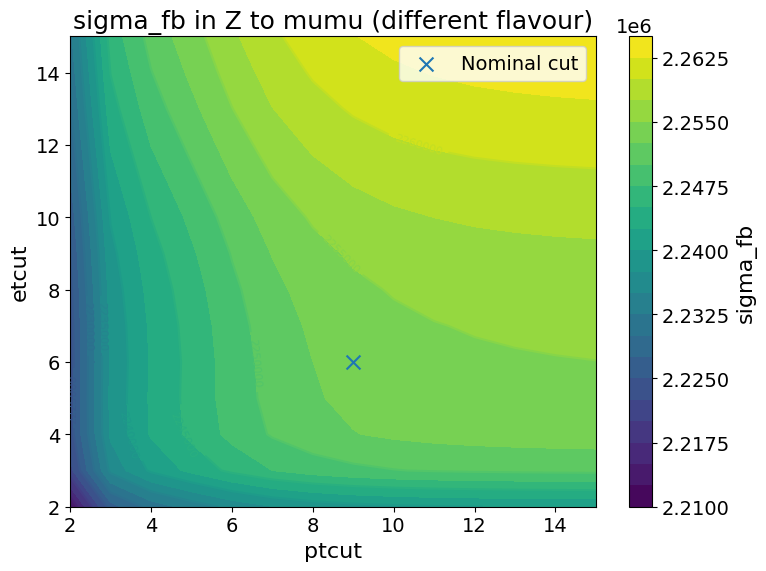

In [175]:
plot_df = df_iso.copy()

# 做成 2D grid：行是 etcut，列是 ptcut
pivot_sigma = plot_df.pivot_table(
    index="etcut",
    columns="ptcut",
    values="sigma_fb",
    aggfunc="mean"
)

# 取出网格
x = pivot_sigma.columns.values   # ptcut
y = pivot_sigma.index.values     # etcut
X, Y = np.meshgrid(x, y)
Z = pivot_sigma.values           # sigma_fb

plt.figure(figsize=(8, 6))

# filled contour
contour = plt.contourf(X, Y, Z, levels=20)
plt.colorbar(contour, label="sigma_fb")

# contour lines
lines = plt.contour(X, Y, Z, levels=10)
plt.clabel(lines, inline=True, fontsize=8)

# 标出 nominal point
plt.scatter(NOMINAL_PTCUT_MU, NOMINAL_ETCUT_MU, marker="x", s=100, label="Nominal cut")

plt.xlabel("ptcut")
plt.ylabel("etcut")
plt.title(f"sigma_fb in Z to mumu ({"different flavour"})")
plt.legend()
plt.tight_layout()
plt.show()

The graph is very interesting that it seems tighter cuts cut more signals! We want to investigate it by viewing what is happening in the mass distribution within the range between two cuts.

In [101]:
def select_gained_et_region(plot_dict, nom_et, loose_et):
    out = {}

    for k, arr in plot_dict.items():
        mask_nom = (
            (arr["lep_topoetcone20"][:, 0] < nom_et) &
            (arr["lep_topoetcone20"][:, 1] < nom_et))

        mask_loose = (
            (arr["lep_topoetcone20"][:, 0] < loose_et) &
            (arr["lep_topoetcone20"][:, 1] < loose_et) 
        )

        mask_gained = mask_loose & (~mask_nom)
        out[k] = arr[mask_gained]

    return out

In [102]:
def select_gained_region(plot_dict, nom_pt, nom_et, loose_pt, loose_et):
    out = {}

    for k, arr in plot_dict.items():
        mask_nom = (
            (arr["lep_ptvarcone30"][:, 0] < nom_pt) &
            (arr["lep_ptvarcone30"][:, 1] < nom_pt) &
            (arr["lep_topoetcone20"][:, 0] < nom_et) &
            (arr["lep_topoetcone20"][:, 1] < nom_et)
        )

        mask_loose = (
            (arr["lep_ptvarcone30"][:, 0] < loose_pt) &
            (arr["lep_ptvarcone30"][:, 1] < loose_pt) &
            (arr["lep_topoetcone20"][:, 0] < loose_et) &
            (arr["lep_topoetcone20"][:, 1] < loose_et)
        )

        mask_gained = mask_loose & (~mask_nom)
        out[k] = arr[mask_gained]

    return out

In [103]:
nom_pt = 9
nom_et = 6

loose_pt = 15
loose_et = 15

plot_dict_mu_SS_gained = select_gained_et_region(
    plot_dict_mu_SS_mapped,
    nom_et=nom_et,
    loose_et=loose_et
)

for k, arr in plot_dict_mu_SS_gained.items():
    print(k, len(arr))

plot_dict_mu_OS_gained = select_gained_et_region(
    plot_dict_mu_OS_mapped,
    nom_et=nom_et,
    loose_et=loose_et
)

for k, arr in plot_dict_mu_OS_gained.items():
    print(k, len(arr))

Data 2132
Signal Zmumu 69
Background Ztautau 15
Background ttbar 313
Background Wmunu 266
Signal m10_40_Zmumu 6
Data 509760
Signal Zmumu 868138
Background Ztautau 1232
Background ttbar 7556
Background Wmunu 1086
Signal m10_40_Zmumu 30729


Elapsed time = 0.7s


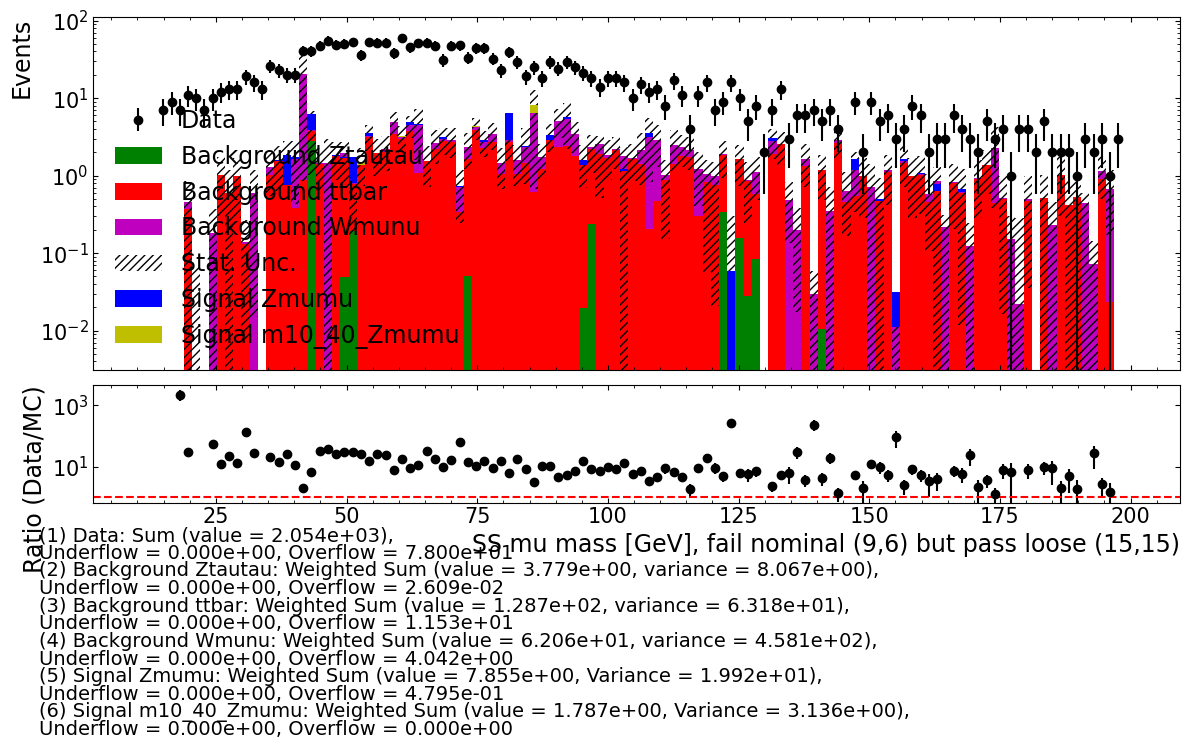

In [104]:
color_list = ['k','b','g','r','m','y']

fig_mu_ss_gained, hists_mu_ss_gained = plot_stacked_hist(
    plot_dict_mu_SS_gained,
    'mass',
    color_list,
    num_bins=120,
    xmin=11,
    xmax=200,
    x_label=rf'SS mu mass [GeV], fail nominal ({nom_pt},{nom_et}) but pass loose ({loose_pt},{loose_et})',
    logy=True,
    show_text=True,
    residual_plot=True,
    save_fig=False
)

Elapsed time = 0.8s


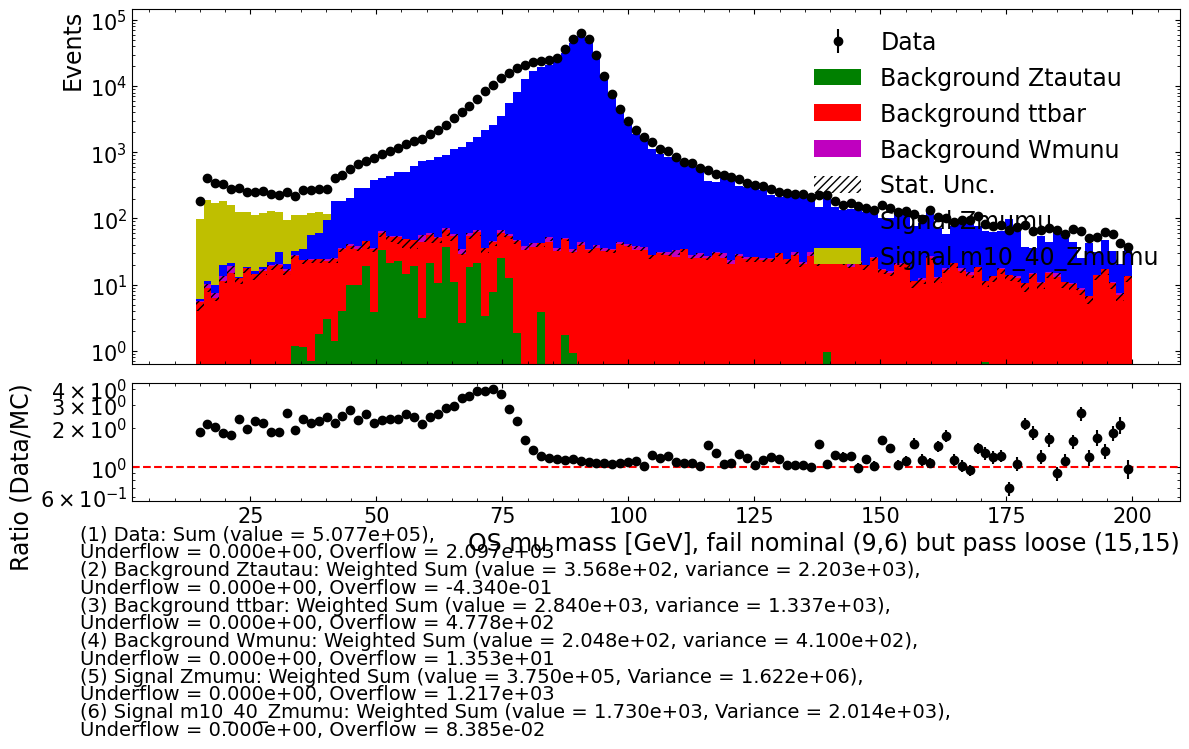

In [105]:
color_list = ['k','b','g','r','m','y']

fig_mu_os_gained, hists_mu_os_gained = plot_stacked_hist(
    plot_dict_mu_OS_gained,
    'mass',
    color_list,
    num_bins=120,
    xmin=11,
    xmax=200,
    x_label=rf'OS mu mass [GeV], fail nominal ({nom_pt},{nom_et}) but pass loose ({loose_pt},{loose_et})',
    logy=True,
    show_text=True,
    residual_plot=True,
    save_fig=False
)

In [106]:
'''#effect of order of iso cuts and wrong sign/wrong flavour
mlow0, mhigh0 = NOMINAL_MASS_WINDOW

df_order = df_scan[
    (df_scan["mlow"] == mlow0) &
    (df_scan["mhigh"] == mhigh0) &
    (df_scan["ptcut"] == NOMINAL_PTCUT_MU) &
    (df_scan["etcut"] == NOMINAL_ETCUT_MU) &
    (df_scan["mode"] == NOMINAL_MODE)
].copy()

sigma_nom_order, df_order_var = systematic_from_variation(
    df_order,
    nominal_mask=(df_order["order"] == NOMINAL_ORDER)
)

order_sys = max_systematic(df_order_var)

print("Nominal sigma =", sigma_nom_order, "fb")
print("Order systematic =", order_sys)

df_order_var.sort_values("abs_delta_sigma", ascending=False)[[
    "order", "sigma_fb", "delta_sigma", "abs_delta_sigma",
    "rel_delta_percent", "abs_rel_delta_percent",
    "delta_df", "delta_ss"
]]'''

'#effect of order of iso cuts and wrong sign/wrong flavour\nmlow0, mhigh0 = NOMINAL_MASS_WINDOW\n\ndf_order = df_scan[\n    (df_scan["mlow"] == mlow0) &\n    (df_scan["mhigh"] == mhigh0) &\n    (df_scan["ptcut"] == NOMINAL_PTCUT_MU) &\n    (df_scan["etcut"] == NOMINAL_ETCUT_MU) &\n    (df_scan["mode"] == NOMINAL_MODE)\n].copy()\n\nsigma_nom_order, df_order_var = systematic_from_variation(\n    df_order,\n    nominal_mask=(df_order["order"] == NOMINAL_ORDER)\n)\n\norder_sys = max_systematic(df_order_var)\n\nprint("Nominal sigma =", sigma_nom_order, "fb")\nprint("Order systematic =", order_sys)\n\ndf_order_var.sort_values("abs_delta_sigma", ascending=False)[[\n    "order", "sigma_fb", "delta_sigma", "abs_delta_sigma",\n    "rel_delta_percent", "abs_rel_delta_percent",\n    "delta_df", "delta_ss"\n]]'

In [107]:
'''summary_rows = [
    {
        "source": "statistical",
        "unc_fb": float(df_nominal["unc_stat_fb"].iloc[0])
    },
    {
        "source": "luminosity",
        "unc_fb": float(df_nominal["unc_lumi_fb"].iloc[0])
    },
    {
        "source": "mass window",
        "unc_fb": mass_sys["sys_abs_fb"]
    },
    {
        "source": "isolation cut",
        "unc_fb": iso_sys["sys_abs_fb"]
    },
    {
        "source": "correction mode",
        "unc_fb": mode_sys["sys_abs_fb"]
    },
    {
        "source": "order effect",
        "unc_fb": order_sys["sys_abs_fb"]
    },
]

df_unc_summary = pd.DataFrame(summary_rows)
df_unc_summary'''

'summary_rows = [\n    {\n        "source": "statistical",\n        "unc_fb": float(df_nominal["unc_stat_fb"].iloc[0])\n    },\n    {\n        "source": "luminosity",\n        "unc_fb": float(df_nominal["unc_lumi_fb"].iloc[0])\n    },\n    {\n        "source": "mass window",\n        "unc_fb": mass_sys["sys_abs_fb"]\n    },\n    {\n        "source": "isolation cut",\n        "unc_fb": iso_sys["sys_abs_fb"]\n    },\n    {\n        "source": "correction mode",\n        "unc_fb": mode_sys["sys_abs_fb"]\n    },\n    {\n        "source": "order effect",\n        "unc_fb": order_sys["sys_abs_fb"]\n    },\n]\n\ndf_unc_summary = pd.DataFrame(summary_rows)\ndf_unc_summary'

In [108]:
'''sys_only = df_unc_summary[
    df_unc_summary["source"].isin(["mass window", "isolation cut", "correction mode", "order effect"])
]["unc_fb"].values

combined_sys = float(np.sqrt(np.sum(sys_only**2)))
combined_stat = float(df_unc_summary[df_unc_summary["source"] == "statistical"]["unc_fb"].iloc[0])
combined_lumi = float(df_unc_summary[df_unc_summary["source"] == "luminosity"]["unc_fb"].iloc[0])

print("Combined systematic =", combined_sys, "fb")
print("Statistical =", combined_stat, "fb")
print("Luminosity =", combined_lumi, "fb")'''

'sys_only = df_unc_summary[\n    df_unc_summary["source"].isin(["mass window", "isolation cut", "correction mode", "order effect"])\n]["unc_fb"].values\n\ncombined_sys = float(np.sqrt(np.sum(sys_only**2)))\ncombined_stat = float(df_unc_summary[df_unc_summary["source"] == "statistical"]["unc_fb"].iloc[0])\ncombined_lumi = float(df_unc_summary[df_unc_summary["source"] == "luminosity"]["unc_fb"].iloc[0])\n\nprint("Combined systematic =", combined_sys, "fb")\nprint("Statistical =", combined_stat, "fb")\nprint("Luminosity =", combined_lumi, "fb")'

In [109]:
df_nom_modes = df_scan[
    (df_scan["mlow"] == mlow0) &
    (df_scan["mhigh"] == mhigh0) &
    (df_scan["ptcut"] == NOMINAL_PTCUT_MU) &
    (df_scan["etcut"] == NOMINAL_ETCUT_MU)
].copy()

display(
    df_nom_modes[[
        "mode", "sigma_fb", "unc_stat_fb", "unc_lumi_fb",
        "delta_df", "delta_ss", "N_selected", "N_background", "eff"
    ]].sort_values("mode")
)

,mode,sigma_fb,unc_stat_fb,unc_lumi_fb,delta_df,delta_ss,N_selected,N_background,eff
409,df,2.253447e+06,459.892510,38308.597810,18778.243262,NaN,2.422093e+07,70773.228401,0.292814
411,df+ss,2.253240e+06,459.871557,38305.086757,18778.243262,2213.406399,2.421872e+07,70773.228401,0.292814
408,none,2.255226e+06,460.255566,38338.840056,NaN,NaN,2.422093e+07,70773.228401,0.292583
410,ss,2.255019e+06,460.234597,38335.326231,NaN,2213.406399,2.421872e+07,70773.228401,0.292583


# Cross-section for ee

Elapsed time = 1.2s


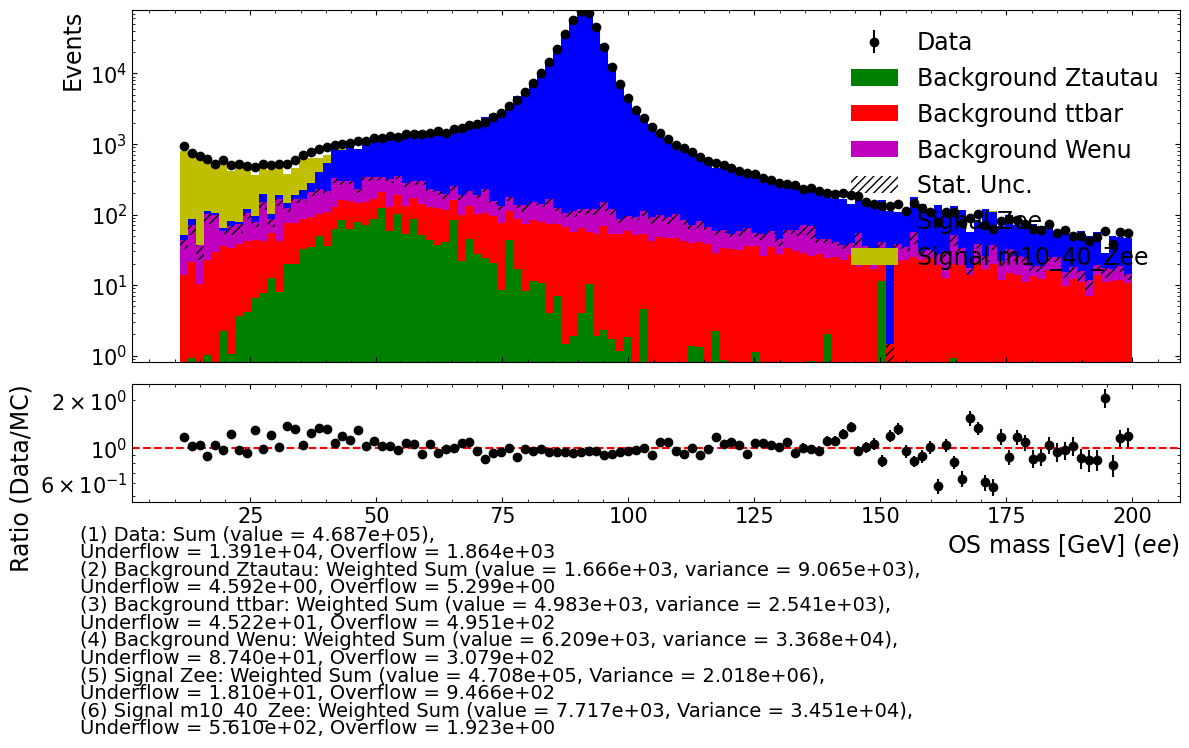

Elapsed time = 0.5s


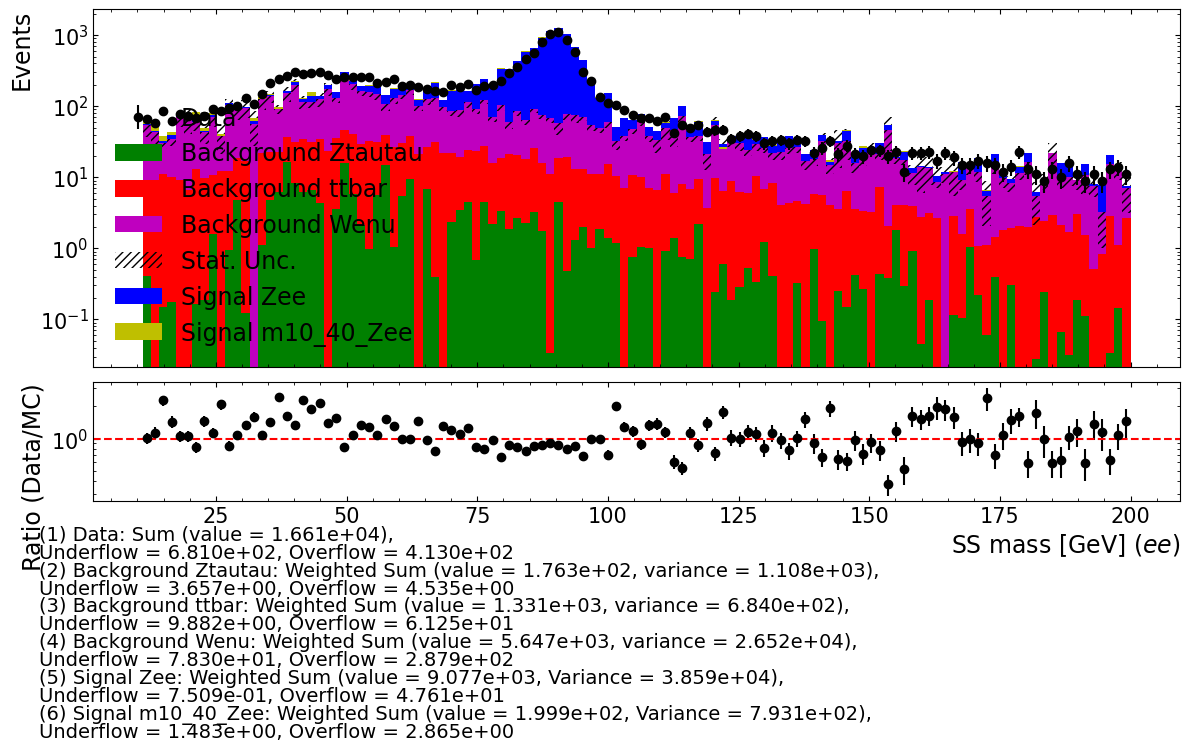

In [110]:
color_list = ['k','b','g','r','m','y']

fig_ee_os, hists_ee_os = plot_stacked_hist(
    plot_dict_ee_OS_mapped,
    'mass',
    color_list,
    num_bins=120,
    xmin=11,
    xmax=200,
    x_label=rf'OS mass [GeV] ($ee$)',
    logy=True,
    show_text=True,
    residual_plot=True,
    save_fig=False
)

fig_ee_ss, hists_ee_ss = plot_stacked_hist(
    plot_dict_ee_SS_mapped,
    'mass',
    color_list,
    num_bins=120,
    xmin=11,
    xmax=200,
    x_label=rf'SS mass [GeV] ($ee$)',
    logy=True,
    show_text=True,
    residual_plot=True,
    save_fig=False
)

In [111]:
# wrong-sign residual for Zee
ee_ss_info = compute_ss_delta(
    plot_dict_ee_OS_cut,
    plot_dict_ee_SS_cut,
    ptcut=None,
    etcut=None,
    mlow=MLOW,
    mhigh=MHIGH
)

# wrong-flavour residual for Zee
ee_df_info = compute_df_delta(
    plot_dict_mue_OS_cut_for_ee,
    ptcut=None,
    etcut=None,
    mlow=MLOW,
    mhigh=MHIGH
)

print("=== Zee wrong-sign info ===")
print(ee_ss_info)

print("\n=== Zee different-flavour info ===")
print(ee_df_info)

=== Zee wrong-sign info ===
{'os_data': 418832, 'ss_data': 7561, 'ss_mc': 866.744846636858, 'delta_ss': 6694.255153363142, 'corrected_os_data': 412137.74484663684}

=== Zee different-flavour info ===
{'mue_data': 184868, 'mue_mc': 148226.52202969516, 'delta_df': 18320.73898515242}


In [112]:
EE_SIGNAL_KEY = "Signal Zee"
PRODUCED_ZEE = produced_event_count("Zee", LUMI_FB)

The total number of produced events (sum of weights) for Monte Carlo data set Zee and luminosity 36.6 inverse femtobarns is 81299580


In [113]:
def run_zee_pipeline_light(
    plot_dict_ee_os_base,
    plot_dict_ee_ss_base,
    plot_dict_mue_os_base,
    lumi_fb=LUMI_FB,
    ptcut=None,
    etcut=None,
    mlow=MASS_LOW_NOM,
    mhigh=MASS_HIGH_NOM,
    apply_df=False,
    apply_ss=False,
    order=("iso", "df", "ss"),
):
    ee_os = plot_dict_ee_os_base
    ee_ss = plot_dict_ee_ss_base
    mue_os = plot_dict_mue_os_base

    iso_already_applied = False
    df_info = None
    ss_info = None

    def current_cuts():
        if iso_already_applied:
            return None, None
        else:
            return ptcut, etcut

    for step in order:
        if step == "iso":
            ee_os = apply_iso_to_plot_dict(ee_os, ptcut=ptcut, etcut=etcut)
            ee_ss = apply_iso_to_plot_dict(ee_ss, ptcut=ptcut, etcut=etcut)
            mue_os = apply_iso_to_plot_dict(mue_os, ptcut=ptcut, etcut=etcut)
            iso_already_applied = True

        elif step == "df" and apply_df:
            cpt, cet = current_cuts()
            df_info = compute_df_delta(
                mue_os,
                ptcut=cpt, etcut=cet,
                mlow=mlow, mhigh=mhigh
            )

        elif step == "ss" and apply_ss:
            cpt, cet = current_cuts()
            ss_info = compute_ss_delta(
                ee_os, ee_ss,
                ptcut=cpt, etcut=cet,
                mlow=mlow, mhigh=mhigh
            )

    cpt, cet = current_cuts()

    n_selected_raw = data_count_in_mass(
        ee_os["Data"],
        ptcut=cpt, etcut=cet,
        mlow=mlow, mhigh=mhigh
    )

    if apply_ss and ss_info is not None:
        n_selected = ss_info["corrected_os_data"]
    else:
        n_selected = n_selected_raw

    n_background = total_background_yield_in_mass(
        ee_os,
        ptcut=cpt, etcut=cet,
        mlow=mlow, mhigh=mhigh
    )

    sig_yield_nom = weighted_yield_in_mass(
        ee_os["Signal Zee"],
        ptcut=cpt, etcut=cet,
        mlow=mlow, mhigh=mhigh
    )

    if apply_df and df_info is not None:
        sig_yield = sig_yield_nom + df_info["delta_df"]
    else:
        sig_yield = sig_yield_nom

    eff = sig_yield / PRODUCED_ZEE

    sigma_info = sigma_from_components(
        n_selected=n_selected,
        n_background=n_background,
        eff=eff,
        lumi_fb=lumi_fb
    )

    return {
        "ptcut": ptcut,
        "etcut": etcut,
        "mlow": mlow,
        "mhigh": mhigh,
        "order": " -> ".join(order),
        "apply_df": apply_df,
        "apply_ss": apply_ss,
        "df_info": df_info,
        "ss_info": ss_info,
        "N_selected": n_selected,
        "N_background": n_background,
        "eff": eff,
        **sigma_info
    }

In [114]:
def scan_zee_systematics(
    plot_dict_ee_os_base,
    plot_dict_ee_ss_base,
    plot_dict_mue_os_base,
    lumi_fb=LUMI_FB,
    ptcuts=tuple(range(2, 16)),
    etcuts=tuple(range(2, 16)),
    mass_windows=((66, 116),),
    correction_modes=("none", "df", "ss", "df+ss"),
    orders=(
        ("iso", "df", "ss"),
        ("df", "iso", "ss"),
        ("ss", "iso", "df"),
        ("df", "ss", "iso"),
    ),
):
    rows = []

    total_steps = (
        len(mass_windows) *
        len(ptcuts) *
        len(etcuts) *
        len(correction_modes) *
        len(orders)
    )

    with tqdm(total=total_steps, desc="Scanning Zee systematics") as pbar:
        for (mlow, mhigh) in mass_windows:
            for ptcut in ptcuts:
                for etcut in etcuts:
                    flow = event_flow_counts(
                        plot_dict_ee_os_base,
                        ptcut=ptcut,
                        etcut=etcut,
                        mlow=mlow,
                        mhigh=mhigh
                    )

                    for mode in correction_modes:
                        apply_df = mode in ("df", "df+ss")
                        apply_ss = mode in ("ss", "df+ss")

                        for order in orders:
                            result = run_zee_pipeline_light(
                                plot_dict_ee_os_base=plot_dict_ee_os_base,
                                plot_dict_ee_ss_base=plot_dict_ee_ss_base,
                                plot_dict_mue_os_base=plot_dict_mue_os_base,
                                lumi_fb=lumi_fb,
                                ptcut=ptcut,
                                etcut=etcut,
                                mlow=mlow,
                                mhigh=mhigh,
                                apply_df=apply_df,
                                apply_ss=apply_ss,
                                order=order,
                            )

                            rows.append({
                                "mlow": mlow,
                                "mhigh": mhigh,
                                "ptcut": ptcut,
                                "etcut": etcut,
                                "mode": mode,
                                "order": result["order"],
                                "sigma_fb": result["sigma_fb"],
                                "unc_stat_fb": result["unc_stat_fb"],
                                "unc_lumi_fb": result["unc_lumi_fb"],
                                "N_selected": result["N_selected"],
                                "N_background": result["N_background"],
                                "eff": result["eff"],
                                "delta_df": None if result["df_info"] is None else result["df_info"]["delta_df"],
                                "delta_ss": None if result["ss_info"] is None else result["ss_info"]["delta_ss"],
                                "data_n_total": flow["Data"]["n_total"],
                                "data_n_after_mass": flow["Data"]["n_after_mass"],
                                "data_n_after_iso": flow["Data"]["n_after_iso"],
                                "data_n_after_mass_and_iso": flow["Data"]["n_after_mass_and_iso"],
                            })

                            pbar.update(1)

    return pd.DataFrame(rows)

In [115]:
PTCUTS_EE = tuple(range(2, 14))   # 2,3,...,13
ETCUTS_EE = tuple(range(2, 14))   # 2,3,...,13

MASS_WINDOWS_EE = (
    (50, 110),
    (55, 116),
    (60, 120),
    (66, 116),
    (70, 110),
    (75, 105),
    (80, 100),
)

CORRECTION_MODES_EE = ("none", "df", "ss", "df+ss")

ORDERS_EE = (
    ("iso", "df", "ss"),
    ("df", "iso", "ss"),
    ("ss", "iso", "df"),
    ("df", "ss", "iso"),
)

In [116]:
"""df_scan_ee_all = scan_zee_systematics(
    plot_dict_ee_os_base=plot_dict_ee_OS_mapped,
    plot_dict_ee_ss_base=plot_dict_ee_SS_mapped,
    plot_dict_mue_os_base=plot_dict_mue_OS_mapped,
    lumi_fb=LUMI_FB,
    ptcuts=PTCUTS_EE,
    etcuts=ETCUTS_EE,
    mass_windows=MASS_WINDOWS_EE,
    correction_modes=CORRECTION_MODES_EE,
    orders=ORDERS_EE,
)

print(df_scan_ee_all.shape)
display(df_scan_ee_all.head())"""

'df_scan_ee_all = scan_zee_systematics(\n    plot_dict_ee_os_base=plot_dict_ee_OS_mapped,\n    plot_dict_ee_ss_base=plot_dict_ee_SS_mapped,\n    plot_dict_mue_os_base=plot_dict_mue_OS_mapped,\n    lumi_fb=LUMI_FB,\n    ptcuts=PTCUTS_EE,\n    etcuts=ETCUTS_EE,\n    mass_windows=MASS_WINDOWS_EE,\n    correction_modes=CORRECTION_MODES_EE,\n    orders=ORDERS_EE,\n)\n\nprint(df_scan_ee_all.shape)\ndisplay(df_scan_ee_all.head())'

In [117]:
'''df_scan_ee_all.to_pickle("df_scan_ee_all.pkl")
print("saved: df_scan_ee_all.pkl")'''

'df_scan_ee_all.to_pickle("df_scan_ee_all.pkl")\nprint("saved: df_scan_ee_all.pkl")'

In [118]:
df_scan_ee_all = pd.read_pickle("df_scan_ee_all.pkl")

In [119]:
# ============================================
# Zee: mode comparison at nominal mass window
# ============================================
NOMINAL_MASS_WINDOW_EE = (66, 116)
NOMINAL_PTCUT_EE = 8
NOMINAL_ETCUT_EE = 6
NOMINAL_MODE_EE = "df"
NOMINAL_ORDER_EE = "iso -> df -> ss"
mlow_ee, mhigh_ee = NOMINAL_MASS_WINDOW_EE

mlow_ee, mhigh_ee = NOMINAL_MASS_WINDOW_EE

df_nom_modes_ee = df_scan_ee_all[
    (df_scan_ee_all["mlow"] == mlow_ee) &
    (df_scan_ee_all["mhigh"] == mhigh_ee) &
    (df_scan_ee_all["ptcut"] == NOMINAL_PTCUT_EE) &
    (df_scan_ee_all["etcut"] == NOMINAL_ETCUT_EE) &
    (df_scan_ee_all["order"] == NOMINAL_ORDER_EE)
].copy()

sigma_nom_modes_ee, df_nom_modes_var_ee = systematic_from_variation(
    df_nom_modes_ee,
    nominal_mask=(df_nom_modes_ee["mode"] == NOMINAL_MODE_EE)
)

display(
    df_nom_modes_var_ee[[
        "mode", "sigma_fb", "delta_sigma", "abs_delta_sigma",
        "rel_delta_percent", "abs_rel_delta_percent",
        "delta_df", "delta_ss"
    ]].sort_values("mode")
)

,mode,sigma_fb,delta_sigma,abs_delta_sigma,rel_delta_percent,abs_rel_delta_percent,delta_df,delta_ss
8132,df,2.017901e+06,0.000000,0.000000,0.000000,0.000000,18320.738985,NaN
8140,df+ss,1.985489e+06,-32411.831587,32411.831587,-1.606216,1.606216,18320.738985,6685.219618
8128,none,2.101952e+06,84051.699900,84051.699900,4.165304,4.165304,NaN,NaN
8136,ss,2.068190e+06,50289.816841,50289.816841,2.492185,2.492185,NaN,6685.219618


In [120]:
# ============================================
# Zee: mass window comparison
# ============================================

df_mass_ee = df_scan_ee_all[
    (df_scan_ee_all["mode"] == NOMINAL_MODE_EE) &
    (df_scan_ee_all["ptcut"] == NOMINAL_PTCUT_EE) &
    (df_scan_ee_all["etcut"] == NOMINAL_ETCUT_EE) &
    (df_scan_ee_all["order"] == NOMINAL_ORDER_EE)
].copy()

sigma_nom_mass_ee, df_mass_var_ee = systematic_from_variation(
    df_mass_ee,
    nominal_mask=(
        (df_mass_ee["mlow"] == mlow_ee) &
        (df_mass_ee["mhigh"] == mhigh_ee)
    )
)

display(
    df_mass_var_ee[[
        "mlow", "mhigh",
        "sigma_fb", "delta_sigma", "rel_delta_percent",
        "data_n_after_mass", "data_n_after_mass_and_iso"
    ]].sort_values(["mlow", "mhigh"])
)

,mlow,mhigh,sigma_fb,delta_sigma,rel_delta_percent,data_n_after_mass,data_n_after_mass_and_iso
1220,50,110,1.996467e+06,-21433.823579,-1.062184,439014,427998
3524,55,116,1.999215e+06,-18685.035698,-0.925964,437893,427429
5828,60,120,2.004493e+06,-13407.452139,-0.664426,434872,424990
8132,66,116,2.017901e+06,0.000000,0.000000,427808,418832
10436,70,110,2.029359e+06,11458.069894,0.567821,420455,412250
12740,75,105,2.042924e+06,25023.851610,1.240093,409197,401953
15044,80,100,2.059245e+06,41344.797256,2.048902,387687,381615


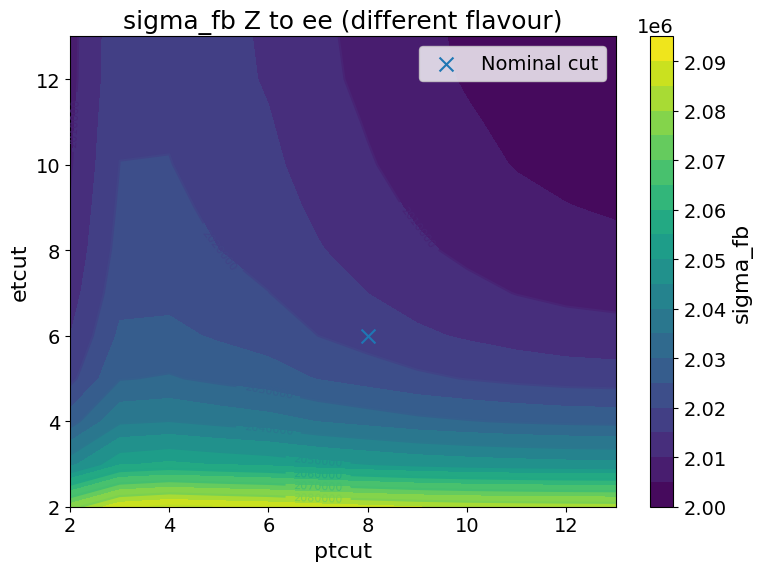

In [178]:
mlow_ee, mhigh_ee = 66, 116
mode_ee = "df"
order_ee = "iso -> df -> ss"

df_plot_ee = df_scan_ee_all[
    (df_scan_ee_all["mlow"] == mlow_ee) &
    (df_scan_ee_all["mhigh"] == mhigh_ee) &
    (df_scan_ee_all["mode"] == mode_ee)
].copy()

pivot_sigma = df_plot_ee.pivot_table(
    index="etcut",
    columns="ptcut",
    values="sigma_fb",
    aggfunc="mean"
)

x = pivot_sigma.columns.values
y = pivot_sigma.index.values
X, Y = np.meshgrid(x, y)
Z = pivot_sigma.values

plt.figure(figsize=(8, 6))

contour = plt.contourf(X, Y, Z, levels=20)
plt.colorbar(contour, label="sigma_fb")

lines = plt.contour(X, Y, Z, levels=10)
plt.clabel(lines, inline=True, fontsize=8)
plt.scatter(NOMINAL_PTCUT_EE, NOMINAL_ETCUT_EE, marker="x", s=100, label="Nominal cut")
plt.legend()

plt.xlabel("ptcut")
plt.ylabel("etcut")
plt.title(f"sigma_fb Z to ee (different flavour)")
plt.tight_layout()
plt.show()

In [122]:
# -------------------------
# nominal choices for Zee
# -------------------------
NOMINAL_MASS_WINDOW_EE = (66, 116)
NOMINAL_PTCUT_EE = 8
NOMINAL_ETCUT_EE = 6
NOMINAL_MODE_EE = "df"
NOMINAL_ORDER_EE = "iso -> df -> ss"

mlow_ee, mhigh_ee = NOMINAL_MASS_WINDOW_EE

In [123]:
df_iso_ee = df_scan_ee_all[
    (df_scan_ee_all["mlow"] == mlow_ee) &
    (df_scan_ee_all["mhigh"] == mhigh_ee) &
    (df_scan_ee_all["mode"] == NOMINAL_MODE_EE) &
    (df_scan_ee_all["order"] == NOMINAL_ORDER_EE)
].copy()

print(df_iso_ee.shape)
display(df_iso_ee.head())

(144, 18)


,mlow,mhigh,ptcut,etcut,mode,order,sigma_fb,unc_stat_fb,unc_lumi_fb,N_selected,N_background,eff,delta_df,delta_ss,data_n_total,data_n_after_mass,data_n_after_iso,data_n_after_mass_and_iso
6916,66,116,2,2,df,iso -> df -> ss,2.077579e+06,3627.976568,35318.841328,332282.0,1457.910721,0.004351,11430.561303,NaN,484500,427808,362129,332282
6932,66,116,2,3,df,iso -> df -> ss,2.043308e+06,3367.965066,34736.235841,373154.0,1704.409255,0.004967,12982.297158,NaN,484500,427808,407047,373154
6948,66,116,2,4,df,iso -> df -> ss,2.027764e+06,3271.739657,34471.982743,389593.0,1832.741905,0.005225,13510.886428,NaN,484500,427808,425392,389593
6964,66,116,2,5,df,iso -> df -> ss,2.018484e+06,3229.320937,34314.233726,396306.0,1885.081761,0.005339,13808.272924,NaN,484500,427808,433075,396306
6980,66,116,2,6,df,iso -> df -> ss,2.014976e+06,3211.627471,34254.594359,399363.0,1922.893708,0.005389,13977.044341,NaN,484500,427808,436670,399363


In [124]:
sigma_nom_iso_ee, df_iso_var_ee = systematic_from_variation(
    df_iso_ee,
    nominal_mask=(
        (df_iso_ee["ptcut"] == NOMINAL_PTCUT_EE) &
        (df_iso_ee["etcut"] == NOMINAL_ETCUT_EE)
    )
)

iso_sys_ee = max_systematic(df_iso_var_ee)

print("Nominal Zee sigma =", sigma_nom_iso_ee, "fb")
print("Zee isolation systematic =", iso_sys_ee)

Nominal Zee sigma = 2017900.5008612836 fb
Zee isolation systematic = {'sys_abs_fb': np.float64(73035.19997471804), 'sys_rel_percent': np.float64(3.6193657687058916)}


In [125]:
display(
    df_iso_var_ee.sort_values("abs_delta_sigma", ascending=False)[[
        "ptcut", "etcut",
        "sigma_fb", "delta_sigma", "abs_delta_sigma",
        "rel_delta_percent", "abs_rel_delta_percent",
        "data_n_after_iso", "data_n_after_mass_and_iso"
    ]]
)

,ptcut,etcut,sigma_fb,delta_sigma,abs_delta_sigma,rel_delta_percent,abs_rel_delta_percent,data_n_after_iso,data_n_after_mass_and_iso
7300,4,2,2.090936e+06,73035.199975,73035.199975,3.619366,3.619366,375156,343598
7492,5,2,2.089861e+06,71960.695843,71960.695843,3.566117,3.566117,376860,344891
7684,6,2,2.088894e+06,70993.653050,70993.653050,3.518194,3.518194,377848,345600
7108,3,2,2.088561e+06,70660.160637,70660.160637,3.501667,3.501667,371448,340459
7876,7,2,2.087383e+06,69482.313752,69482.313752,3.443297,3.443297,378438,345994
...,...,...,...,...,...,...,...,...,...
9076,13,5,2.017432e+06,-468.986860,468.986860,-0.023241,0.023241,458730,416310
7780,6,8,2.018301e+06,400.662738,400.662738,0.019855,0.019855,462699,420423
8884,12,5,2.017793e+06,-107.867000,107.867000,-0.005346,0.005346,458490,416201
7620,5,10,2.017972e+06,71.375794,71.375794,0.003537,0.003537,462354,420291


In [126]:
print(f"Nominal Zee sigma = {sigma_nom_iso_ee:.3f} fb")
print(f"Isolation systematic = ±{iso_sys_ee['sys_abs_fb']:.3f} fb")
print(f"Relative isolation systematic = ±{iso_sys_ee['sys_rel_percent']:.3f} %")

Nominal Zee sigma = 2017900.501 fb
Isolation systematic = ±73035.200 fb
Relative isolation systematic = ±3.619 %


In [127]:
def select_gained_pt_region(plot_dict, nom_pt, loose_pt):
    out = {}

    for k, arr in plot_dict.items():
        mask_nom = (
            (arr["lep_ptvarcone30"][:, 0] < nom_pt) &
            (arr["lep_ptvarcone30"][:, 1] < nom_pt) )

        mask_loose = (
            (arr["lep_ptvarcone30"][:, 0] < loose_pt) &
            (arr["lep_ptvarcone30"][:, 1] < loose_pt) 
        )

        mask_gained = mask_loose & (~mask_nom)
        out[k] = arr[mask_gained]

    return out

In [128]:
nom_pt = 9
nom_et = 6

loose_pt = 15
loose_et = 15

plot_dict_ee_SS_gained = select_gained_pt_region(
    plot_dict_ee_SS_mapped,
    nom_pt=nom_pt,
    loose_pt=loose_pt
)

for k, arr in plot_dict_ee_SS_gained.items():
    print(k, len(arr))

plot_dict_ee_OS_gained = select_gained_pt_region(
    plot_dict_ee_OS_mapped,
    nom_pt=nom_pt,
    loose_pt=loose_pt
)

for k, arr in plot_dict_ee_OS_gained.items():
    print(k, len(arr))

Data 1638
Signal Zee 255
Background Ztautau 252
Background ttbar 502
Background Wenu 5620
Signal m10_40_Zee 97
Data 3741
Signal Zee 3342
Background Ztautau 269
Background ttbar 591
Background Wenu 5790
Signal m10_40_Zee 354


Elapsed time = 0.5s


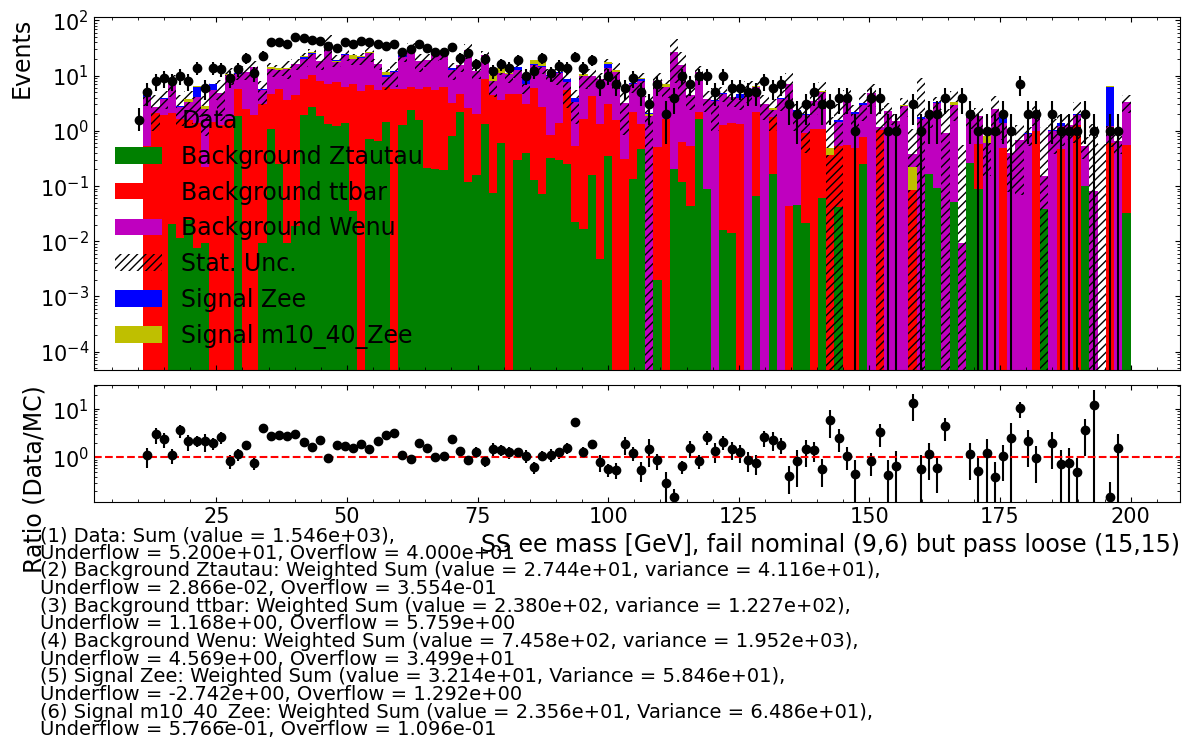

In [129]:
color_list = ['k','b','g','r','m','y']

fig_ee_ss_gained, hists_ee_ss_gained = plot_stacked_hist(
    plot_dict_ee_SS_gained,
    'mass',
    color_list,
    num_bins=120,
    xmin=11,
    xmax=200,
    x_label=rf'SS ee mass [GeV], fail nominal ({nom_pt},{nom_et}) but pass loose ({loose_pt},{loose_et})',
    logy=True,
    show_text=True,
    residual_plot=True,
    save_fig=False
)

Elapsed time = 0.6s


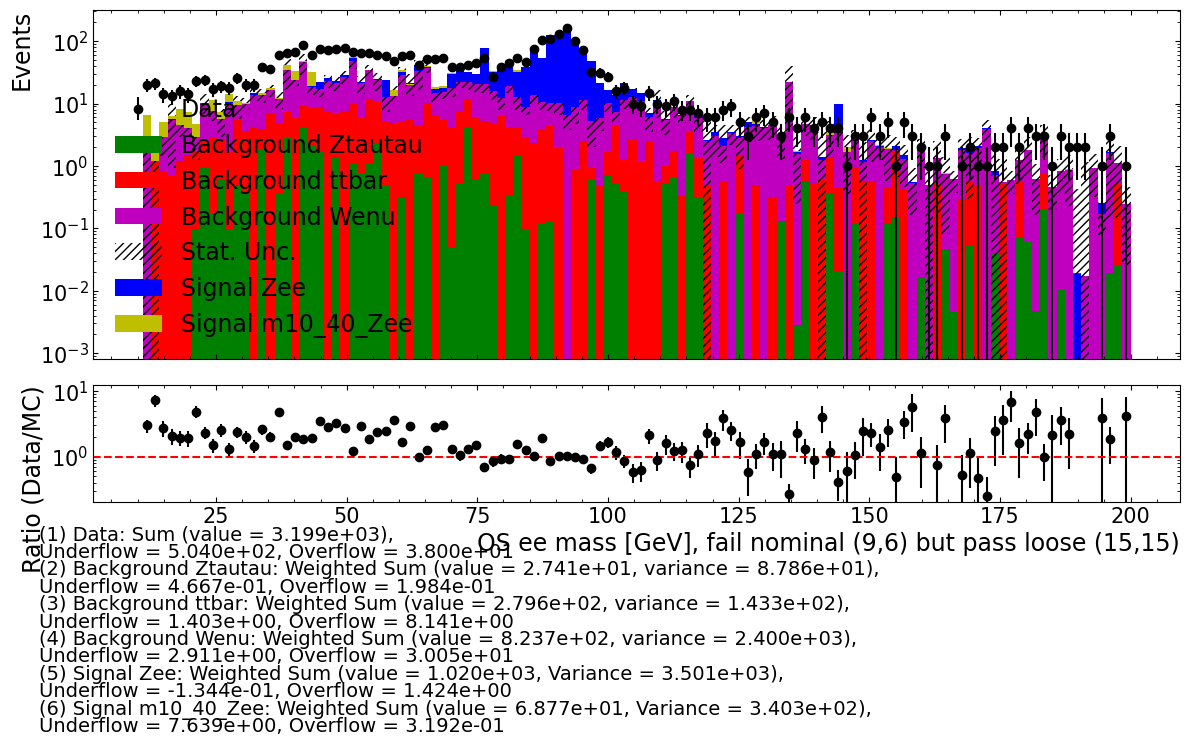

In [130]:
color_list = ['k','b','g','r','m','y']

fig_ee_os_gained, hists_ee_os_gained = plot_stacked_hist(
    plot_dict_ee_OS_gained,
    'mass',
    color_list,
    num_bins=120,
    xmin=11,
    xmax=200,
    x_label=rf'OS ee mass [GeV], fail nominal ({nom_pt},{nom_et}) but pass loose ({loose_pt},{loose_et})',
    logy=True,
    show_text=True,
    residual_plot=True,
    save_fig=False
)

I am going to investigate in Zmumu process, whether the process that photon radiation taking away the energy from the muon is the main reason of the gap between monte carlo and raw data in the low mass tail.

In [131]:
import numpy as np
import awkward as ak

def corrected_mass_from_dpt(pt, eta, phi, energy, dpt):
    pt_corr = pt + dpt
    energy_corr = energy + dpt * np.cosh(eta)

    px = pt_corr * np.cos(phi)
    py = pt_corr * np.sin(phi)
    pz = pt_corr * np.sinh(eta)

    total_energy = np.sum(energy_corr, axis=1)
    total_px = np.sum(px, axis=1)
    total_py = np.sum(py, axis=1)
    total_pz = np.sum(pz, axis=1)

    mass_squared = total_energy**2 - total_px**2 - total_py**2 - total_pz**2
    return np.sqrt(np.clip(mass_squared, 0.0, None))

In [132]:
def add_fsr_mass_maxcone(arr, apply_below_mass=80.0, etcone_scale=1.0, is_data=False):
    arr = ak.copy(arr)

    if is_data:
        arr["mass_fsr_maxcone"] = arr["mass"]
        return arr

    pt = ak.to_numpy(arr["lep_pt"])
    eta = ak.to_numpy(arr["lep_eta"])
    phi = ak.to_numpy(arr["lep_phi"])
    energy = ak.to_numpy(arr["lep_e"])
    etcone = ak.to_numpy(arr["lep_topoetcone20"])
    raw_mass = ak.to_numpy(arr["mass"])

    event_mask = raw_mass < apply_below_mass
    scaled_etcone = etcone_scale * etcone

    dpt = np.zeros_like(etcone)
    if raw_mass.size > 0:
        max_indices = np.argmax(etcone, axis=1)
        dpt[np.arange(raw_mass.size), max_indices] = scaled_etcone[np.arange(raw_mass.size), max_indices]

    dpt = np.where(event_mask[:, None], dpt, 0.0)

    mass_fsr = corrected_mass_from_dpt(pt, eta, phi, energy, dpt)

    arr["mass_fsr_maxcone"] = ak.Array(mass_fsr)
    return arr

In [133]:
'''# 先确保读回的 parquet 里有四动量信息
# 如果你当前 scan_vars_brem 没有 lep_pt/eta/phi/e，需要重新读一版包含这些字段的 parquet

scan_vars_brem_fsr = [
    "lep_type",
    "trigM", "trigE",
    "lep_pt", "lep_eta", "lep_phi", "lep_e",
    "lep_ptvarcone30", "lep_topoetcone20",
    "mass",
    "totalWeight"
]

plot_dict_all_OS_brem_fsr = analysis_parquet(
    read_variables=scan_vars_brem_fsr,
    read_directory=OS_DIR,
    return_output=True
)

plot_dict_mu_OS_brem_fsr = select_channel_dict(plot_dict_all_OS_brem_fsr, "mumu")
plot_dict_mu_OS_brem_fsr_mapped = build_plot_dict_mu(plot_dict_mu_OS_brem_fsr)

plot_dict_mu_OS_fsr_mixed = {}
for name, arr in plot_dict_mu_OS_brem_fsr_mapped.items():
    is_data = (name == "Data")
    plot_dict_mu_OS_fsr_mixed[name] = add_fsr_mass_maxcone(
        arr,
        apply_below_mass=80.0,
        etcone_scale=1.0,
        is_data=is_data
    )

print(plot_dict_mu_OS_fsr_mixed.keys())'''

'# 先确保读回的 parquet 里有四动量信息\n# 如果你当前 scan_vars_brem 没有 lep_pt/eta/phi/e，需要重新读一版包含这些字段的 parquet\n\nscan_vars_brem_fsr = [\n    "lep_type",\n    "trigM", "trigE",\n    "lep_pt", "lep_eta", "lep_phi", "lep_e",\n    "lep_ptvarcone30", "lep_topoetcone20",\n    "mass",\n    "totalWeight"\n]\n\nplot_dict_all_OS_brem_fsr = analysis_parquet(\n    read_variables=scan_vars_brem_fsr,\n    read_directory=OS_DIR,\n    return_output=True\n)\n\nplot_dict_mu_OS_brem_fsr = select_channel_dict(plot_dict_all_OS_brem_fsr, "mumu")\nplot_dict_mu_OS_brem_fsr_mapped = build_plot_dict_mu(plot_dict_mu_OS_brem_fsr)\n\nplot_dict_mu_OS_fsr_mixed = {}\nfor name, arr in plot_dict_mu_OS_brem_fsr_mapped.items():\n    is_data = (name == "Data")\n    plot_dict_mu_OS_fsr_mixed[name] = add_fsr_mass_maxcone(\n        arr,\n        apply_below_mass=80.0,\n        etcone_scale=1.0,\n        is_data=is_data\n    )\n\nprint(plot_dict_mu_OS_fsr_mixed.keys())'

In [134]:
'''fig_mu_os_fsr, hists_mu_os_fsr = plot_stacked_hist(
    plot_dict_mu_OS_fsr_mixed,
    'mass_fsr_maxcone',
    color_list,
    num_bins=120,
    xmin=11,
    xmax=200,
    x_label='OS mass [GeV] ($\\mu\\mu$), FSR toy recovery (maxcone, mass<80)',
    logy=True,
    show_text=True,
    residual_plot=True,
    save_fig=False
)'''

"fig_mu_os_fsr, hists_mu_os_fsr = plot_stacked_hist(\n    plot_dict_mu_OS_fsr_mixed,\n    'mass_fsr_maxcone',\n    color_list,\n    num_bins=120,\n    xmin=11,\n    xmax=200,\n    x_label='OS mass [GeV] ($\\mu\\mu$), FSR toy recovery (maxcone, mass<80)',\n    logy=True,\n    show_text=True,\n    residual_plot=True,\n    save_fig=False\n)"